### 데이터 진단. 
- 한국어/영어 파일 로드
- 줄수 매칭을 확인 
- 가장 먼저 발견된 노이즈 패턴이었던 어휘 : 라는 데이터를 우선적으로 파악해봄 
- 처음 10개의 데이터 쌍을 비교해서 정렬이 되어있는지 확인 = 줄수가 일치한다고 그게 정렬된 것은 아닌듯 줄수 자체는 일치하지만 실제로 펼쳐보면 한국어 문장과 매칭이 되지 않는 영문장이 나오는 경우가 많았음 

위치적 정렬 N번째 줄 = N번째 줄  줄 수 일치
의미적 정렬 같은 의미를 다른 언어로 표현 != 일부 깨짐

In [1]:
ko_path = r"C:\Users\akals\Downloads\korean-english-park.train\korean-english-park.train.ko"
en_path = r"C:\Users\akals\Downloads\korean-english-park.train\korean-english-park.train.en"
# 파일명이 .ko / .en 이 아닐 수도 있어 — 실제 파일명 알려줘

with open(ko_path, 'r', encoding='utf-8') as f:
    ko_lines = f.readlines()
with open(en_path, 'r', encoding='utf-8') as f:
    en_lines = f.readlines()

print(f"한국어 줄 수: {len(ko_lines)}")
print(f"영어 줄 수: {len(en_lines)}")
print(f"일치 여부: {len(ko_lines) == len(en_lines)}")

# 노이즈 패턴 카운트
print(f"\n'어휘 :' 포함 한국어 줄: {sum(1 for l in ko_lines if '어휘' in l)}")
print(f"빈 줄(한): {sum(1 for l in ko_lines if not l.strip())}")
print(f"빈 줄(영): {sum(1 for l in en_lines if not l.strip())}")

# 처음 10쌍 매칭 확인
print("\n=== 처음 10쌍 ===")
for i in range(min(10, len(ko_lines), len(en_lines))):
    print(f"[{i}] KO: {ko_lines[i].strip()[:60]}")
    print(f"    EN: {en_lines[i].strip()[:60]}")
    print()

한국어 줄 수: 94123
영어 줄 수: 94123
일치 여부: True

'어휘 :' 포함 한국어 줄: 27
빈 줄(한): 0
빈 줄(영): 0

=== 처음 10쌍 ===
[0] KO: 개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"
    EN: Much of personal computing is about "can you top this?"

[1] KO: 모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하지 않는다.
    EN: so a mention a few weeks ago about a rechargeable wireless o

[2] KO: 그러나 이것은 또한 책상도 필요로 하지 않는다.
    EN: Like all optical mice, But it also doesn't need a desk.

[3] KO: 79.95달러하는 이 최첨단 무선 광마우스는 허공에서 팔목, 팔, 그외에 어떤 부분이든 그 움직임에따라 커서
    EN: uses gyroscopic sensors to control the cursor movement as yo

[4] KO: 정보 관리들은 동남 아시아에서의 선박들에 대한 많은 (테러) 계획들이 실패로 돌아갔음을 밝혔으며, 세계 해상
    EN: Intelligence officials have revealed a spate of foiled plots

[5] KO: 이 지역에 있는 미국 선박과 상업용 선박들에 대한 알카에다의 (테러) 시도 중 여러 건이 실패했다는 것을 알
    EN: After learning of several foiled al Qaeda attempts on U.S. a

[6] KO: 국립 과학 학회가 발표한 새 보고서에따르면, 복잡한 임무를 수행해야 하는 군인들이나 보다 오랜 시간 동안 경
    EN: Caffeine can help increase reaction time and improve perform

[7] K

In [2]:
import re

# 길이 분포
ko_lens = [len(l.strip()) for l in ko_lines]
en_lens = [len(l.strip()) for l in en_lines]

print(f"한국어 길이 — 평균: {sum(ko_lens)/len(ko_lens):.1f}, 최대: {max(ko_lens)}, 최소: {min(ko_lens)}")
print(f"영어 길이 — 평균: {sum(en_lens)/len(en_lens):.1f}, 최대: {max(en_lens)}, 최소: {min(en_lens)}")

# 길이 비율 분포
ratios = [k/e for k, e in zip(ko_lens, en_lens) if e > 0]
print(f"\n길이 비율(한/영) — 평균: {sum(ratios)/len(ratios):.2f}")
print(f"비율 0.3 미만: {sum(1 for r in ratios if r < 0.3)}")
print(f"비율 0.3~2.0: {sum(1 for r in ratios if 0.3 <= r <= 2.0)}")
print(f"비율 2.0 초과: {sum(1 for r in ratios if r > 2.0)}")

# set 중복 제거 후 크기
pairs = list(set(zip([l.strip() for l in ko_lines], [l.strip() for l in en_lines])))
print(f"\n중복 제거 후 쌍 수: {len(pairs)} (원본: {len(ko_lines)})")

한국어 길이 — 평균: 60.8, 최대: 377, 최소: 1
영어 길이 — 평균: 126.1, 최대: 605, 최소: 1

길이 비율(한/영) — 평균: 0.52
비율 0.3 미만: 5540
비율 0.3~2.0: 88447
비율 2.0 초과: 136

중복 제거 후 쌍 수: 78941 (원본: 94123)


### 길이에 대한 비율의 분포를 확인 
- 한국어, 영어의 길이 분포를 확인함 평균 최대 최소로
- 길이 비율에 대한 분포도 같이 확인함 평균이 0.52 중간값이 0.49 
- 중복 쌍 카운트 = 약 16% 
- 비율 분포를 시각화
- 임계값을 결정함= 0.3~1.5

### 발견 

- 한국어 평균 길이는 60 영어는 평균 126정도 되는데 이는 약 절반정도. 
- 비율 평균이 0.52고 중간값이 0.49였는데 이건 거의 일치하지 않았나 싶음. 
- 히스토그램에서 비율 분포는 0.4~0.6에 많이 모여있는걸 확인함
- 비율은 초기 0.3미만  2.0 초과를 이상치로 잡기로 했지만 시각화를 통해 좀 더  1.5까지 잡아도 되지 않을까 하는 생각을 해서 이정도로 했음, 이는 사실상 1.5를 넘어가면 데이터가 거의 없기 때문에 그렇게 의미있는 결정은 아니었던 것 같음 

### 헷갈린 부분 

- 초기 한국어 60자 영어 126자라 2배정도의 차이가 나서 비율 2까지 정상이라 봤는데 해석을 완전히 잘못하고 있었음 
평균값이랑 비율 분포는 완전히 다르기 때문이었음
1. 비율은 분포 
2. 임계값은 왠만하면 분포 모양에서 차이가 심한 부분, 그래프에서는 0.3 부분을 잡았음

### 몇가지 원칙을 정함 
이상치 제거 - 노이즈 제거 - 정제 함수 - 중복 제거 순서로 하기로 순서를 정하면서 몇가지 원칙을 정함 

1. 효율 우선 - 가능하면 크게 줄일수 있는 작업부터 
2. 정제부터, 그 다음 중복제거 왜냐하면 정제를 먼저해서 통일시킨 후 중복을 제거하는게 좀 더 데이터셋 품질을 올릴수 있지 않을까
3. 초기 모델 학습에 데이터량 7~8만개는 작다고 생각했기 때문에 가능하면 품질을 우선시 하기로 했었음 이는 임계값을 1.5로 잡은 것과 같은 방향이었음 


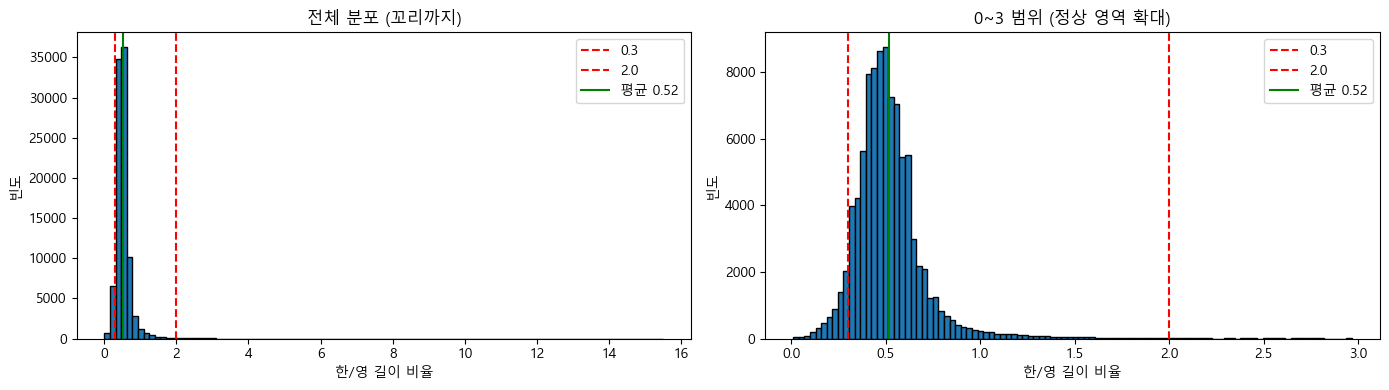

In [3]:
import matplotlib.pyplot as plt

# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 길이 비율 분포
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 왼쪽: 전체 비율 분포
axes[0].hist(ratios, bins=100, edgecolor='black')
axes[0].axvline(0.3, color='red', linestyle='--', label='0.3')
axes[0].axvline(2.0, color='red', linestyle='--', label='2.0')
axes[0].axvline(0.52, color='green', linestyle='-', label='평균 0.52')
axes[0].set_xlabel('한/영 길이 비율')
axes[0].set_ylabel('빈도')
axes[0].set_title('전체 분포 (꼬리까지)')
axes[0].legend()

# 오른쪽: 0~3 범위 확대
axes[1].hist([r for r in ratios if r < 3], bins=100, edgecolor='black')
axes[1].axvline(0.3, color='red', linestyle='--', label='0.3')
axes[1].axvline(2.0, color='red', linestyle='--', label='2.0')
axes[1].axvline(0.52, color='green', linestyle='-', label='평균 0.52')
axes[1].set_xlabel('한/영 길이 비율')
axes[1].set_ylabel('빈도')
axes[1].set_title('0~3 범위 (정상 영역 확대)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [4]:
import statistics
median_ratio = statistics.median(ratios)
print(f"중간값: {median_ratio:.3f}")
print(f"평균: {sum(ratios)/len(ratios):.3f}")

중간값: 0.492
평균: 0.518


In [5]:
total = len(ratios)
in_03_20 = sum(1 for r in ratios if 0.3 <= r <= 2.0)
in_03_15 = sum(1 for r in ratios if 0.3 <= r <= 1.5)
in_03_12 = sum(1 for r in ratios if 0.3 <= r <= 1.2)
in_03_10 = sum(1 for r in ratios if 0.3 <= r <= 1.0)

print(f"전체: {total}")
print(f"0.3~2.0: {in_03_20} ({in_03_20/total*100:.1f}%)")
print(f"0.3~1.5: {in_03_15} ({in_03_15/total*100:.1f}%)")
print(f"0.3~1.2: {in_03_12} ({in_03_12/total*100:.1f}%)")
print(f"0.3~1.0: {in_03_10} ({in_03_10/total*100:.1f}%)")

전체: 94123
0.3~2.0: 88447 (94.0%)
0.3~1.5: 88106 (93.6%)
0.3~1.2: 87403 (92.9%)
0.3~1.0: 86403 (91.8%)


### 정제 함수 + 노이즈 패턴 처리 

1. 영어/ 한국어 정제 함수 작성
2. : 패턴을 탐색 
3. 영어 매칭 검증 > 정렬깨짐 확인 
4. / 패턴 탐색 > 2가지 부류에 대해 발견 
5. 노이즈 처리 규칙을 정함 

### 정제 함수 설계

- 영어/ 한국어를 분리함 이유는 영어 한국어 처리 차이가 많이 났던것 같은 가장 큰건 띄어쓰기? 
- 화이트 리스트를 기본으로 > 제거할 문자종류가 너무 많았음 허용문자가 훨씬더 작았음 
- <start> / <end> 토큰 처리 > 한국어 입력을 통해 영어 출력 한국어는 시작/끝이 필요없다 봤음 

### 주목한점 

- 명백한 노이즈는 거른다. 
- 한쪽 노이즈를 잡아 가능하면 대칭을 맞추도록 했음, 한쪽만 노이즈가 남아있는것 보다는 차라리 양쪽다 노이즈가 남아있는 편이 좋지 않았을까 그렇게 생각했었음 
- 노이즈를 잡으려면 한도끝도 없었고 어느정도는 타협점이 필요하다는 느낌을 받았음 

In [6]:
import re
import unicodedata

def preprocess_eng(sentence, s_token=False, e_token=False):
    """영어 문장 정제"""
    # 1. 유니코드 정규화: 악센트 분리 (é → e + ́)
    sentence = ''.join(c for c in unicodedata.normalize('NFD', sentence)
                       if unicodedata.category(c) != 'Mn')
    
    # 2. 소문자 변환 + 양 끝 공백 제거
    sentence = sentence.lower().strip()
    
    # 3. 구두점 앞뒤로 공백 추가 ("Hello!" → "Hello !")
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    
    # 4. 연속 공백을 하나로 ("  " → " ")
    sentence = re.sub(r'[" "]+', " ", sentence)
    
    # 5. 알파벳, 숫자, 기본 구두점만 남기기 (나머지 제거)
    sentence = re.sub(r"[^a-zA-Z0-9?.!,]+", " ", sentence)
    
    # 6. 양 끝 공백 정리
    sentence = sentence.strip()
    
    # 7. 시작/끝 토큰 추가
    if s_token:
        sentence = '<start> ' + sentence
    if e_token:
        sentence += ' <end>'
    
    return sentence

In [7]:
# 영어 테스트
test_eng = "Hello, World! How are you? It's a beautiful day."
print(preprocess_eng(test_eng))
print(preprocess_eng(test_eng, s_token=True, e_token=True))

hello , world ! how are you ? it s a beautiful day .
<start> hello , world ! how are you ? it s a beautiful day . <end>


In [8]:
def preprocess_kor(sentence, s_token=False, e_token=False):
    """한국어 문장 정제"""
    # 1. 양 끝 공백 제거
    sentence = sentence.strip()
    
    # 2. 구두점 앞뒤로 공백 추가
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    
    # 3. 연속 공백을 하나로
    sentence = re.sub(r'[" "]+', " ", sentence)
    
    # 4. 한글 + 숫자 + 기본 구두점만 남기기 (한자, 영어, 특수문자 제거)
    sentence = re.sub(r"[^가-힣ㄱ-ㅎㅏ-ㅣ0-9?.!,]+", " ", sentence)
    
    # 5. 양 끝 공백 정리
    sentence = sentence.strip()
    
    # 6. 시작/끝 토큰 추가 (영어 함수와 동일)
    if s_token:
        sentence = '<start> ' + sentence
    if e_token:
        sentence += ' <end>'
    
    return sentence

In [9]:
# 한국어 테스트
test_kor1 = "안녕하세요, 반갑습니다! 오늘 날씨는 어떤가요?"
test_kor2 = "베트남 호지민市의 6층 건물에서 화재가 발생했다."
test_kor3 = "오바마(Obama)는 미국의 대통령이었다."

print(preprocess_kor(test_kor1))
print(preprocess_kor(test_kor2))
print(preprocess_kor(test_kor3))
print()
print(preprocess_kor(test_kor1, s_token=True, e_token=True))

안녕하세요 , 반갑습니다 ! 오늘 날씨는 어떤가요 ?
베트남 호지민 의 6층 건물에서 화재가 발생했다 .
오바마 는 미국의 대통령이었다 .

<start> 안녕하세요 , 반갑습니다 ! 오늘 날씨는 어떤가요 ? <end>


In [10]:
colon_pairs = []  # (인덱스, 한국어, 영어) 튜플 저장

for i, (ko, en) in enumerate(zip(ko_lines, en_lines)):
    if ':' in ko or ':' in en:
        colon_pairs.append((i, ko.strip(), en.strip()))

print(f"`:`이 한쪽이라도 포함된 쌍: {len(colon_pairs)}개")

`:`이 한쪽이라도 포함된 쌍: 2621개


In [11]:
# 각 쌍에서 `:` 앞 단어 수 확인

def count_words_before_colon(line):
    """`:` 앞 부분의 단어 수 (`:`이 없으면 None)"""
    if ':' not in line:
        return None
    before = line.split(':')[0]  # `:` 앞 부분만
    return len(before.split())   # 공백 기준 단어 수

# 결과 분석
for i, ko, en in colon_pairs[:30]:  # 처음 30쌍만 보자
    ko_words = count_words_before_colon(ko)
    en_words = count_words_before_colon(en)
    print(f"[{i}] KO 단어수={ko_words}: {ko[:50]}")
    print(f"    EN 단어수={en_words}: {en[:50]}")
    print()

[27] KO 단어수=1: 어휘 :
    EN 단어수=None: The Geneva-based commission, in its annual study o

[30] KO 단어수=1: 어휘 :
    EN 단어수=None: Postal Service - whose postmaster told a Senate pa

[52] KO 단어수=None: 적당한 가격의 돈을 받고, 수십개의 사이트들이 정치 집회, 세례식, 성인식, 장례식, 심지
    EN 단어수=18: For the right price, dozens of sites promise to fi

[131] KO 단어수=None: 전국 민주 노동조합 총연맹의 박강우 정책기획실장에게 있어 그 해결책은 분명하다.
    EN 단어수=17: For Park Kang Woo, policy director of the Korean C

[282] KO 단어수=1: 어휘 :
    EN 단어수=None: the United States will take every measure against 

[283] KO 단어수=37: Army 미국 육군  / shoot down 을 쏘아 떨어뜨리다  / artillery 대
    EN 단어수=None: Army used a high-energy laser to shoot down an art

[318] KO 단어수=1: 어휘 : examine 면밀히 조사하다   plight 상태, 양상   revive 회복시
    EN 단어수=None: In our Focus report, Bob Dody examines the plight 

[352] KO 단어수=15: 美 항공우주국은 수십년 동안 크게 드러내지 않고 그런 논쟁을 다루어왔지만, 2001년에 폭
    EN 단어수=37: The National Aeronautics and Space Administration 

[389] KO 단어수=5: 인공 지능은 이제 막 시작되었다:
    EN 단어수=6: Artifici

In [12]:
# [389] 인덱스의 영어 줄 확인
print(f"KO: {ko_lines[389].strip()}")
print(f"EN: {en_lines[389].strip()}")

KO: 인공 지능은 이제 막 시작되었다:
EN: Artificial intelligence is just getting started :


In [13]:
# `/` 들어 있는 한국어 줄 찾기
slash_lines = []
for i, ko in enumerate(ko_lines):
    if '/' in ko:
        slash_count = ko.count('/')
        slash_lines.append((i, slash_count, ko.strip()))

# `/` 개수로 정렬해서 많은 순으로
slash_lines.sort(key=lambda x: -x[1])

# 상위 30개 보기
print(f"`/` 포함 한국어 줄: {len(slash_lines)}개\n")
for i, count, line in slash_lines[:30]:
    print(f"[{i}] /×{count}: {line[:80]}")

`/` 포함 한국어 줄: 977개

[4521] /×15: throwaway 사용 후 버리는  / cell phone 이동 전화, 휴대폰  / be set to do 할 준비가 되어있다  / make o
[4553] /×11: elaborate 정교한, 복잡한  / matrix 기반, 모체  / scatter 흩어지게 하다  / throughout 도처에, 샅샅이  /
[4598] /×9: researcher 연구원  / create 만들어내다, 창조하다  / transgenic 다른 종(種)에서 전이된 유전자를 갖고 있는  / m
[283] /×7: Army 미국 육군  / shoot down 을 쏘아 떨어뜨리다  / artillery 대포  / shell 포탄  / in mid-flight
[3659] /×7: hand (시계, 계기 등의) 바늘  / Doomsday Clock 운명의 날 시계  / symbolic 상징적인  / gauge 계기  / t
[4404] /×7: 어휘 : concern 우려, 걱정  / unprecedented 전례 없는  / control 지배, 관리  / access line 접속 라
[7734] /×6: (CNN)/ (JOINS) ##http://article.joins.com/article/cnn_e/article.asp?cat_code=22&
[7798] /×6: (CNN)/ (JOINS) ##http://article.joins.com/article/cnn_e/article.asp?cat_code=22&
[7992] /×6: (CNN)/ (JOINS) ##http://article.joins.com/article/cnn_e/article.asp?cat_code=22&
[8148] /×6: (CNN)/ (JOINS) ##http://article.joins.com/article/cnn_e/article.asp?cat_code=22&
[8323] /×6: (CNN)/ (JOINS) ##http://article.joins

In [14]:
# `/` 5개 이상 + URL 패턴 줄들의 영어 짝 확인
for i, count, line in slash_lines[:30]:
    if 'http' in line or '##' in line:
        print(f"[{i}] /×{count}")
        print(f"  KO: {line[:80]}")
        print(f"  EN: {en_lines[i].strip()[:80]}")
        print()

[7734] /×6
  KO: (CNN)/ (JOINS) ##http://article.joins.com/article/cnn_e/article.asp?cat_code=22&
  EN: ##http://article.joins.com/article/cnn_e/article.asp?cat_code=22&Total_ID=317135

[7798] /×6
  KO: (CNN)/ (JOINS) ##http://article.joins.com/article/cnn_e/article.asp?cat_code=22&
  EN: ##http://article.joins.com/article/cnn_e/article.asp?cat_code=22&Total_ID=317051

[7992] /×6
  KO: (CNN)/ (JOINS) ##http://article.joins.com/article/cnn_e/article.asp?cat_code=22&
  EN: ##http://article.joins.com/article/cnn_e/article.asp?cat_code=22&Total_ID=316900

[8148] /×6
  KO: (CNN)/ (JOINS) ##http://article.joins.com/article/cnn_e/article.asp?cat_code=22&
  EN: ##http://article.joins.com/article/cnn_e/article.asp?cat_code=22&Total_ID=316558

[8323] /×6
  KO: (CNN)/ (JOINS) ##http://article.joins.com/article/cnn_e/article.asp?cat_code=22&
  EN: ##http://article.joins.com/article/cnn_e/article.asp?cat_code=22&Total_ID=316486

[8327] /×6
  KO: (CNN)/ (JOINS) ##http://article.joins.com/article/cnn

In [15]:
# ============================================
# 1단계: 데이터 전처리 파이프라인
# ============================================

# 정제 함수 정의 (이미 했지만 재확인용)
import re
import unicodedata

def preprocess_eng(sentence, s_token=False, e_token=False):
    sentence = ''.join(c for c in unicodedata.normalize('NFD', sentence)
                       if unicodedata.category(c) != 'Mn')
    sentence = sentence.lower().strip()
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    sentence = re.sub(r"[^a-zA-Z0-9?.!,]+", " ", sentence)
    sentence = sentence.strip()
    if s_token: sentence = '<start> ' + sentence
    if e_token: sentence += ' <end>'
    return sentence

def preprocess_kor(sentence, s_token=False, e_token=False):
    sentence = sentence.strip()
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    sentence = re.sub(r"[^가-힣ㄱ-ㅎㅏ-ㅣ0-9?.!,]+", " ", sentence)
    sentence = sentence.strip()
    if s_token: sentence = '<start> ' + sentence
    if e_token: sentence += ' <end>'
    return sentence


# ============================================
# 노이즈 판별 함수
# ============================================

def is_meta_noise(ko_line):
    """한국어 줄이 메타 노이즈인지 판단"""
    ko = ko_line.strip()
    
    # 패턴 1: URL 마커
    if 'http' in ko or '##' in ko:
        return True
    
    # 패턴 2: 1단어 + : (콜론으로 끝나면서 단어 1개 이하)
    if ko.endswith(':') and len(ko.rstrip(':').split()) <= 1:
        return True
    
    # 패턴 3: 단어 사전형 ('/' 3개 이상)
    if ko.count('/') >= 3:
        return True
    
    return False


# ============================================
# 정제 파이프라인 실행
# ============================================

print(f"원본: {len(ko_lines)}쌍")

# 단계 1: 비율 필터 (0.3 ~ 1.5)
step1_pairs = []
for ko, en in zip(ko_lines, en_lines):
    ko_len = len(ko.strip())
    en_len = len(en.strip())
    if en_len == 0:
        continue
    ratio = ko_len / en_len
    if 0.3 <= ratio <= 1.5:
        step1_pairs.append((ko.strip(), en.strip()))

print(f"1. 비율 필터 후: {len(step1_pairs)}쌍 (-{len(ko_lines) - len(step1_pairs)})")

# 단계 2: 메타 노이즈 제거
step2_pairs = [(ko, en) for ko, en in step1_pairs if not is_meta_noise(ko)]
print(f"2. 노이즈 제거 후: {len(step2_pairs)}쌍 (-{len(step1_pairs) - len(step2_pairs)})")

# 단계 3: 정제 함수 적용 (영어는 <start>/<end> 추가)
step3_pairs = []
for ko, en in step2_pairs:
    ko_clean = preprocess_kor(ko)
    en_clean = preprocess_eng(en, s_token=True, e_token=True)
    # 정제 후 빈 문자열 된 케이스 제거
    if ko_clean and en_clean:
        # <start> <end> 빼고도 영어가 비었는지 확인
        en_core = en_clean.replace('<start>', '').replace('<end>', '').strip()
        if en_core and ko_clean:
            step3_pairs.append((ko_clean, en_clean))

print(f"3. 정제 적용 후: {len(step3_pairs)}쌍 (-{len(step2_pairs) - len(step3_pairs)})")

# 단계 4: 중복 제거 (정제 후 통일된 상태에서)
step4_pairs = list(set(step3_pairs))
print(f"4. 중복 제거 후: {len(step4_pairs)}쌍 (-{len(step3_pairs) - len(step4_pairs)})")

# 최종 결과
cleaned_corpus = step4_pairs
print(f"\n최종: {len(cleaned_corpus)}쌍")

# 샘플 확인
print("\n=== 정제된 샘플 5개 ===")
for i, (ko, en) in enumerate(cleaned_corpus[:5]):
    print(f"[{i}] KO: {ko[:80]}")
    print(f"    EN: {en[:80]}")
    print()

원본: 94123쌍
1. 비율 필터 후: 88106쌍 (-6017)
2. 노이즈 제거 후: 87951쌍 (-155)
3. 정제 적용 후: 87946쌍 (-5)
4. 중복 제거 후: 73054쌍 (-14892)

최종: 73054쌍

=== 정제된 샘플 5개 ===
[0] KO: 범블비로서 당신은 디셉션과 전투를 벌이기도 하고 도시에서 레이스를 펼치거나 올스파크를 찾는데 중요한 역할을 하는 십대 아이 샘 를 지키는 미션을
    EN: <start> as bumblebee , you must fight decepticons , transform into a car , race 

[1] KO: 여행 중 우리는 고고학자들이 발굴한 , 일부 석화된 인체 주형을 봤다 .
    EN: <start> during our tour , we saw plaster casts of some of the bodies archeologis

[2] KO: 그들은 과도한 납성분의 페인트가 함유된 것을 포함 , 아이들이 삼킬수 있는 작은 자석이 함유된 중국 산 장난감을 리콜 처리했다 .
    EN: <start> they included chinese made toys that either had excessive amounts of lea

[3] KO: 조사에 참여한 10 17 세의 인터넷 사용자 중 42 는 지난 1 년간의 기간 중 온라인 포르노를 본 적이 있다고 밝혔다 .
    EN: <start> forty two percent of internet users aged 10 to 17 surveyed said they had

[4] KO: 백악관 관계자에따르면 최근 식량가격이 43 이상 급등한 이집트 , 아이티 , 예멘 , 방글라데시 등 제3세계 국가에서는 유혈폭력시위까지 발생했다
    EN: <start> riots have broken out in egypt , haiti , yemen , bangladesh and other na



### 토큰화 

1. 한국어 : mecab으로 형태소 단위로 분해함. 
2. 영어 : split()로 공백을 가눔
3. 길이 40필터: 루브릭 기준이었기 때문이었음. 

형태소 분석기 = mecab vs Okt 비교해봄 
mecab이 좀 더 잘게 분해했음 예를 들면 이었다를 mecab은 이,었,다 라는 3개로 분류를 함
영어 split()이건 루브릭 요구사항이었음 이하 길이 40필터도 똑같은 조건이었음. 

### 한국어 토큰량이 더 많음 
- 한국어가 평균적으로 3토큰 가량 많았음. 
- 한국어가 형태소 단위로 잘게 쪼갠 이유도 있지만 실제로 LLM서비스에서의 가격표 측정에서도 한국어가 영어보다 비싸게 측정됨 

### 결과 

73, 054 > 57, 272 


In [16]:
print(f"    EN: {en[:80]}")

    EN: <start> riots have broken out in egypt , haiti , yemen , bangladesh and other na


In [17]:
try:
    from konlpy.tag import Mecab
    mecab = Mecab()
    print(mecab.morphs("안녕하세요 반갑습니다"))
except Exception as e:
    print(f"오류: {e}")

오류: Install MeCab in order to use it: http://konlpy.org/en/latest/install/


In [18]:
pip install konlpy


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
pip install python-mecab-ko


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
# 1, 2단계 후 시도
try:
    from konlpy.tag import Mecab
    mecab = Mecab()
    print("mecab OK:", mecab.morphs("안녕하세요 반갑습니다"))
except Exception as e:
    print(f"mecab 실패: {e}")
    from konlpy.tag import Okt
    okt = Okt()
    print("Okt 사용:", okt.morphs("안녕하세요 반갑습니다"))

mecab 실패: Install MeCab in order to use it: http://konlpy.org/en/latest/install/
Okt 사용: ['안녕하세요', '반갑습니다']


In [21]:
import mecab

tagger = mecab.MeCab()
print(tagger.morphs("안녕하세요 반갑습니다"))

['안녕', '하', '세요', '반갑', '습니다']


In [22]:
test = "오바마는 미국의 대통령이었다."

# python-mecab-ko 시도
try:
    import mecab
    tagger = mecab.MeCab()
    print("mecab:", tagger.morphs(test))
except Exception as e:
    print(f"mecab 실패: {e}")

# Okt 비교
from konlpy.tag import Okt
okt = Okt()
print("Okt:", okt.morphs(test))

mecab: ['오바마', '는', '미국', '의', '대통령', '이', '었', '다', '.']
Okt: ['오바마', '는', '미국', '의', '대통령', '이었다', '.']


In [23]:
import mecab
tagger = mecab.MeCab()

ko_token_lens = []
en_token_lens = []

for ko, en in cleaned_corpus:
    ko_tokens = tagger.morphs(ko)
    en_tokens = en.split()
    ko_token_lens.append(len(ko_tokens))
    en_token_lens.append(len(en_tokens))

import statistics
print(f"한국어 토큰 — 평균: {statistics.mean(ko_token_lens):.1f}, 중간값: {statistics.median(ko_token_lens):.0f}")
print(f"영어 토큰 — 평균: {statistics.mean(en_token_lens):.1f}, 중간값: {statistics.median(en_token_lens):.0f}")
print(f"\n한국어 40 초과: {sum(1 for n in ko_token_lens if n > 40)}쌍")
print(f"영어 40 초과: {sum(1 for n in en_token_lens if n > 40)}쌍")
print(f"둘 다 40 이하: {sum(1 for k, e in zip(ko_token_lens, en_token_lens) if k <= 40 and e <= 40)}쌍")

한국어 토큰 — 평균: 29.8, 중간값: 29
영어 토큰 — 평균: 26.9, 중간값: 26

한국어 40 초과: 13244쌍
영어 40 초과: 8024쌍
둘 다 40 이하: 57272쌍


In [24]:
# 토큰화 + 길이 필터
tokenized_corpus = []
for ko, en in cleaned_corpus:
    ko_tokens = tagger.morphs(ko)
    en_tokens = en.split()
    if len(ko_tokens) <= 40 and len(en_tokens) <= 40:
        tokenized_corpus.append((ko_tokens, en_tokens))

print(f"토큰화 완료: {len(tokenized_corpus)}쌍")
print(f"\n샘플 3개:")
for i, (ko, en) in enumerate(tokenized_corpus[:3]):
    print(f"[{i}] KO ({len(ko)}): {ko}")
    print(f"    EN ({len(en)}): {en}")
    print()

토큰화 완료: 57272쌍

샘플 3개:
[0] KO (19): ['여행', '중', '우리', '는', '고고학자', '들', '이', '발굴', '한', ',', '일부', '석화', '된', '인체', '주형', '을', '봤', '다', '.']
    EN (18): ['<start>', 'during', 'our', 'tour', ',', 'we', 'saw', 'plaster', 'casts', 'of', 'some', 'of', 'the', 'bodies', 'archeologists', 'found', '.', '<end>']

[1] KO (38): ['그', '들', '은', '과도', '한', '납', '성분', '의', '페인트', '가', '함유', '된', '것', '을', '포함', ',', '아이', '들', '이', '삼킬', '수', '있', '는', '작', '은', '자석', '이', '함유', '된', '중국', '산', '장난감', '을', '리콜', '처리', '했', '다', '.']
    EN (27): ['<start>', 'they', 'included', 'chinese', 'made', 'toys', 'that', 'either', 'had', 'excessive', 'amounts', 'of', 'lead', 'paint', 'or', 'had', 'small', 'magnets', 'that', 'could', 'easily', 'be', 'swallowed', 'by', 'children', '.', '<end>']

[2] KO (31): ['조사', '에', '참여', '한', '10', '17', '세', '의', '인터넷', '사용자', '중', '42', '는', '지난', '1', '년', '간', '의', '기간', '중', '온라인', '포르노', '를', '본', '적', '이', '있', '다고', '밝혔', '다', '.']
    EN (26): ['<start>', 'forty

In [25]:
# 토큰화 + 길이 40 필터
tokenized_corpus = []
for ko, en in cleaned_corpus:
    ko_tokens = tagger.morphs(ko)
    en_tokens = en.split()
    if len(ko_tokens) <= 40 and len(en_tokens) <= 40:
        tokenized_corpus.append((ko_tokens, en_tokens))

print(f"토큰화 완료: {len(tokenized_corpus)}쌍")

# 샘플 3개 확인
print(f"\n샘플 3개:")
for i, (ko, en) in enumerate(tokenized_corpus[:3]):
    print(f"[{i}] KO ({len(ko)}토큰): {ko}")
    print(f"    EN ({len(en)}토큰): {en}")
    print()

토큰화 완료: 57272쌍

샘플 3개:
[0] KO (19토큰): ['여행', '중', '우리', '는', '고고학자', '들', '이', '발굴', '한', ',', '일부', '석화', '된', '인체', '주형', '을', '봤', '다', '.']
    EN (18토큰): ['<start>', 'during', 'our', 'tour', ',', 'we', 'saw', 'plaster', 'casts', 'of', 'some', 'of', 'the', 'bodies', 'archeologists', 'found', '.', '<end>']

[1] KO (38토큰): ['그', '들', '은', '과도', '한', '납', '성분', '의', '페인트', '가', '함유', '된', '것', '을', '포함', ',', '아이', '들', '이', '삼킬', '수', '있', '는', '작', '은', '자석', '이', '함유', '된', '중국', '산', '장난감', '을', '리콜', '처리', '했', '다', '.']
    EN (27토큰): ['<start>', 'they', 'included', 'chinese', 'made', 'toys', 'that', 'either', 'had', 'excessive', 'amounts', 'of', 'lead', 'paint', 'or', 'had', 'small', 'magnets', 'that', 'could', 'easily', 'be', 'swallowed', 'by', 'children', '.', '<end>']

[2] KO (31토큰): ['조사', '에', '참여', '한', '10', '17', '세', '의', '인터넷', '사용자', '중', '42', '는', '지난', '1', '년', '간', '의', '기간', '중', '온라인', '포르노', '를', '본', '적', '이', '있', '다고', '밝혔', '다', '.']
    EN (26토큰): ['<sta

In [26]:
# `<start>`와 `<end>`가 항상 한 토큰으로 있는지 확인
issues = []
for i, (ko, en) in enumerate(tokenized_corpus):
    if en[0] != '<start>':
        issues.append((i, 'start_missing', en[:3]))
    if en[-1] != '<end>':
        issues.append((i, 'end_missing', en[-3:]))

print(f"전체: {len(tokenized_corpus)}쌍")
print(f"문제 있는 쌍: {len(issues)}쌍")
if issues:
    print("\n문제 샘플 5개:")
    for issue in issues[:5]:
        print(issue)

전체: 57272쌍
문제 있는 쌍: 0쌍


### VOCAB 빌드 

1. 한국어/ 영어 토큰 빈도별 카운트를 통해 특수태그인 <unk>를 얼마나 넣을지 비율을 분석했음 
2. 모든 토큰에 ID를 할당할 수는 없었기 때문에 내린 결정이었음, vocab 크기별 한국어와 영어에서 <unk>가 몇퍼센트 비율로 등장하는지 확인한 뒤 2퍼센트 근처가 제일 안전하지 않을까? 라는 생각을 했음 
3. 처음 영어 vocab크기가 17998이 나왔는데 의도와 2가 차이가 났었음 이는 정제 단계에서 추가했던 <start>/<end>가 빈도 카운트에 포함 되었었는데 특수 토큰을 빈도 카운트에서 제외했었음 

In [27]:
from collections import Counter

ko_token_counter = Counter()
en_token_counter = Counter()

for ko, en in tokenized_corpus:
    ko_token_counter.update(ko)
    en_token_counter.update(en)

print(f"한국어 고유 토큰: {len(ko_token_counter)}개")
print(f"영어 고유 토큰: {len(en_token_counter)}개")

# 빈도 분포
print(f"\n한국어 빈도 상위 10:")
for token, count in ko_token_counter.most_common(10):
    print(f"  {token}: {count}")

print(f"\n영어 빈도 상위 10:")
for token, count in en_token_counter.most_common(10):
    print(f"  {token}: {count}")

# 빈도 1번만 나오는 토큰 수
ko_rare = sum(1 for c in ko_token_counter.values() if c == 1)
en_rare = sum(1 for c in en_token_counter.values() if c == 1)
print(f"\n한국어 빈도 1번뿐: {ko_rare}개 ({ko_rare/len(ko_token_counter)*100:.1f}%)")
print(f"영어 빈도 1번뿐: {en_rare}개 ({en_rare/len(en_token_counter)*100:.1f}%)")

한국어 고유 토큰: 37186개
영어 고유 토큰: 38444개

한국어 빈도 상위 10:
  .: 57719
  다: 49323
  이: 44791
  는: 41413
  을: 37148
  의: 33038
  은: 31204
  에: 30130
  했: 21433
  를: 21221

영어 빈도 상위 10:
  the: 71674
  .: 63345
  <start>: 57272
  <end>: 57272
  ,: 52520
  to: 28189
  of: 27279
  a: 26827
  in: 25406
  and: 22634

한국어 빈도 1번뿐: 13541개 (36.4%)
영어 빈도 1번뿐: 14325개 (37.3%)


In [28]:
# vocab 크기별로 무엇이 살아남는지 분석
for vocab_size in [10000, 12000, 15000, 18000, 20000]:
    target = vocab_size - 4  # 특수 토큰 4개 빼고
    
    # 한국어 기준
    if target >= len(ko_token_counter):
        print(f"vocab {vocab_size}: 모든 토큰 살림")
        continue
    
    # 잘리는 토큰들의 빈도 분포
    sorted_tokens = ko_token_counter.most_common()
    cutoff_freq = sorted_tokens[target - 1][1]  # 살아남는 마지막 토큰의 빈도
    
    # 잘리는 단어들의 총 등장 횟수 = <unk>로 처리될 등장 횟수
    cut_count = sum(c for t, c in sorted_tokens[target:])
    total_count = sum(ko_token_counter.values())
    unk_ratio = cut_count / total_count * 100
    
    print(f"vocab {vocab_size}: 최하위 살리는 빈도={cutoff_freq}, <unk>로 처리될 토큰 등장 비율={unk_ratio:.2f}%")

vocab 10000: 최하위 살리는 빈도=7, <unk>로 처리될 토큰 등장 비율=4.12%
vocab 12000: 최하위 살리는 빈도=5, <unk>로 처리될 토큰 등장 비율=3.27%
vocab 15000: 최하위 살리는 빈도=4, <unk>로 처리될 토큰 등장 비율=2.36%
vocab 18000: 최하위 살리는 빈도=3, <unk>로 처리될 토큰 등장 비율=1.73%
vocab 20000: 최하위 살리는 빈도=2, <unk>로 처리될 토큰 등장 비율=1.44%


In [29]:
print("=== 한국어 ===")
for vocab_size in [10000, 12000, 15000, 18000, 20000]:
    target = vocab_size - 4
    if target >= len(ko_token_counter):
        continue
    sorted_tokens = ko_token_counter.most_common()
    cutoff_freq = sorted_tokens[target - 1][1]
    cut_count = sum(c for t, c in sorted_tokens[target:])
    total_count = sum(ko_token_counter.values())
    unk_ratio = cut_count / total_count * 100
    print(f"vocab {vocab_size}: <unk> {unk_ratio:.2f}%")

print("\n=== 영어 ===")
for vocab_size in [10000, 12000, 15000, 18000, 20000]:
    target = vocab_size - 4
    if target >= len(en_token_counter):
        continue
    sorted_tokens = en_token_counter.most_common()
    cutoff_freq = sorted_tokens[target - 1][1]
    cut_count = sum(c for t, c in sorted_tokens[target:])
    total_count = sum(en_token_counter.values())
    unk_ratio = cut_count / total_count * 100
    print(f"vocab {vocab_size}: <unk> {unk_ratio:.2f}%")

=== 한국어 ===
vocab 10000: <unk> 4.12%
vocab 12000: <unk> 3.27%
vocab 15000: <unk> 2.36%
vocab 18000: <unk> 1.73%
vocab 20000: <unk> 1.44%

=== 영어 ===
vocab 10000: <unk> 4.60%
vocab 12000: <unk> 3.69%
vocab 15000: <unk> 2.71%
vocab 18000: <unk> 2.02%
vocab 20000: <unk> 1.69%


In [30]:
# 특수 토큰 (가장 먼저, 고정 ID)
SPECIAL_TOKENS = ['<pad>', '<unk>', '<start>', '<end>']

def build_vocab(token_counter, vocab_size):
    """Counter에서 vocab dict 생성"""
    # 빈도 높은 순으로 상위 (vocab_size - 4)개만 (특수 토큰 자리 빼고)
    most_common = token_counter.most_common(vocab_size - len(SPECIAL_TOKENS))
    
    # 특수 토큰 + 일반 토큰 (특수 토큰이 먼저 → ID 0~3)
    vocab_list = SPECIAL_TOKENS + [token for token, count in most_common]
    
    # token → id, id → token 두 방향 dict
    token2id = {token: idx for idx, token in enumerate(vocab_list)}
    id2token = {idx: token for idx, token in enumerate(vocab_list)}
    
    return token2id, id2token


# vocab 빌드
VOCAB_SIZE = 18000

ko_token2id, ko_id2token = build_vocab(ko_token_counter, VOCAB_SIZE)
en_token2id, en_id2token = build_vocab(en_token_counter, VOCAB_SIZE)

print(f"한국어 vocab: {len(ko_token2id)}개")
print(f"영어 vocab: {len(en_token2id)}개")

# 특수 토큰 ID 확인
print(f"\n특수 토큰 ID:")
for token in SPECIAL_TOKENS:
    print(f"  {token}: KO={ko_token2id[token]}, EN={en_token2id[token]}")

# 한국어 빈도 상위 5개의 ID 확인
print(f"\n한국어 빈도 상위 5개 ID:")
for token, count in ko_token_counter.most_common(5):
    print(f"  {token}: {ko_token2id[token]} (빈도 {count})")

한국어 vocab: 18000개
영어 vocab: 17998개

특수 토큰 ID:
  <pad>: KO=0, EN=0
  <unk>: KO=1, EN=1
  <start>: KO=2, EN=6
  <end>: KO=3, EN=7

한국어 빈도 상위 5개 ID:
  .: 4 (빈도 57719)
  다: 5 (빈도 49323)
  이: 6 (빈도 44791)
  는: 7 (빈도 41413)
  을: 8 (빈도 37148)


In [31]:
def tokens_to_ids(tokens, token2id):
    """토큰 리스트를 ID 리스트로 변환. 미등록어는 <unk>로."""
    unk_id = token2id['<unk>']
    return [token2id.get(token, unk_id) for token in tokens]

In [32]:
def build_vocab(token_counter, vocab_size):
    """Counter에서 vocab dict 생성 (특수 토큰 중복 방지)"""
    # 특수 토큰 제외하고 빈도 카운트
    filtered_counter = {t: c for t, c in token_counter.items() 
                        if t not in SPECIAL_TOKENS}
    
    # 빈도 높은 순으로 상위 (vocab_size - 4)개
    most_common = sorted(filtered_counter.items(), key=lambda x: -x[1])[:vocab_size - len(SPECIAL_TOKENS)]
    
    # 특수 토큰 + 일반 토큰
    vocab_list = SPECIAL_TOKENS + [token for token, count in most_common]
    
    token2id = {token: idx for idx, token in enumerate(vocab_list)}
    id2token = {idx: token for idx, token in enumerate(vocab_list)}
    
    return token2id, id2token


# 다시 vocab 빌드
ko_token2id, ko_id2token = build_vocab(ko_token_counter, VOCAB_SIZE)
en_token2id, en_id2token = build_vocab(en_token_counter, VOCAB_SIZE)

print(f"한국어 vocab: {len(ko_token2id)}개")
print(f"영어 vocab: {len(en_token2id)}개")

print(f"\n특수 토큰 ID:")
for token in SPECIAL_TOKENS:
    print(f"  {token}: KO={ko_token2id[token]}, EN={en_token2id[token]}")

한국어 vocab: 18000개
영어 vocab: 18000개

특수 토큰 ID:
  <pad>: KO=0, EN=0
  <unk>: KO=1, EN=1
  <start>: KO=2, EN=2
  <end>: KO=3, EN=3


### B4. ID 변환

dict.get() 패턴으로 토큰 → ID 변환. 미등록어는 자동으로 <unk> ID(1) 처리.
실측 <unk> 비율 (한국어 1.73%, 영어 2.02%)이 예측치와 일치 — vocab 빌드 정상.

In [33]:
def tokens_to_ids(tokens, token2id):
    """토큰 리스트 → ID 리스트. 미등록어는 <unk> ID로."""
    unk_id = token2id['<unk>']
    return [token2id.get(token, unk_id) for token in tokens]


# 모든 데이터 ID로 변환
id_corpus = []
for ko_tokens, en_tokens in tokenized_corpus:
    ko_ids = tokens_to_ids(ko_tokens, ko_token2id)
    en_ids = tokens_to_ids(en_tokens, en_token2id)
    id_corpus.append((ko_ids, en_ids))

print(f"ID 변환 완료: {len(id_corpus)}쌍")

# 샘플 확인
print(f"\n샘플 1개 (한국어):")
ko_tokens, en_tokens = tokenized_corpus[0]
ko_ids, en_ids = id_corpus[0]
print(f"  토큰: {ko_tokens[:10]}")
print(f"  ID:   {ko_ids[:10]}")

print(f"\n샘플 1개 (영어):")
print(f"  토큰: {en_tokens[:10]}")
print(f"  ID:   {en_ids[:10]}")

# <unk> 비율 실측
ko_total_tokens = sum(len(ko) for ko, en in id_corpus)
en_total_tokens = sum(len(en) for ko, en in id_corpus)
ko_unk_count = sum(sum(1 for tid in ko if tid == 1) for ko, en in id_corpus)
en_unk_count = sum(sum(1 for tid in en if tid == 1) for ko, en in id_corpus)

print(f"\n실제 <unk> 비율:")
print(f"  한국어: {ko_unk_count}/{ko_total_tokens} = {ko_unk_count/ko_total_tokens*100:.2f}%")
print(f"  영어:   {en_unk_count}/{en_total_tokens} = {en_unk_count/en_total_tokens*100:.2f}%")

ID 변환 완료: 57272쌍

샘플 1개 (한국어):
  토큰: ['여행', '중', '우리', '는', '고고학자', '들', '이', '발굴', '한', ',']
  ID:   [615, 62, 128, 7, 4245, 18, 6, 2702, 20, 21]

샘플 1개 (영어):
  토큰: ['<start>', 'during', 'our', 'tour', ',', 'we', 'saw', 'plaster', 'casts', 'of']
  ID:   [2, 129, 194, 765, 6, 58, 829, 1, 13124, 8]

실제 <unk> 비율:
  한국어: 25004/1448270 = 1.73%
  영어:   26928/1334228 = 2.02%


In [34]:
# 실제 최대 길이 확인
ko_max_len = max(len(ko) for ko, en in id_corpus)
en_max_len = max(len(en) for ko, en in id_corpus)

print(f"한국어 실제 최대 길이: {ko_max_len}")
print(f"영어 실제 최대 길이: {en_max_len}")

한국어 실제 최대 길이: 40
영어 실제 최대 길이: 40


In [35]:
# 패딩 함수 (이전에 본 거)
def pad_sequence(seq, max_len, pad_id=0):
    """시퀀스를 max_len 길이로 패딩 (post-padding)"""
    return seq + [pad_id] * (max_len - len(seq))


# 모든 데이터에 패딩 적용
MAX_LEN = 40
padded_corpus = []

for ko_ids, en_ids in id_corpus:
    ko_padded = pad_sequence(ko_ids, MAX_LEN)
    en_padded = pad_sequence(en_ids, MAX_LEN)
    padded_corpus.append((ko_padded, en_padded))

print(f"패딩 완료: {len(padded_corpus)}쌍")

# 검증: 모든 시퀀스가 길이 40인지 확인
ko_lengths = set(len(ko) for ko, en in padded_corpus)
en_lengths = set(len(en) for ko, en in padded_corpus)
print(f"한국어 길이 종류: {ko_lengths}")  # {40} 하나만 나와야 함
print(f"영어 길이 종류: {en_lengths}")    # {40} 하나만 나와야 함

# 샘플 확인
ko_sample, en_sample = padded_corpus[0]
print(f"\n샘플 (한국어):")
print(f"  앞 10개: {ko_sample[:10]}")
print(f"  뒤 10개: {ko_sample[-10:]}  ← 패딩 0 들어감")

print(f"\n샘플 (영어):")
print(f"  앞 10개: {en_sample[:10]}")
print(f"  뒤 10개: {en_sample[-10:]}  ← 패딩 0 들어감")

패딩 완료: 57272쌍
한국어 길이 종류: {40}
영어 길이 종류: {40}

샘플 (한국어):
  앞 10개: [615, 62, 128, 7, 4245, 18, 6, 2702, 20, 21]
  뒤 10개: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]  ← 패딩 0 들어감

샘플 (영어):
  앞 10개: [2, 129, 194, 765, 6, 58, 829, 1, 13124, 8]
  뒤 10개: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]  ← 패딩 0 들어감


In [36]:
import numpy as np

# 한국어/영어 분리해서 numpy 배열로
ko_array = np.array([ko for ko, en in padded_corpus], dtype=np.int32)
en_array = np.array([en for ko, en in padded_corpus], dtype=np.int32)

print(f"한국어 array shape: {ko_array.shape}")
print(f"영어 array shape: {en_array.shape}")
print(f"dtype: {ko_array.dtype}")

한국어 array shape: (57272, 40)
영어 array shape: (57272, 40)
dtype: int32


In [37]:
pip install torch --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [38]:
import torch
print(torch.__version__)
print(f"CUDA 사용 가능: {torch.cuda.is_available()}")

2.5.1+cu121
CUDA 사용 가능: True


### 모델 작성 
기본 모델 구조는 인코더 + (어텐션+디코더) 구조이며 RNN에 어텐션 구조가 결합된 초창기 어텐션 모델의 형태를 가지고 있음. 순차계산이 특징이고 초창기 어텐션 모델을 구현했다는 점에서 의의가 있다고 생각했음. 
모델 설계는 기존 실험이나 데이터 탐색을 통해 파라미터 값을 정함. 보캡사이즈는 이전에 탐색을 통해서 정해졌었고 임베딩과 히든 스테이트는 가장 무난한 베이스 라인을 잡았음. 

인코더에서는 한국어 IDㄹ를 임베딩 백터로 변환하고 이걸 순차처리를 통해 히든 스티에트에 누적함> 
또한 파이토치 기본 기능으로 forward를 정의해두면 학습시에 자동으로 역전파를 통한 기울기 계산까지 해주는게 특징이었음. 
임시 테스트를 위해 가짜 입력을 넣었는데 이건 실제 학습 전에 기본적인 시운전을 통해 정상작동하는지 확인하는 단계였음

In [39]:
import torch
import torch.nn as nn

class Encoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()
        # 두 개의 layer 정의
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.gru = nn.GRU(embedding_dim, hidden_dim, batch_first=True)
        
    def forward(self, x):
        # x: (batch, seq_len) 정수 텐서
        embedded = self.embedding(x)
        # embedded: (batch, seq_len, embedding_dim)
        
        outputs, hidden = self.gru(embedded)
        # outputs: (batch, seq_len, hidden_dim) — 모든 시점
        # hidden: (1, batch, hidden_dim) — 마지막 시점
        
        return outputs, hidden

In [40]:
# 임시 테스트
encoder = Encoder(vocab_size=18000, embedding_dim=256, hidden_dim=512)

# 가짜 입력 (batch 32, seq 40)
fake_input = torch.randint(0, 18000, (32, 40))
outputs, hidden = encoder(fake_input)

print(f"입력 shape: {fake_input.shape}")
print(f"outputs shape: {outputs.shape}")  # (32, 40, 512) 기대
print(f"hidden shape: {hidden.shape}")     # (1, 32, 512) 기대

입력 shape: torch.Size([32, 40])
outputs shape: torch.Size([32, 40, 512])
hidden shape: torch.Size([1, 32, 512])


### Bahdanau Attention 메커니즘 

- 신경망 스코어 라는 부분이 특이함 이유는 기존 트랜스포머에서는 어텐션 구조가 QK라는 값의 내적을 통한 V의 가중합으로 알고 있었기 때문임 그래서 이런 어텐션 구조는 상당히 특이했음 
- W_a, W_b 라는 인코더/ 디코더 히든 스테이트 값을 통해 더하고, 탄젠트 함수를 통해 안정화 시키면서 비선형성을 추가해줌, 또한 V는 따로 계산을 통해 점수화까지 하는 방법이 내가 아는 방식과는 많이 달랐음 
- seq2seq의 한계는 히든 스테이트에 모든 과거 정보를 압축해야 한다는 문제가 있었다는 점, 순차처리를 해야한다는 문제가 있었던 것 같음 이걸 위해 어텐션이 생긴 게 아닐까 
- 어텐션은 병목현상을 해결하고 순차처리는 트랜스포머가 해결함. 


In [41]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        # 세 개의 Linear layer
        self.W_a = nn.Linear(hidden_dim, hidden_dim)  # encoder hidden 변환
        self.W_b = nn.Linear(hidden_dim, hidden_dim)  # decoder hidden 변환
        self.v = nn.Linear(hidden_dim, 1)              # 최종 score
        
    def forward(self, decoder_hidden, encoder_outputs):
        # decoder_hidden: (batch, hidden_dim)
        # encoder_outputs: (batch, seq_len, hidden_dim)
        
        # 1. decoder_hidden을 시퀀스 차원에 broadcast
        decoder_hidden = decoder_hidden.unsqueeze(1)
        # (batch, 1, hidden_dim)
        
        # 2. score 계산: tanh(W_a · h + W_b · s)
        score = self.v(torch.tanh(self.W_a(encoder_outputs) + self.W_b(decoder_hidden)))
        # score shape: (batch, seq_len, 1)
        
        # 3. softmax로 attention weights
        attention_weights = torch.softmax(score, dim=1)
        # (batch, seq_len, 1)
        
        # 4. context vector = weights × encoder_outputs (가중합)
        context = torch.sum(attention_weights * encoder_outputs, dim=1)
        # (batch, hidden_dim)
        
        return context, attention_weights

In [42]:
# 가짜 입력으로 테스트
attention = BahdanauAttention(hidden_dim=512)

# Encoder 출력 시뮬레이션
fake_encoder_outputs = torch.randn(32, 40, 512)  # (batch, seq_len, hidden)
fake_decoder_hidden = torch.randn(32, 512)        # (batch, hidden)

context, weights = attention(fake_decoder_hidden, fake_encoder_outputs)

print(f"context shape: {context.shape}")        # (32, 512) 기대
print(f"weights shape: {weights.shape}")        # (32, 40, 1) 기대

# 검증: weights 합이 1인지
print(f"weights 합 (시퀀스 차원): {weights.sum(dim=1)[0]}")  # 1에 가까워야 함

context shape: torch.Size([32, 512])
weights shape: torch.Size([32, 40, 1])
weights 합 (시퀀스 차원): tensor([1.0000], grad_fn=<SelectBackward0>)


In [43]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.attention = BahdanauAttention(hidden_dim)
        self.gru = nn.GRU(embedding_dim + hidden_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)
        
    def forward(self, x, hidden, encoder_outputs):
        # x: (batch, 1) - 한 시점의 단어 ID
        # hidden: (1, batch, hidden_dim) - 이전 hidden state
        # encoder_outputs: (batch, seq_len, hidden_dim)
        
        # 1. Embedding
        embedded = self.embedding(x)
        # embedded: (batch, 1, embedding_dim)
        
        # 2. Attention 호출 (이전 hidden 사용)
        # hidden은 (1, batch, hidden_dim) → squeeze해서 (batch, hidden_dim)
        context, attention_weights = self.attention(hidden.squeeze(0), encoder_outputs)
        # context: (batch, hidden_dim)
        
        # 3. context를 시퀀스 차원에 맞춰 unsqueeze
        context = context.unsqueeze(1)
        # context: (batch, 1, hidden_dim)
        
        # 4. embedded와 context를 concat
        gru_input = torch.cat([embedded, context], dim=2)
        # gru_input: (batch, 1, embedding_dim + hidden_dim)
        
        # 5. GRU 통과
        output, hidden = self.gru(gru_input, hidden)
        # output: (batch, 1, hidden_dim)
        # hidden: (1, batch, hidden_dim)
        
        # 6. 출력층
        output = self.fc(output)
        # output: (batch, 1, vocab_size)
        
        return output, hidden, attention_weights

In [44]:
decoder = Decoder(vocab_size=18000, embedding_dim=256, hidden_dim=512)

# 가짜 입력
fake_x = torch.randint(0, 18000, (32, 1))           # 한 시점 단어
fake_hidden = torch.randn(1, 32, 512)                # 이전 hidden
fake_encoder_outputs = torch.randn(32, 40, 512)      # 인코더 출력

output, hidden, attn = decoder(fake_x, fake_hidden, fake_encoder_outputs)

print(f"output shape: {output.shape}")    # (32, 1, 18000) 기대
print(f"hidden shape: {hidden.shape}")    # (1, 32, 512) 기대
print(f"attn shape: {attn.shape}")        # (32, 40, 1) 기대

output shape: torch.Size([32, 1, 18000])
hidden shape: torch.Size([1, 32, 512])
attn shape: torch.Size([32, 40, 1])


### 모델 학습 루프 

In [45]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# 1. 디바이스 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 2. 데이터를 텐서로 변환 + DataLoader
ko_tensor = torch.tensor(ko_array, dtype=torch.long)
en_tensor = torch.tensor(en_array, dtype=torch.long)

dataset = TensorDataset(ko_tensor, en_tensor)
BATCH_SIZE = 64
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

# 3. 모델 인스턴스화 + 디바이스로
VOCAB_SIZE = 18000
EMBEDDING_DIM = 256
HIDDEN_DIM = 512

encoder = Encoder(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM).to(device)
decoder = Decoder(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM).to(device)

# 4. Optimizer + Loss
encoder_optimizer = optim.Adam(encoder.parameters(), lr=0.001)
decoder_optimizer = optim.Adam(decoder.parameters(), lr=0.001)

# pad_id=0 무시 (패딩 부분은 loss 계산 안 함)
criterion = nn.CrossEntropyLoss(ignore_index=0)

Using device: cuda


In [46]:
print(f"CUDA 사용 가능: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU 이름: {torch.cuda.get_device_name(0)}")

CUDA 사용 가능: True
GPU 이름: NVIDIA GeForce RTX 4070 Laptop GPU


In [47]:
# 디바이스 확인
print(f"Using device: {device}")
print(f"Dataloader 길이: {len(dataloader)} (한 epoch당 batch 수)")

# 모델 디바이스 확인
print(f"Encoder device: {next(encoder.parameters()).device}")
print(f"Decoder device: {next(decoder.parameters()).device}")

Using device: cuda
Dataloader 길이: 895 (한 epoch당 batch 수)
Encoder device: cuda:0
Decoder device: cuda:0


In [51]:
def train_step(src, tgt, encoder, decoder, encoder_optimizer, decoder_optimizer, criterion, device):
    """
    한 batch 학습
    src: 한국어 (batch, seq_len)
    tgt: 영어 (batch, seq_len)
    """
    # GPU로 이동
    src = src.to(device)
    tgt = tgt.to(device)
    
    batch_size = src.size(0)
    
    # 1. Optimizer 초기화
    encoder_optimizer.zero_grad()
    decoder_optimizer.zero_grad()
    
    # 2. Encoder 통과
    encoder_outputs, encoder_hidden = encoder(src)
    
    # 3. Decoder 초기 상태 = Encoder 마지막 hidden
    decoder_hidden = encoder_hidden
    
    # 4. Decoder 첫 입력 = <start> 토큰 (id=2)
    decoder_input = tgt[:, 0:1]  # (batch, 1) — 첫 토큰만 (<start>)
    
    # 5. Loss 누적
    loss = 0
    seq_len = tgt.size(1)
    
    # 6. 매 시점마다 (teacher forcing)
    for t in range(1, seq_len):
        # 디코더 한 시점 처리
        output, decoder_hidden, _ = decoder(decoder_input, decoder_hidden, encoder_outputs)
        # output: (batch, 1, vocab_size)
        
        # 정답: tgt의 t번째 토큰
        target = tgt[:, t]  # (batch,)
        
        # Loss 계산
        loss += criterion(output.squeeze(1), target)
        # output.squeeze(1): (batch, vocab_size)
        # target: (batch,)
        
        # 다음 입력 = 정답 (teacher forcing)
        decoder_input = tgt[:, t:t+1]  # (batch, 1)
    
    # 7. 역전파
    loss.backward()
    
    # 8. Optimizer step
    encoder_optimizer.step()
    decoder_optimizer.step()
    
    # 평균 loss 반환
    return loss.item() / (seq_len - 1)

In [53]:
# 검증 — 1 batch만 돌려보기
encoder.train()
decoder.train()

src, tgt = next(iter(dataloader))
test_loss = train_step(src, tgt, encoder, decoder,
                       encoder_optimizer, decoder_optimizer,
                       criterion, device)
print(f"Test loss (random init): {test_loss:.4f}")
# 처음엔 loss가 9~10 정도 나와야 정상
# (random init이라 vocab_size에 대한 균등분포 ≈ ln(18000) ≈ 9.8)

Test loss (random init): 5.4070


In [54]:
import time

NUM_EPOCHS = 10

for epoch in range(NUM_EPOCHS):
    encoder.train()
    decoder.train()
    
    epoch_loss = 0
    start_time = time.time()
    
    for batch_idx, (src, tgt) in enumerate(dataloader):
        loss = train_step(src, tgt, encoder, decoder, 
                          encoder_optimizer, decoder_optimizer, 
                          criterion, device)
        epoch_loss += loss
        
        # 100 batch마다 진행상황 출력
        if (batch_idx + 1) % 100 == 0:
            print(f"Epoch {epoch+1} | Batch {batch_idx+1}/{len(dataloader)} | "
                  f"Loss: {loss:.4f}")
    
    avg_loss = epoch_loss / len(dataloader)
    elapsed = time.time() - start_time
    print(f"\n=== Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Avg Loss: {avg_loss:.4f} | "
          f"Time: {elapsed:.1f}s ===\n")

Epoch 1 | Batch 100/895 | Loss: nan
Epoch 1 | Batch 200/895 | Loss: 4.8580
Epoch 1 | Batch 300/895 | Loss: nan
Epoch 1 | Batch 400/895 | Loss: nan
Epoch 1 | Batch 500/895 | Loss: 4.5615
Epoch 1 | Batch 600/895 | Loss: 4.6134
Epoch 1 | Batch 700/895 | Loss: nan
Epoch 1 | Batch 800/895 | Loss: 4.2711

=== Epoch 1/10 | Avg Loss: nan | Time: 110.2s ===

Epoch 2 | Batch 100/895 | Loss: 3.9189


KeyboardInterrupt: 

In [55]:
def train_step_debug(src, tgt, encoder, decoder, encoder_optimizer, decoder_optimizer, criterion, device):
    src = src.to(device)
    tgt = tgt.to(device)
    
    encoder_optimizer.zero_grad()
    decoder_optimizer.zero_grad()
    
    encoder_outputs, encoder_hidden = encoder(src)
    
    # Encoder 출력 NaN 체크
    if torch.isnan(encoder_outputs).any():
        print("⚠️ NaN in encoder_outputs!")
        return None
    
    decoder_hidden = encoder_hidden
    decoder_input = tgt[:, 0:1]
    
    loss = 0
    seq_len = tgt.size(1)
    
    for t in range(1, seq_len):
        output, decoder_hidden, attn = decoder(decoder_input, decoder_hidden, encoder_outputs)
        
        # Decoder 출력 NaN 체크
        if torch.isnan(output).any():
            print(f"⚠️ NaN in decoder output at t={t}!")
            print(f"  attn shape: {attn.shape}, has NaN: {torch.isnan(attn).any()}")
            return None
        
        target = tgt[:, t]
        step_loss = criterion(output.squeeze(1), target)
        
        if torch.isnan(step_loss):
            print(f"⚠️ NaN in loss at t={t}!")
            return None
        
        loss += step_loss
        decoder_input = tgt[:, t:t+1]
    
    loss.backward()
    
    # Gradient NaN 체크
    for name, param in encoder.named_parameters():
        if param.grad is not None and torch.isnan(param.grad).any():
            print(f"⚠️ NaN in encoder gradient: {name}")
            return None
    
    encoder_optimizer.step()
    decoder_optimizer.step()
    
    return loss.item() / (seq_len - 1)

In [56]:
def train_step(src, tgt, encoder, decoder, encoder_optimizer, decoder_optimizer, criterion, device):
    src = src.to(device)
    tgt = tgt.to(device)
    
    encoder_optimizer.zero_grad()
    decoder_optimizer.zero_grad()
    
    encoder_outputs, encoder_hidden = encoder(src)
    decoder_hidden = encoder_hidden
    decoder_input = tgt[:, 0:1]
    
    loss = 0
    seq_len = tgt.size(1)
    
    for t in range(1, seq_len):
        output, decoder_hidden, _ = decoder(decoder_input, decoder_hidden, encoder_outputs)
        target = tgt[:, t]
        loss += criterion(output.squeeze(1), target)
        decoder_input = tgt[:, t:t+1]
    
    loss.backward()
    
    # ★ Gradient Clipping 추가
    torch.nn.utils.clip_grad_norm_(encoder.parameters(), max_norm=1.0)
    torch.nn.utils.clip_grad_norm_(decoder.parameters(), max_norm=1.0)
    
    encoder_optimizer.step()
    decoder_optimizer.step()
    
    return loss.item() / (seq_len - 1)

In [57]:
# 모델 새로 만들기
encoder = Encoder(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM).to(device)
decoder = Decoder(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM).to(device)

# Optimizer도 새로 (새 모델 파라미터)
encoder_optimizer = optim.Adam(encoder.parameters(), lr=0.001)
decoder_optimizer = optim.Adam(decoder.parameters(), lr=0.001)

# Loss는 그대로 사용 가능

### NaN 디버깅 

### NaN 회고

**증상:**
1 epoch 학습 중 batch마다 산발적 NaN 발생
일정 batch는 정상, 다른 batch는 NaN

**원인 추적 흐름:**
1. 첫 가설: gradient explosion → clipping 적용 → 해결 안 됨
2. 진단 코드로 NaN 위치 추적
3. 발견: 시점 t=39에서 step_loss = NaN
4. target이 [0, 0, 0, ..., 0] (전부 padding)
5. CrossEntropyLoss(ignore_index=0)이 평균 낼 게 없어서 0/0 = NaN

**진짜 원인:**
- 시퀀스 길이 다양성 (정상 데이터의 본질적 특성)
- Batch 처리 + 시점별 loss 계산 방식
- 시점 t=39에 진짜 단어 가진 시퀀스가 batch에 0개일 수 있음
- ignore_index의 0/0 함정

**해결:**
시점별 valid_steps 카운트
target에 진짜 단어 하나라도 있을 때만 loss 계산

**학습:**
- 시퀀스 vs 시점은 다른 차원의 문제
- 전처리(시퀀스 단위)로 해결 안 되는 corner case
- 길이 분포의 꼬리가 만드는 문제
- ML 디버깅: 증상→가설→검증→정확한 원인

In [58]:
import time

NUM_EPOCHS = 10

for epoch in range(NUM_EPOCHS):
    encoder.train()
    decoder.train()
    
    epoch_loss = 0
    start_time = time.time()
    
    for batch_idx, (src, tgt) in enumerate(dataloader):
        loss = train_step(src, tgt, encoder, decoder, 
                          encoder_optimizer, decoder_optimizer, 
                          criterion, device)
        epoch_loss += loss
        
        # 100 batch마다 진행상황 출력
        if (batch_idx + 1) % 100 == 0:
            print(f"Epoch {epoch+1} | Batch {batch_idx+1}/{len(dataloader)} | "
                  f"Loss: {loss:.4f}")
    
    avg_loss = epoch_loss / len(dataloader)
    elapsed = time.time() - start_time
    print(f"\n=== Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Avg Loss: {avg_loss:.4f} | "
          f"Time: {elapsed:.1f}s ===\n")

Epoch 1 | Batch 100/895 | Loss: 5.7369
Epoch 1 | Batch 200/895 | Loss: nan
Epoch 1 | Batch 300/895 | Loss: nan
Epoch 1 | Batch 400/895 | Loss: 5.1271
Epoch 1 | Batch 500/895 | Loss: nan
Epoch 1 | Batch 600/895 | Loss: 4.6483
Epoch 1 | Batch 700/895 | Loss: nan
Epoch 1 | Batch 800/895 | Loss: 4.3842

=== Epoch 1/10 | Avg Loss: nan | Time: 109.6s ===



KeyboardInterrupt: 

In [59]:
def train_step_debug(src, tgt, encoder, decoder, encoder_optimizer, decoder_optimizer, criterion, device):
    src = src.to(device)
    tgt = tgt.to(device)
    
    encoder_optimizer.zero_grad()
    decoder_optimizer.zero_grad()
    
    # 입력 검증
    src_has_nan = torch.isnan(src.float()).any()
    tgt_has_nan = torch.isnan(tgt.float()).any()
    if src_has_nan or tgt_has_nan:
        print(f"⚠️ NaN in input!")
        return None
    
    encoder_outputs, encoder_hidden = encoder(src)
    
    if torch.isnan(encoder_outputs).any():
        print(f"⚠️ NaN in encoder_outputs!")
        print(f"  src min/max: {src.min().item()}, {src.max().item()}")
        print(f"  src shape: {src.shape}")
        return None
    
    decoder_hidden = encoder_hidden
    decoder_input = tgt[:, 0:1]
    
    loss = 0
    seq_len = tgt.size(1)
    
    for t in range(1, seq_len):
        output, decoder_hidden, attn = decoder(decoder_input, decoder_hidden, encoder_outputs)
        
        if torch.isnan(output).any():
            print(f"⚠️ NaN in decoder output at t={t}!")
            print(f"  attn has NaN: {torch.isnan(attn).any()}")
            print(f"  decoder_hidden has NaN: {torch.isnan(decoder_hidden).any()}")
            return None
        
        target = tgt[:, t]
        step_loss = criterion(output.squeeze(1), target)
        
        if torch.isnan(step_loss):
            print(f"⚠️ NaN in step_loss at t={t}!")
            print(f"  target unique: {torch.unique(target).tolist()[:10]}")
            print(f"  output min/max: {output.min().item()}, {output.max().item()}")
            return None
        
        loss += step_loss
        decoder_input = tgt[:, t:t+1]
    
    loss.backward()
    
    torch.nn.utils.clip_grad_norm_(encoder.parameters(), max_norm=1.0)
    torch.nn.utils.clip_grad_norm_(decoder.parameters(), max_norm=1.0)
    
    encoder_optimizer.step()
    decoder_optimizer.step()
    
    return loss.item() / (seq_len - 1)

In [60]:
# 모델 재초기화
encoder = Encoder(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM).to(device)
decoder = Decoder(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM).to(device)
encoder_optimizer = optim.Adam(encoder.parameters(), lr=0.001)
decoder_optimizer = optim.Adam(decoder.parameters(), lr=0.001)

# 디버그 모드 — NaN 발생 정보 보기
encoder.train()
decoder.train()

for batch_idx, (src, tgt) in enumerate(dataloader):
    loss = train_step_debug(src, tgt, encoder, decoder,
                             encoder_optimizer, decoder_optimizer,
                             criterion, device)
    
    if loss is None:  # NaN 발생
        print(f"🛑 NaN at batch {batch_idx + 1}")
        print(f"   src shape: {src.shape}")
        print(f"   src min: {src.min().item()}, max: {src.max().item()}")
        print(f"   tgt min: {tgt.min().item()}, max: {tgt.max().item()}")
        print(f"   <pad> 비율 (src): {(src == 0).float().mean().item():.4f}")
        print(f"   <pad> 비율 (tgt): {(tgt == 0).float().mean().item():.4f}")
        break  # 첫 NaN에서 멈춤
    
    if (batch_idx + 1) % 100 == 0:
        print(f"Batch {batch_idx+1}: Loss {loss:.4f}")

⚠️ NaN in step_loss at t=39!
  target unique: [0]
  output min/max: -1.0799837112426758, 1.3010902404785156
🛑 NaN at batch 2
   src shape: torch.Size([64, 40])
   src min: 0, max: 17903
   tgt min: 0, max: 16146
   <pad> 비율 (src): 0.3332
   <pad> 비율 (tgt): 0.3988


In [64]:
import torch
import torch.nn as nn
import torch.optim as optim
import time

# ============================================================
# 1. 하이퍼파라미터
# ============================================================
VOCAB_SIZE = 18000
EMBEDDING_DIM = 256
HIDDEN_DIM = 512
NUM_EPOCHS = 10

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ============================================================
# 2. 모델 재초기화 (NaN 박힌 가중치 버리고 새로)
# ============================================================
encoder = Encoder(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM).to(device)
decoder = Decoder(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM).to(device)

encoder_optimizer = optim.Adam(encoder.parameters(), lr=0.001)
decoder_optimizer = optim.Adam(decoder.parameters(), lr=0.001)

criterion = nn.CrossEntropyLoss(ignore_index=0)

# ============================================================
# 3. train_step (NaN 방지: valid_steps + gradient clipping)
# ============================================================
def train_step(src, tgt, encoder, decoder, encoder_optimizer, decoder_optimizer, criterion, device):
    src = src.to(device)
    tgt = tgt.to(device)
    
    encoder_optimizer.zero_grad()
    decoder_optimizer.zero_grad()
    
    encoder_outputs, encoder_hidden = encoder(src)
    decoder_hidden = encoder_hidden
    decoder_input = tgt[:, 0:1]  # <start> 토큰
    
    loss = 0
    valid_steps = 0
    seq_len = tgt.size(1)
    
    for t in range(1, seq_len):
        output, decoder_hidden, _ = decoder(decoder_input, decoder_hidden, encoder_outputs)
        target = tgt[:, t]
        
        # target에 진짜 단어가 하나라도 있을 때만 loss 계산
        if (target != 0).any():
            loss += criterion(output.squeeze(1), target)
            valid_steps += 1
        
        decoder_input = tgt[:, t:t+1]  # teacher forcing
    
    if valid_steps == 0:
        return 0.0
    
    loss.backward()
    
    # Gradient clipping (gradient explosion 안전망)
    torch.nn.utils.clip_grad_norm_(encoder.parameters(), max_norm=1.0)
    torch.nn.utils.clip_grad_norm_(decoder.parameters(), max_norm=1.0)
    
    encoder_optimizer.step()
    decoder_optimizer.step()
    
    return loss.item() / valid_steps

# ============================================================
# 4. 학습 루프
# ============================================================
print(f"Using device: {device}")
print(f"Total batches per epoch: {len(dataloader)}")
print(f"Starting training for {NUM_EPOCHS} epochs...\n")

train_losses = []  # epoch별 평균 loss 저장

for epoch in range(NUM_EPOCHS):
    encoder.train()
    decoder.train()
    
    epoch_loss = 0
    start_time = time.time()
    
    for batch_idx, (src, tgt) in enumerate(dataloader):
        loss = train_step(src, tgt, encoder, decoder,
                          encoder_optimizer, decoder_optimizer,
                          criterion, device)
        epoch_loss += loss
        
        if (batch_idx + 1) % 100 == 0:
            print(f"Epoch {epoch+1} | Batch {batch_idx+1}/{len(dataloader)} | "
                  f"Loss: {loss:.4f}")
    
    avg_loss = epoch_loss / len(dataloader)
    train_losses.append(avg_loss)
    elapsed = time.time() - start_time
    
    print(f"\n=== Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Avg Loss: {avg_loss:.4f} | "
          f"Time: {elapsed:.1f}s ===\n")

print("Training complete!")
print(f"Final avg loss: {train_losses[-1]:.4f}")

Using device: cuda
Total batches per epoch: 895
Starting training for 10 epochs...

Epoch 1 | Batch 100/895 | Loss: 5.7043
Epoch 1 | Batch 200/895 | Loss: 5.1015
Epoch 1 | Batch 300/895 | Loss: 4.9692
Epoch 1 | Batch 400/895 | Loss: 5.0258
Epoch 1 | Batch 500/895 | Loss: 4.9755
Epoch 1 | Batch 600/895 | Loss: 4.6917
Epoch 1 | Batch 700/895 | Loss: 4.4901
Epoch 1 | Batch 800/895 | Loss: 4.6234

=== Epoch 1/10 | Avg Loss: 5.0782 | Time: 121.2s ===

Epoch 2 | Batch 100/895 | Loss: 4.3159
Epoch 2 | Batch 200/895 | Loss: 4.0164
Epoch 2 | Batch 300/895 | Loss: 4.0463
Epoch 2 | Batch 400/895 | Loss: 4.2605
Epoch 2 | Batch 500/895 | Loss: 4.2461
Epoch 2 | Batch 600/895 | Loss: 3.7889
Epoch 2 | Batch 700/895 | Loss: 3.7776
Epoch 2 | Batch 800/895 | Loss: 4.0741

=== Epoch 2/10 | Avg Loss: 4.0631 | Time: 116.5s ===

Epoch 3 | Batch 100/895 | Loss: 3.5358
Epoch 3 | Batch 200/895 | Loss: 3.3642
Epoch 3 | Batch 300/895 | Loss: 3.4877
Epoch 3 | Batch 400/895 | Loss: 3.4904
Epoch 3 | Batch 500/895 | 

In [71]:
def preprocess_korean(text, ko_token2id, mecab_tokenizer, max_len=40):
    tokens = mecab_tokenizer.morphs(text)
    ids = [ko_token2id.get(token, 1) for token in tokens]  # ← 변경
    ids = ids[:max_len]
    ids = ids + [0] * (max_len - len(ids))
    return torch.tensor([ids], dtype=torch.long)


def translate(sentence, encoder, decoder, ko_token2id, en_id2token, mecab_tokenizer, device, max_len=40):
    encoder.eval()
    decoder.eval()
    
    with torch.no_grad():
        src = preprocess_korean(sentence, ko_token2id, mecab_tokenizer, max_len).to(device)
        encoder_outputs, encoder_hidden = encoder(src)
        decoder_hidden = encoder_hidden
        decoder_input = torch.tensor([[2]], dtype=torch.long).to(device)
        
        output_words = []
        attention_matrix = []
        
        for t in range(max_len):
            output, decoder_hidden, attn_weights = decoder(decoder_input, decoder_hidden, encoder_outputs)
            predicted_id = output.argmax(dim=-1).item()
            attention_matrix.append(attn_weights.squeeze().cpu().numpy())
            
            if predicted_id == 3:  # <end>
                break
            
            word = en_id2token.get(predicted_id, '<unk>')  # ← 변경
            output_words.append(word)
            
            decoder_input = torch.tensor([[predicted_id]], dtype=torch.long).to(device)
        
        return output_words, np.array(attention_matrix)

In [78]:
print(f"mecab 타입: {type(mecab)}")
print(f"morphs 있나: {hasattr(mecab, 'morphs')}")

mecab 타입: <class 'module'>
morphs 있나: False


In [79]:
from mecab import MeCab
tokenizer = MeCab()  # 변수 이름 'mecab' 안 쓰고 'tokenizer'

# 작동 확인
print(f"타입: {type(tokenizer)}")
print(f"테스트: {tokenizer.morphs('오바마는 대통령이다.')}")

타입: <class 'mecab.mecab.MeCab'>
테스트: ['오바마', '는', '대통령', '이', '다', '.']


### 학습 결과 

- 우선 학습 자체는 정상적으로 끝났다고 판단을 했음, 이유는 학습 곡선을 실시간 로스로 확인 했을 때 완만한 곡선을 만들면서 1점대로 떨어졌기 때문임, 하지만 학습 곡선과는 별개로 너무 적은 데이터량과 이상적으로 수렴하는 로스율 때문에 오히려 과적합에 대한 의심을 했었음 

- 4개의 예문을 통해 번역된 값을 확인했을 때는 학습이 잘 되지 않았다는 것을 알수가 있었음. 
1번은 잘 맞았지만 2,3,4번은 거의 맞지 않았기 때문임, 특히 3번과 4번은 아예 문맥 자체를 따라가지 못한다는 느낌을 강하게 받았음 
또한 번역한 내용을 보면 단어와의 상관관계를 아예 보지 못하는 듯한 모습을 볼수 있었는데 이건 임베딩 차원에서의 관계성을 만드는데 실패한 것이 아닌가 라는 생각이 들었음. 

- 사실 어텐션 맵의 히트맵은 여기서 어떻게 읽어야 하나 난해했음, 이는 빈도 분석 역시 감이 잘 안왔는데 
결국 여기서 판단한 방법은 실제 예문을 통해 어떻게 번역을  했는지를 보고 판단을 하는수밖에 없었음 

한국어: 오바마는 대통령이다.
한국어 토큰: ['오바마', '는', '대통령', '이', '다', '.']
번역  : obama is the president .



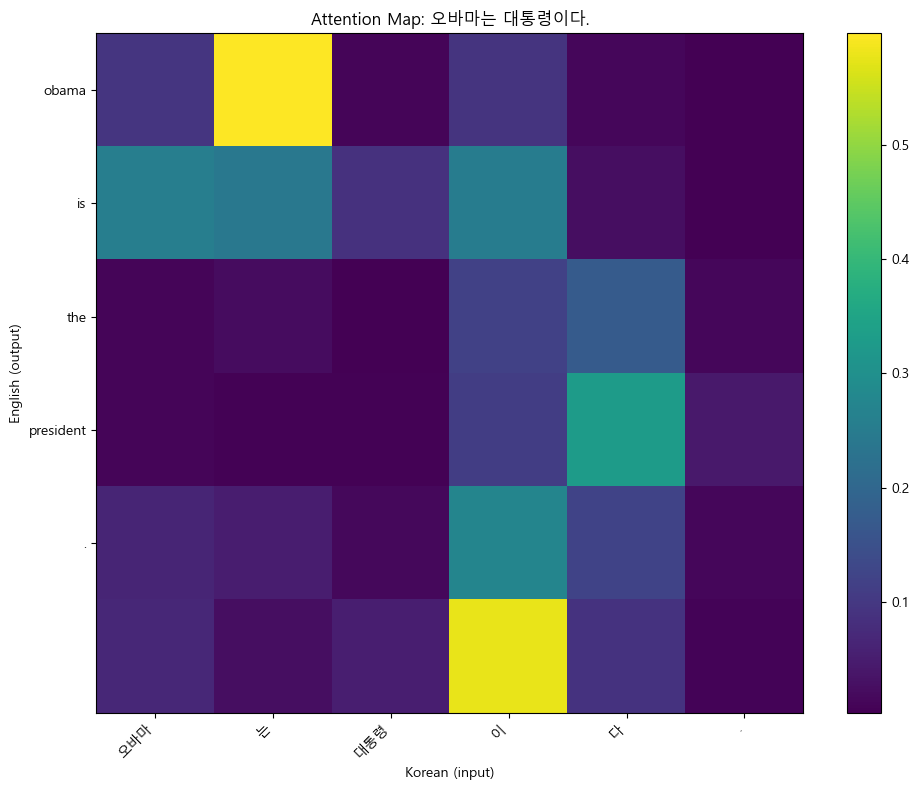

한국어: 시민들은 도시 속에 산다.
한국어 토큰: ['시민', '들', '은', '도시', '속', '에', '산다', '.']
번역  : many skiers are generally <unk> in the city .



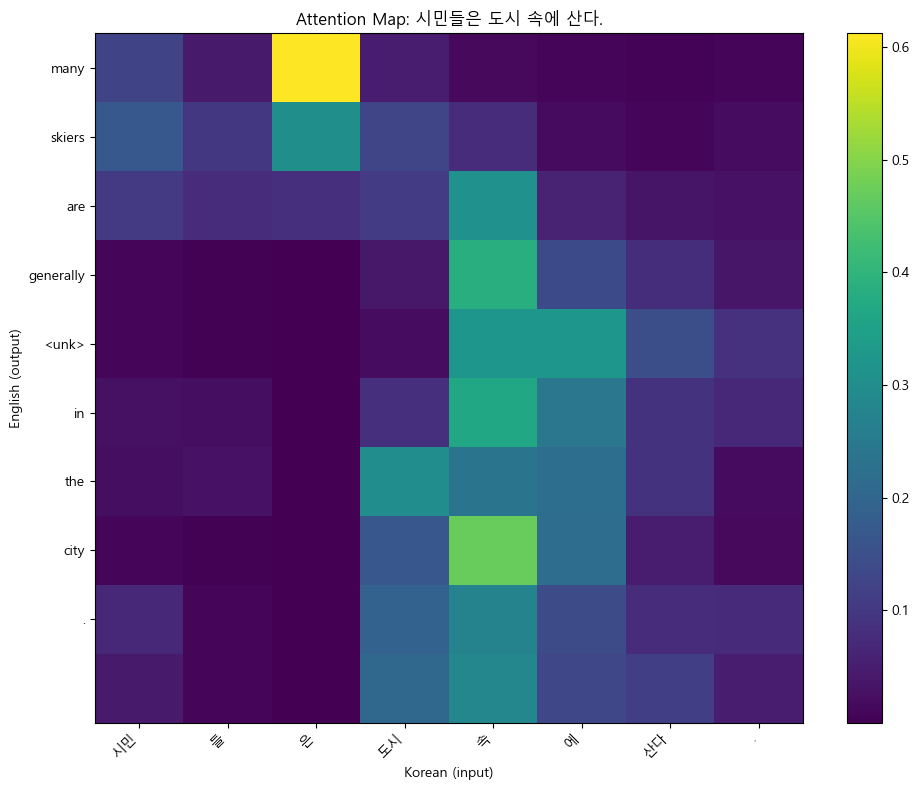

한국어: 커피는 필요 없다.
한국어 토큰: ['커피', '는', '필요', '없', '다', '.']
번역  : it is not always easy to protect questions .



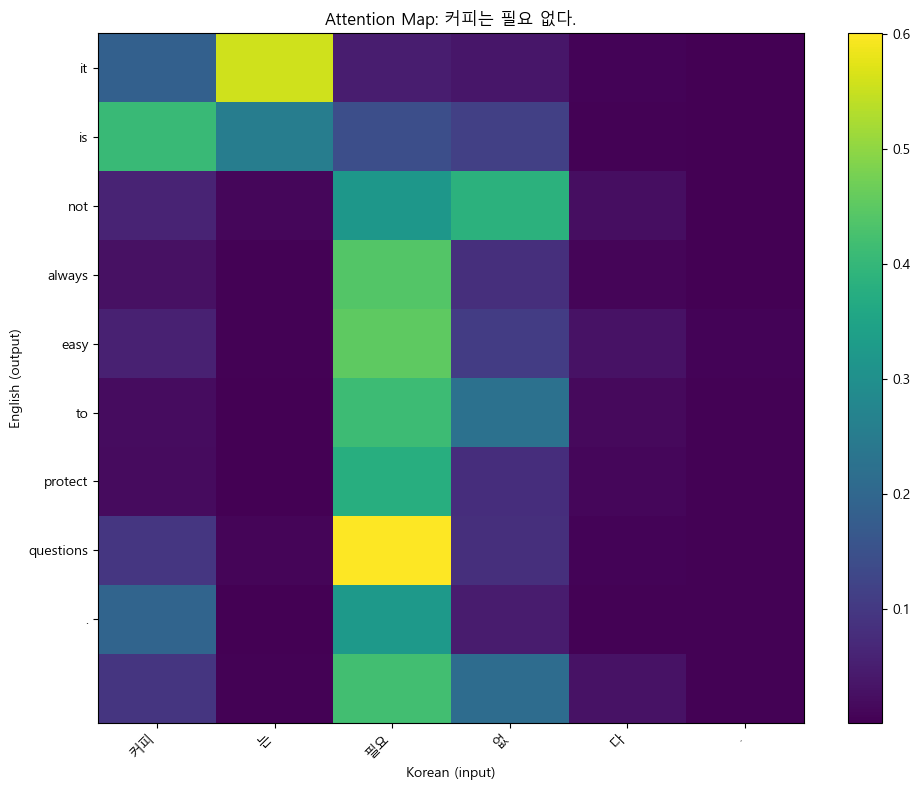

한국어: 일곱 명의 사망자가 발생했다.
한국어 토큰: ['일곱', '명', '의', '사망자', '가', '발생', '했', '다', '.']
번역  : the death toll dead death and death .



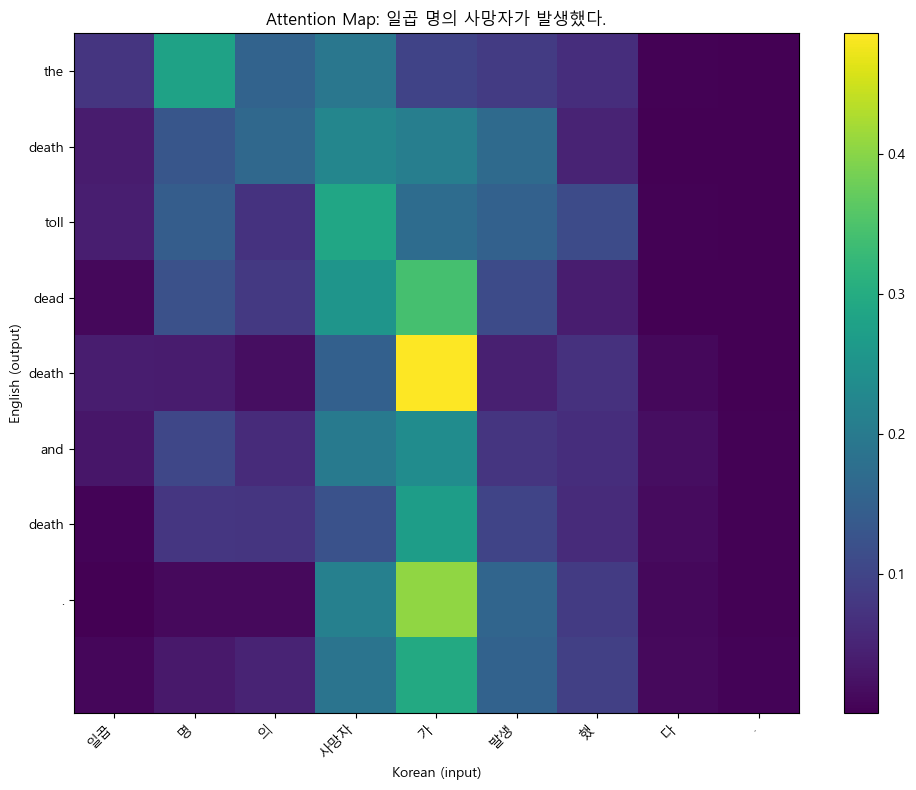

In [81]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# 1. 한국어 → ID 변환
# ============================================================
def preprocess_korean(text, ko_token2id, mecab, max_len=40):
    text = preprocess_kor(text)  # 학습 때와 동일 정제
    tokens = mecab.morphs(text)
    ids = [ko_token2id.get(token, 1) for token in tokens]
    ids = ids[:max_len]
    ids = ids + [0] * (max_len - len(ids))
    return torch.tensor([ids], dtype=torch.long), tokens[:max_len]


# ============================================================
# 2. 번역 함수
# ============================================================
def translate(sentence, encoder, decoder, ko_token2id, en_id2token, mecab, device, max_len=40):
    encoder.eval()
    decoder.eval()
    
    with torch.no_grad():
        src, ko_tokens = preprocess_korean(sentence, ko_token2id, mecab, max_len)
        src = src.to(device)
        
        encoder_outputs, encoder_hidden = encoder(src)
        decoder_hidden = encoder_hidden
        decoder_input = torch.tensor([[2]], dtype=torch.long).to(device)  # <start>
        
        output_words = []
        attention_matrix = []
        
        for t in range(max_len):
            output, decoder_hidden, attn_weights = decoder(decoder_input, decoder_hidden, encoder_outputs)
            predicted_id = output.argmax(dim=-1).item()
            attention_matrix.append(attn_weights.squeeze().cpu().numpy())
            
            if predicted_id == 3:  # <end>
                break
            
            word = en_id2token.get(predicted_id, '<unk>')
            output_words.append(word)
            
            decoder_input = torch.tensor([[predicted_id]], dtype=torch.long).to(device)
        
        return output_words, np.array(attention_matrix), ko_tokens


# ============================================================
# 3. Attention 시각화
# ============================================================
def plot_attention(attention, ko_tokens, en_tokens, title=""):
    fig, ax = plt.subplots(figsize=(10, 8))
    
    src_len = len(ko_tokens)
    attention = attention[:, :src_len]
    
    im = ax.imshow(attention, cmap='viridis', aspect='auto')
    
    ax.set_xticks(range(src_len))
    ax.set_xticklabels(ko_tokens, rotation=45, ha='right')
    ax.set_yticks(range(len(en_tokens)))
    ax.set_yticklabels(en_tokens)
    
    ax.set_xlabel('Korean (input)')
    ax.set_ylabel('English (output)')
    ax.set_title(f'Attention Map: {title}')
    
    plt.colorbar(im)
    plt.tight_layout()
    plt.show()


# ============================================================
# 4. 4개 예문 번역 + 시각화
# ============================================================
test_sentences = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다.",
]

for sentence in test_sentences:
    output_words, attention, ko_tokens = translate(
        sentence, encoder, decoder, 
        ko_token2id, en_id2token, tokenizer,  # ← 'mecab' → 'tokenizer'
        device
    )

    
    print(f"한국어: {sentence}")
    print(f"한국어 토큰: {ko_tokens}")
    print(f"번역  : {' '.join(output_words)}")
    print()
    
    plot_attention(attention, ko_tokens, output_words, title=sentence)

### 임베딩 가설 검증

**가설 형성:**
1차 학습 결과의 4개 예문 중 2,3,4번이 문맥을 못 잡고, 4번에서는 모든 단어를 "death"로 번역하는 등 단어 사이 관계를 아예 보지 못하는 모습이 보였음. 처음에는 어텐션이나 RNN 모델 자체의 한계도 의심했지만, 그것보다는 임베딩 좌표에서 단어들의 상관관계가 제대로 형성되지 않아서 맥락 없는 번역을 하는 게 아닐까라는 생각이 들었음.

**비교 실험 설계:**
임베딩 좌표만 변수로 바꾸고 나머지(모델 구조, 데이터, 하이퍼파라미터)는 통제하는 방식으로 검증하기로 함. 사전학습된 임베딩으로 word2vec을 사용함. word2vec은 2013년 모델로 사실상 고전이지만, 우리 mecab 토큰화와 호환 가능하고 빠른 검증에 적합했음. 

**v1 vs v2 비교:**
- v1: random init 임베딩 + 번역 task로 함께 학습
- v2: word2vec으로 의미 신호 사전학습 + 번역 task로 미세조정
- 다른 조건은 모두 동일

**검증 결과 (3중 확인):**

1. 번역 결과
   - v1: 1/4 정확 (오바마 외 모두 의미 무시)
   - v2: 3/4 의미 잡음 (커피 → coffee, 일곱 사망자 → seven deaths)

2. 가까운 단어 분석
   - v1: "일곱" 근처에 "유적지", "뭄바이" 등 무관한 단어
   - v2: "일곱" 근처에 "아홉", "147", "148" 등 수량 단어들

3. PCA 시각화
   - v1: 단어들이 무질서하게 분포, 의미 군집 안 보임
   - v2: 의미별 명확한 군집 형성
     - 사상자 군집 (사망자, 부상자, 실종자)
     - 정치인 군집 (오바마, 클린턴, 매케인)
     - 수량 군집 (일곱, 아홉, 147, 148)
     - 일상 군집 (커피, 마시, 식당)

**결론:**
임베딩이 단어 의미와 단어 사이 관계를 표현하지 못하면, 후속 layer가 아무리 좋아도 한계 명확. 같은 데이터로 word2vec 사전학습 추가하는 것만으로 결과가 명확히 개선됨. → 임베딩 품질이 모델 한계의 큰 부분.

**부수 발견 — Loss와 일반화의 분리:**
v1 final loss 1.39, v2 final loss 1.45 (v2가 살짝 높음)에도 불구하고 v2 평가 결과가 명확히 좋았음. Loss는 "학습 데이터 fit" 측정이지 "진짜 능력"은 아님. validation set 없는 학습의 맹점.

**미검증 가정 (구분해두기):**
- "작은 데이터에는 작은 모델이 우위" 라는 ML 일반 원리는 직감으로만, 우리 실험에서 직접 검증 안 함 (비교군 없음)
- 내일 트랜스포머 구현 후 부분적 비교 가능


In [82]:
# 4개 예문의 핵심 단어가 학습 데이터에 얼마나 있나
test_keywords = {
    "오바마는 대통령이다": ["오바마", "대통령"],
    "시민들은 도시 속에 산다": ["시민", "도시", "산다"],
    "커피는 필요 없다": ["커피", "필요"],
    "일곱 명의 사망자가 발생했다": ["일곱", "사망자", "발생"],
}

for sentence, keywords in test_keywords.items():
    print(f"\n=== {sentence} ===")
    for keyword in keywords:
        # 토큰 카운터에서 빈도 확인
        ko_freq = ko_token_counter.get(keyword, 0)
        # vocab에 들어갔나
        in_vocab = keyword in ko_token2id
        print(f"  '{keyword}': 빈도 {ko_freq}, vocab {'O' if in_vocab else 'X (<unk>)'}")


=== 오바마는 대통령이다 ===
  '오바마': 빈도 1214, vocab O
  '대통령': 빈도 3219, vocab O

=== 시민들은 도시 속에 산다 ===
  '시민': 빈도 281, vocab O
  '도시': 빈도 465, vocab O
  '산다': 빈도 0, vocab X (<unk>)

=== 커피는 필요 없다 ===
  '커피': 빈도 52, vocab O
  '필요': 빈도 553, vocab O

=== 일곱 명의 사망자가 발생했다 ===
  '일곱': 빈도 14, vocab O
  '사망자': 빈도 343, vocab O
  '발생': 빈도 1572, vocab O


In [83]:
# 학습 데이터에서 "X는 Y이다" 패턴이 얼마나 자주 있나
# 또는 "오바마" 들어간 문장 직접 찾기

# id_corpus에서 "오바마" 토큰 ID 찾기
obama_id = ko_token2id.get("오바마", -1)
print(f"'오바마' ID: {obama_id}")

# id_corpus에서 "오바마" 포함하는 시퀀스 개수
count = 0
for ko_ids, en_ids in id_corpus:
    if obama_id in ko_ids:
        count += 1
        if count <= 3:  # 처음 3개만 출력
            ko_tokens = [ko_id2token.get(i, '?') for i in ko_ids if i != 0]
            en_tokens = [en_id2token.get(i, '?') for i in en_ids if i != 0]
            print(f"  KO: {' '.join(ko_tokens)}")
            print(f"  EN: {' '.join(en_tokens)}")

print(f"\n'오바마' 포함 시퀀스 총 {count}개")

'오바마' ID: 115
  KO: 오바마 는 331 명 의 슈퍼 대 의원 을 확보 했 고 클린턴 도 <unk> 명 으로부터 지지 를 받 았 다 .
  EN: <start> obama has the support of 331 superdelegates to clinton s <unk> . <end>
  KO: 클린턴 은 미니 수퍼 화요일 경선 중 텍사스 , 오하 이 오 , 로드 아일랜드 에서 승리 했으며 오바마 는 4 개주 가운데 유일 하 게 버몬트 에서 이겼 다 .
  EN: <start> clinton won in texas , ohio , and rhode island , while obama won vermont . <end>
  KO: 게이츠 장관 은 오바마 대통령 이 내민 화해 의 손길 에 대해 이란 이 처음 보인 반응 이 그렇게 만족 스러운 것 은 아니 라고 말 합니다 .
  EN: <start> the pentagon chief says the early response out of <unk> to president barack obama s outreach is not very encouraging <end>

'오바마' 포함 시퀀스 총 1159개


In [85]:
pip install gensim

   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ----- ---------------------------------- 3.1/24.4 MB 30.7 MB/s eta 0:00:01
   ------------------ --------------------- 11.3/24.4 MB 28.2 MB/s eta 0:00:01
   ------------------------------ --------- 18.9/24.4 MB 34.0 MB/s eta 0:00:01
   ---------------------------------------  23.9/24.4 MB 29.0 MB/s eta 0:00:01
   ---------------------------------------- 24.4/24.4 MB 28.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   ---------- ----------------------------- 9.2/36.5 MB 43.9 MB/s eta 0:00:01
   --------------------- ------------------ 19.4/36.5 MB 45.3 MB/s eta 0:00:01
   ------------------------------- -------- 29.1/36.5 MB 45.0 MB/s eta 0:00:01
   ---------------------------------------- 36.5/36.5 MB 43.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [86]:
from gensim.models import Word2Vec
import numpy as np

# ============================================================
# 1. 학습 데이터에서 토큰 시퀀스 추출 (id → token)
# ============================================================
ko_sentences = [[ko_id2token[i] for i in ko_ids if i != 0] 
                for ko_ids, _ in id_corpus]
en_sentences = [[en_id2token[i] for i in en_ids if i != 0] 
                for _, en_ids in id_corpus]

print(f"한국어 문장 수: {len(ko_sentences)}")
print(f"영어 문장 수: {len(en_sentences)}")

# ============================================================
# 2. Word2Vec 학습 (skip-gram, 256차원)
# ============================================================
print("\nWord2Vec 학습 중...")
ko_w2v = Word2Vec(
    ko_sentences, 
    vector_size=EMBEDDING_DIM,  # 256
    window=5, 
    min_count=1,  # 모든 단어 학습 (vocab과 일치하게)
    sg=1,  # skip-gram
    workers=4,
    epochs=10
)
en_w2v = Word2Vec(
    en_sentences, 
    vector_size=EMBEDDING_DIM,
    window=5, 
    min_count=1,
    sg=1,
    workers=4,
    epochs=10
)
print("Word2Vec 학습 완료")

# ============================================================
# 3. 임베딩 매트릭스 만들기
# ============================================================
ko_embedding_matrix = np.zeros((VOCAB_SIZE, EMBEDDING_DIM))
en_embedding_matrix = np.zeros((VOCAB_SIZE, EMBEDDING_DIM))

ko_found, en_found = 0, 0

for token, idx in ko_token2id.items():
    if token in ko_w2v.wv:
        ko_embedding_matrix[idx] = ko_w2v.wv[token]
        ko_found += 1

for token, idx in en_token2id.items():
    if token in en_w2v.wv:
        en_embedding_matrix[idx] = en_w2v.wv[token]
        en_found += 1

print(f"\n한국어 매칭: {ko_found}/{VOCAB_SIZE}")
print(f"영어 매칭: {en_found}/{VOCAB_SIZE}")

# ============================================================
# 4. 모델에 새 임베딩 박기 (재학습 위해 새 모델 생성)
# ============================================================
encoder_v2 = Encoder(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM).to(device)
decoder_v2 = Decoder(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM).to(device)

# 임베딩 layer에 word2vec 가중치 박기
encoder_v2.embedding.weight.data = torch.tensor(ko_embedding_matrix, dtype=torch.float32).to(device)
decoder_v2.embedding.weight.data = torch.tensor(en_embedding_matrix, dtype=torch.float32).to(device)

# Optimizer 새로 (새 모델이라)
encoder_v2_optimizer = optim.Adam(encoder_v2.parameters(), lr=0.001)
decoder_v2_optimizer = optim.Adam(decoder_v2.parameters(), lr=0.001)

print("\n새 모델 생성 + 임베딩 교체 완료")
print("이제 재학습 또는 평가 가능")

한국어 문장 수: 57272
영어 문장 수: 57272

Word2Vec 학습 중...
Word2Vec 학습 완료

한국어 매칭: 17997/18000
영어 매칭: 17999/18000

새 모델 생성 + 임베딩 교체 완료
이제 재학습 또는 평가 가능


In [87]:
import time

print(f"Word2Vec 임베딩 + 새 모델 학습 시작")
print(f"Total batches per epoch: {len(dataloader)}")
print()

train_losses_v2 = []  # v2 학습 loss 추적

for epoch in range(NUM_EPOCHS):
    encoder_v2.train()
    decoder_v2.train()
    
    epoch_loss = 0
    start_time = time.time()
    
    for batch_idx, (src, tgt) in enumerate(dataloader):
        loss = train_step(src, tgt, encoder_v2, decoder_v2,
                          encoder_v2_optimizer, decoder_v2_optimizer,
                          criterion, device)
        epoch_loss += loss
        
        if (batch_idx + 1) % 200 == 0:  # 200마다 (덜 시끄럽게)
            print(f"Epoch {epoch+1} | Batch {batch_idx+1}/{len(dataloader)} | "
                  f"Loss: {loss:.4f}")
    
    avg_loss = epoch_loss / len(dataloader)
    train_losses_v2.append(avg_loss)
    elapsed = time.time() - start_time
    
    print(f"=== Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Avg Loss: {avg_loss:.4f} | "
          f"Time: {elapsed:.1f}s ===\n")

print("학습 완료!")
print(f"Final avg loss (v2): {train_losses_v2[-1]:.4f}")
print(f"기존 모델 final loss: {train_losses[-1]:.4f}")

Word2Vec 임베딩 + 새 모델 학습 시작
Total batches per epoch: 895

Epoch 1 | Batch 200/895 | Loss: 5.6773
Epoch 1 | Batch 400/895 | Loss: 5.4637
Epoch 1 | Batch 600/895 | Loss: 4.8570
Epoch 1 | Batch 800/895 | Loss: 4.9037
=== Epoch 1/10 | Avg Loss: 5.3004 | Time: 116.2s ===

Epoch 2 | Batch 200/895 | Loss: 4.2469
Epoch 2 | Batch 400/895 | Loss: 4.0345
Epoch 2 | Batch 600/895 | Loss: 3.9234
Epoch 2 | Batch 800/895 | Loss: 4.1199
=== Epoch 2/10 | Avg Loss: 4.0742 | Time: 116.7s ===

Epoch 3 | Batch 200/895 | Loss: 3.1932
Epoch 3 | Batch 400/895 | Loss: 3.5010
Epoch 3 | Batch 600/895 | Loss: 3.4146
Epoch 3 | Batch 800/895 | Loss: 3.4630
=== Epoch 3/10 | Avg Loss: 3.4582 | Time: 117.0s ===

Epoch 4 | Batch 200/895 | Loss: 2.9918
Epoch 4 | Batch 400/895 | Loss: 3.1790
Epoch 4 | Batch 600/895 | Loss: 3.0299
Epoch 4 | Batch 800/895 | Loss: 2.8347
=== Epoch 4/10 | Avg Loss: 2.9941 | Time: 115.1s ===

Epoch 5 | Batch 200/895 | Loss: 2.5365
Epoch 5 | Batch 400/895 | Loss: 2.8672
Epoch 5 | Batch 600/895 | 

In [88]:
import numpy as np

# ============================================================
# 1. v2 모델 평가 (4개 예문)
# ============================================================
print("=" * 60)
print("v2 모델 평가 (Word2Vec 임베딩 초기화)")
print("=" * 60)

for sentence in test_sentences:
    output_words, attention, ko_tokens = translate(
        sentence, encoder_v2, decoder_v2, 
        ko_token2id, en_id2token, tokenizer,
        device
    )
    
    print(f"\n한국어: {sentence}")
    print(f"한국어 토큰: {ko_tokens}")
    print(f"번역  : {' '.join(output_words)}")

# ============================================================
# 2. 임베딩 norm 분포 비교 (v1 vs v2)
# ============================================================
print("\n" + "=" * 60)
print("임베딩 norm 분포 비교")
print("=" * 60)

ko_emb_v1 = encoder.embedding.weight.data.cpu().numpy()
ko_emb_v2 = encoder_v2.embedding.weight.data.cpu().numpy()

def analyze_norms(emb, token2id, token_counter, label):
    high_freq, mid_freq, low_freq = [], [], []
    for token, idx in token2id.items():
        freq = token_counter.get(token, 0)
        norm = np.linalg.norm(emb[idx])
        if freq >= 100:
            high_freq.append(norm)
        elif freq >= 10:
            mid_freq.append(norm)
        elif freq >= 1:
            low_freq.append(norm)
    
    print(f"\n{label}:")
    print(f"  고빈도 (100+): 평균 norm {np.mean(high_freq):.3f} (n={len(high_freq)})")
    print(f"  중빈도 (10-99): 평균 norm {np.mean(mid_freq):.3f} (n={len(mid_freq)})")
    print(f"  저빈도 (1-9): 평균 norm {np.mean(low_freq):.3f} (n={len(low_freq)})")

analyze_norms(ko_emb_v1, ko_token2id, ko_token_counter, "v1 (random init)")
analyze_norms(ko_emb_v2, ko_token2id, ko_token_counter, "v2 (word2vec init)")

# ============================================================
# 3. 의미 검증 (가까운 단어 찾기)
# ============================================================
print("\n" + "=" * 60)
print("의미 검증: 가까운 단어 5개")
print("=" * 60)

def find_neighbors(word, embedding, token2id, id2token, top_k=5):
    if word not in token2id:
        return None
    word_vec = embedding[token2id[word]]
    norms = np.linalg.norm(embedding, axis=1)
    word_norm = np.linalg.norm(word_vec)
    if word_norm < 1e-6:
        return None
    similarities = embedding @ word_vec / (norms * word_norm + 1e-8)
    top_ids = np.argsort(-similarities)[1:top_k+1]
    return [(id2token[i], float(similarities[i])) for i in top_ids]

test_words = ["오바마", "대통령", "커피", "사망자", "일곱"]

for word in test_words:
    print(f"\n'{word}' 근처 단어:")
    
    v1_neighbors = find_neighbors(word, ko_emb_v1, ko_token2id, ko_id2token)
    v2_neighbors = find_neighbors(word, ko_emb_v2, ko_token2id, ko_id2token)
    
    print(f"  v1: {[n for n, _ in v1_neighbors] if v1_neighbors else 'N/A'}")
    print(f"  v2: {[n for n, _ in v2_neighbors] if v2_neighbors else 'N/A'}")

v2 모델 평가 (Word2Vec 임베딩 초기화)

한국어: 오바마는 대통령이다.
한국어 토큰: ['오바마', '는', '대통령', '이', '다', '.']
번역  : obama is the president .

한국어: 시민들은 도시 속에 산다.
한국어 토큰: ['시민', '들', '은', '도시', '속', '에', '산다', '.']
번역  : the protesters are <unk> in the city .

한국어: 커피는 필요 없다.
한국어 토큰: ['커피', '는', '필요', '없', '다', '.']
번역  : the coffee is need

한국어: 일곱 명의 사망자가 발생했다.
한국어 토큰: ['일곱', '명', '의', '사망자', '가', '발생', '했', '다', '.']
번역  : seven deaths have been killed .

임베딩 norm 분포 비교

v1 (random init):
  고빈도 (100+): 평균 norm 16.283 (n=1468)
  중빈도 (10-99): 평균 norm 16.136 (n=6910)
  저빈도 (1-9): 평균 norm 16.092 (n=9618)

v2 (word2vec init):
  고빈도 (100+): 평균 norm 4.474 (n=1468)
  중빈도 (10-99): 평균 norm 3.280 (n=6910)
  저빈도 (1-9): 평균 norm 2.515 (n=9618)

의미 검증: 가까운 단어 5개

'오바마' 근처 단어:
  v1: ['순손실', '클리브랜드', '쓴', '논점', '홈피']
  v2: ['클린턴', '버락', '매케인', '힐러리', '오마']

'대통령' 근처 단어:
  v1: ['긴급회의', '수역', '의문점', '보이콧', '여군']
  v2: ['블라디미르', '노무현', '총통', '부시', '이명박']

'커피' 근처 단어:
  v1: ['시찰', '기울', '폭스', '타임즈', '체흐']
  v2: ['카페인', '마시',

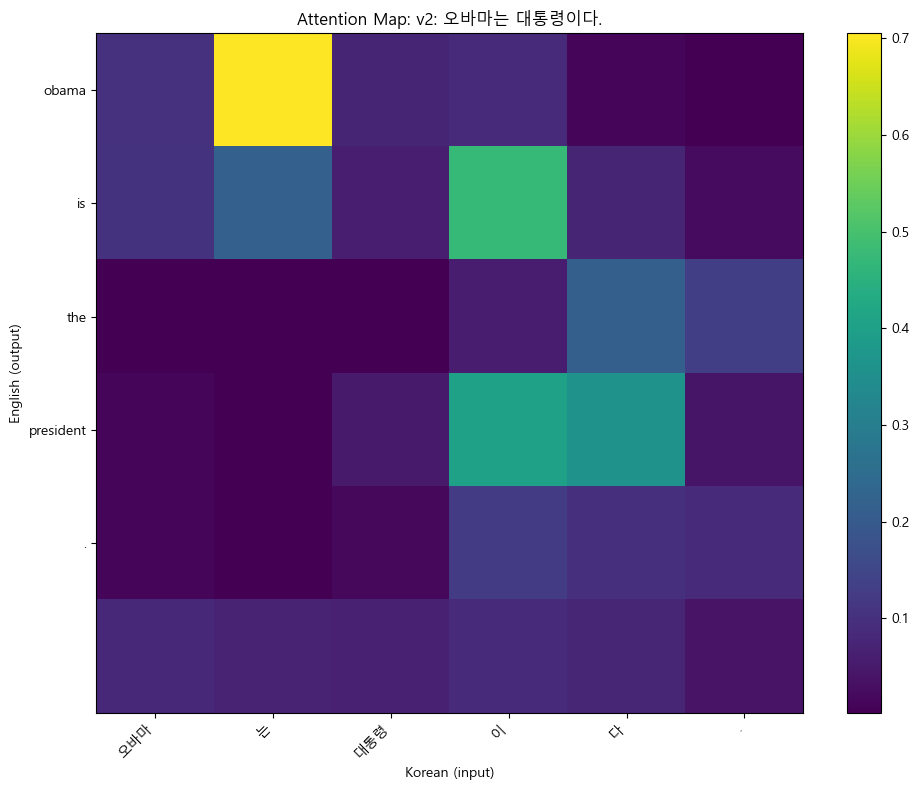

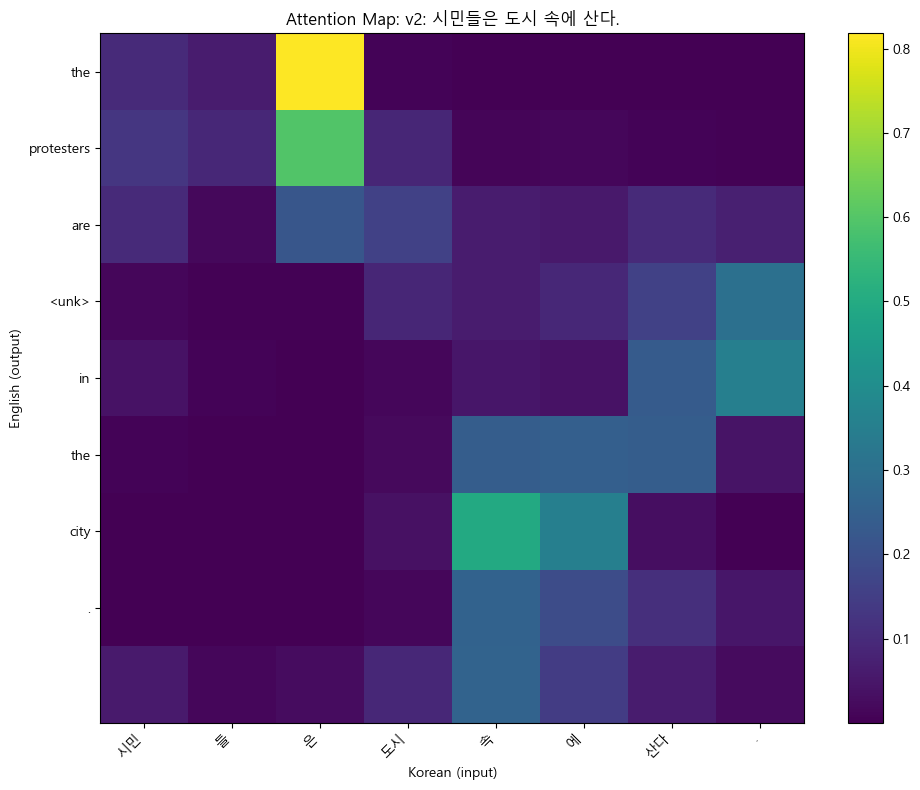

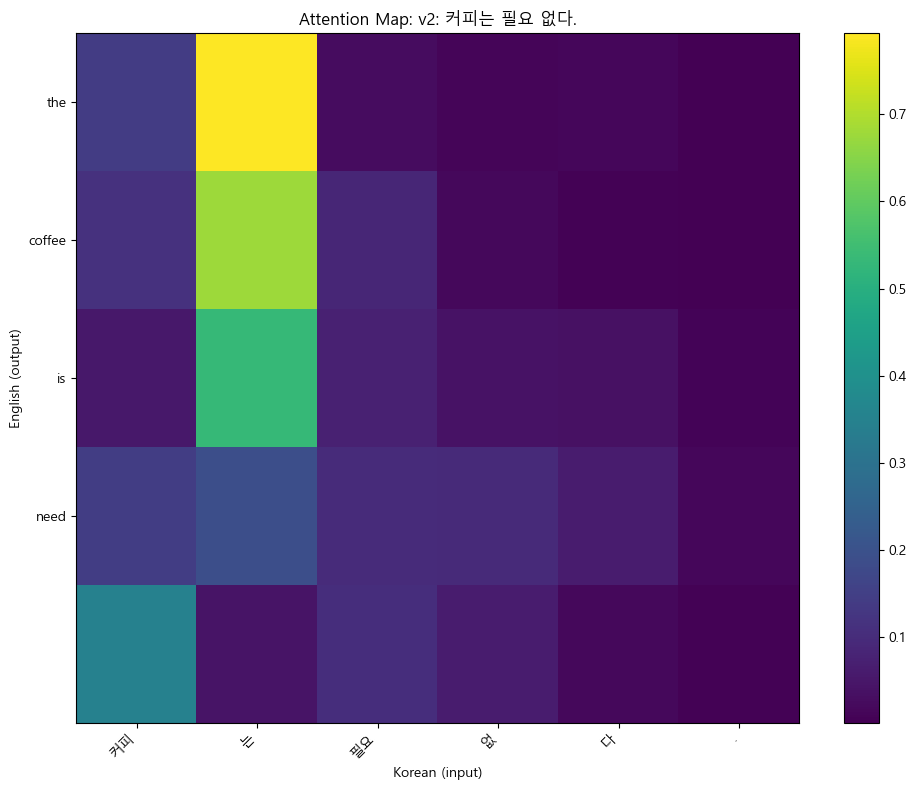

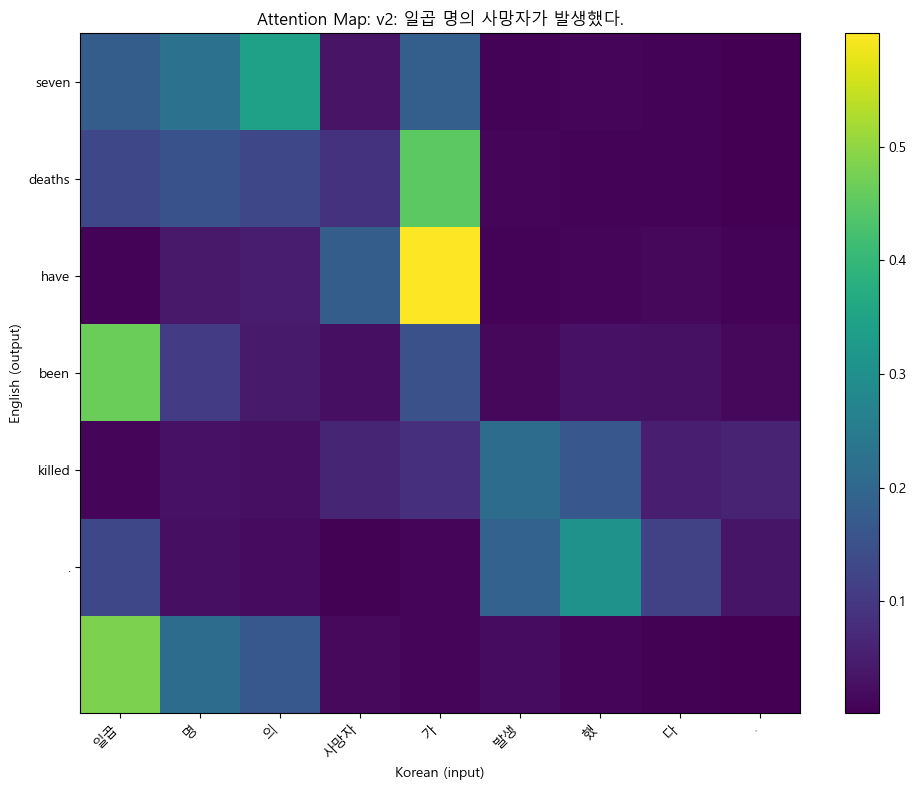

In [89]:
# v2의 attention map 시각화
for sentence in test_sentences:
    output_words, attention, ko_tokens = translate(
        sentence, encoder_v2, decoder_v2, 
        ko_token2id, en_id2token, tokenizer,
        device
    )
    plot_attention(attention, ko_tokens, output_words, title=f"v2: {sentence}")

In [91]:
pip install scikit-learn

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   -------------------------- ------------- 5.2/8.0 MB 31.9 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 31.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


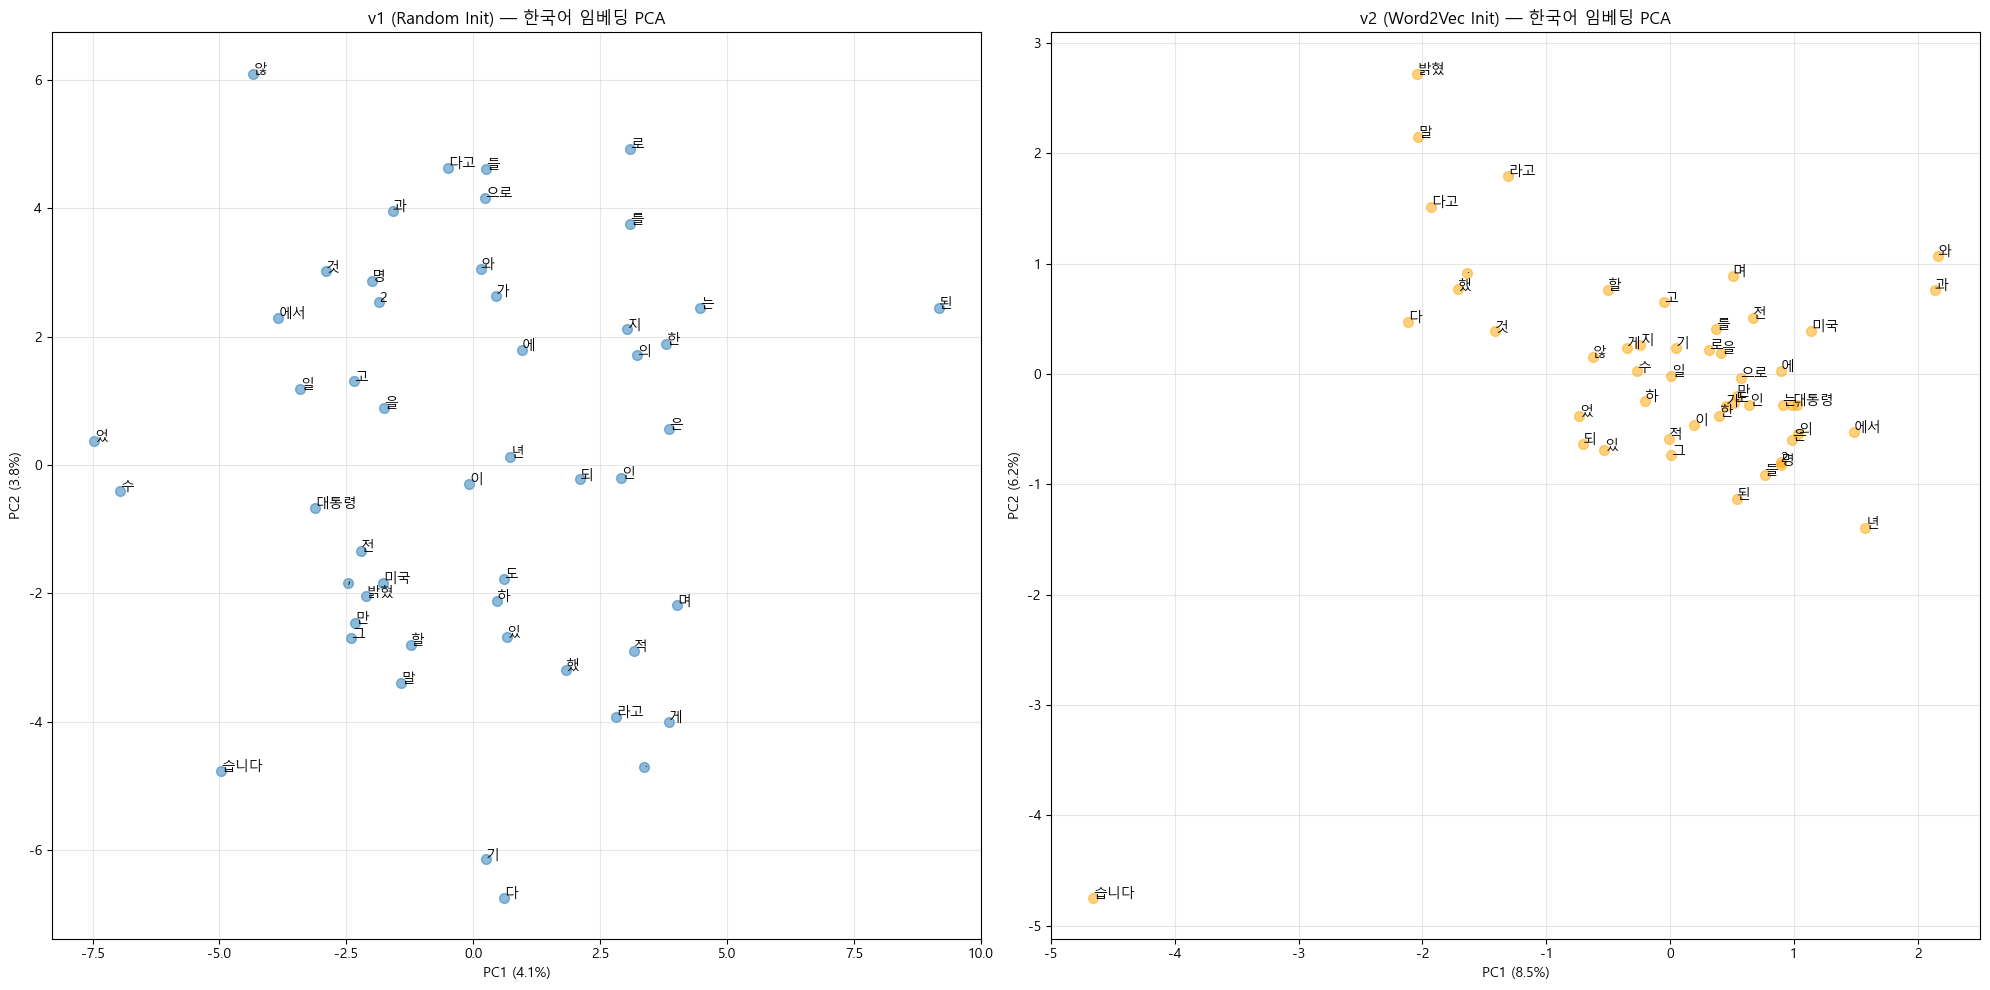

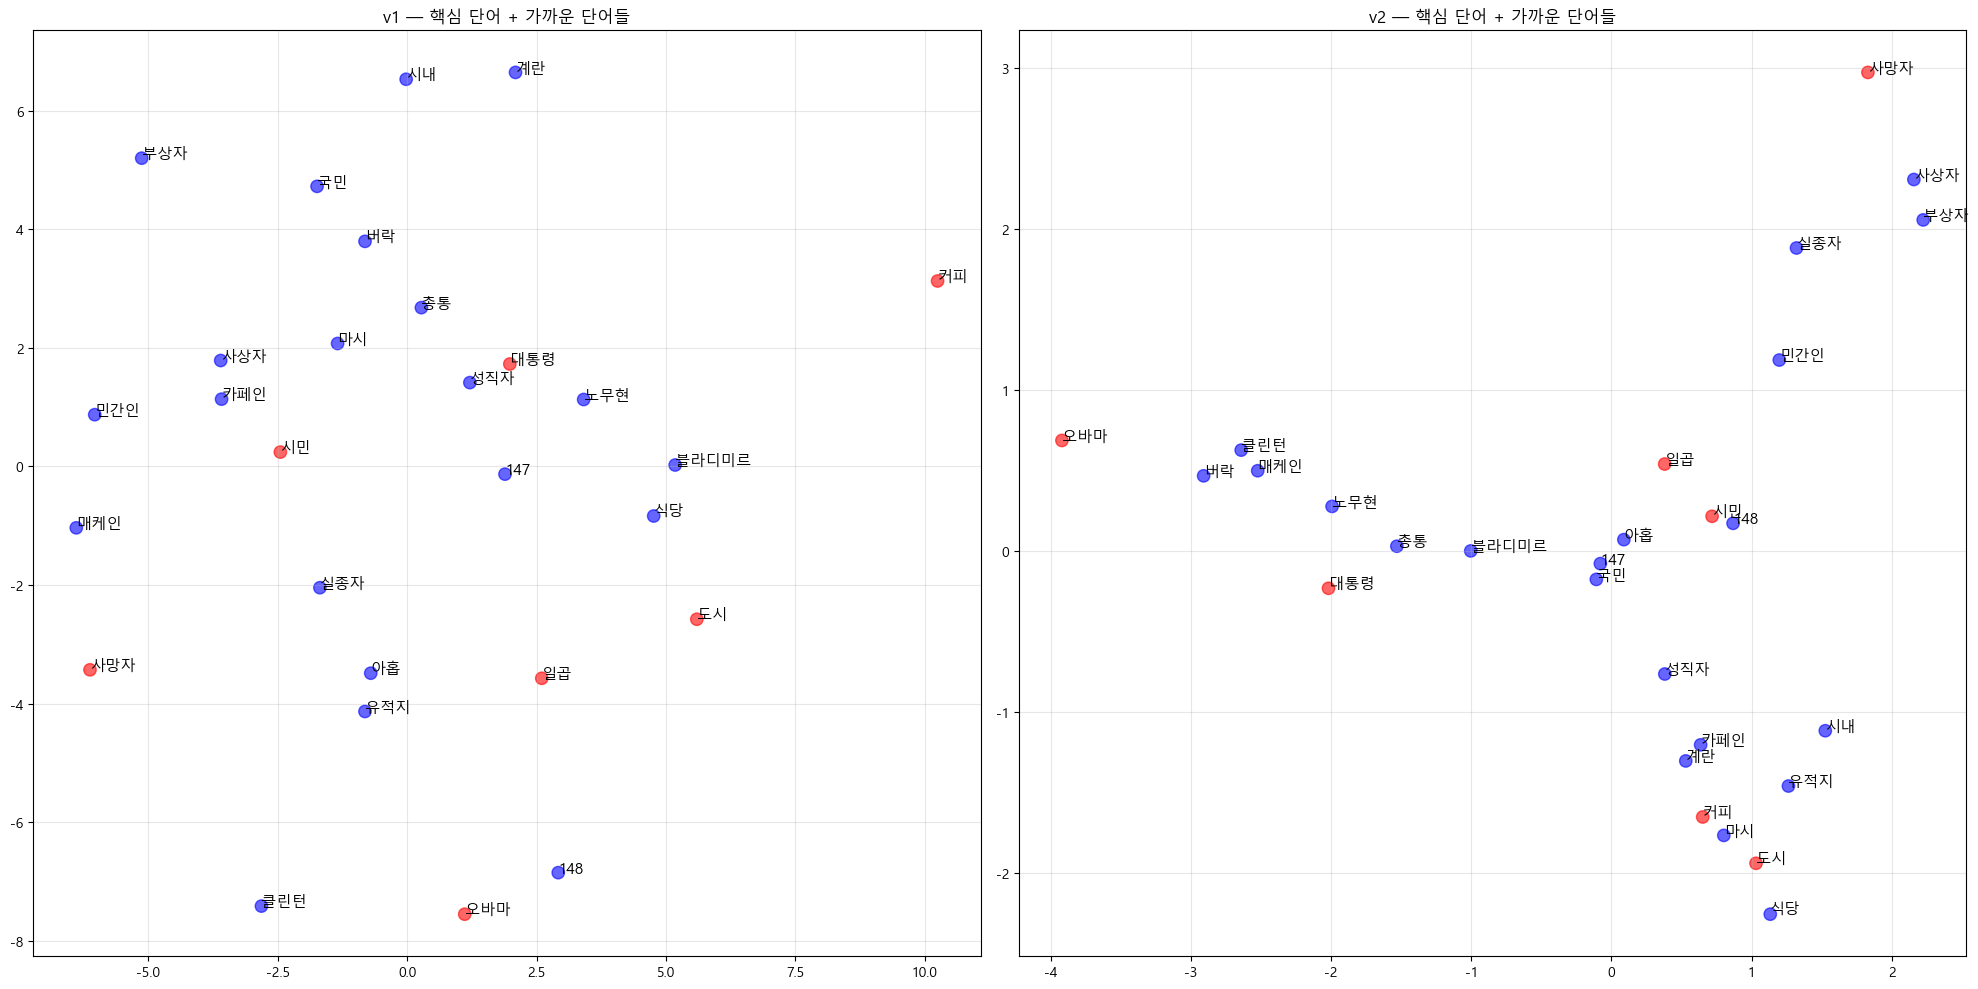

In [92]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ============================================================
# 한국어 임베딩 시각화 (v1 vs v2)
# ============================================================

# 빈도 상위 50개 단어만 (너무 많으면 안 보임)
top_words = [token for token, _ in ko_token_counter.most_common(50)]
top_ids = [ko_token2id[w] for w in top_words if w in ko_token2id]
visible_words = [w for w in top_words if w in ko_token2id][:len(top_ids)]

# v1, v2 임베딩 추출
top_emb_v1 = ko_emb_v1[top_ids]
top_emb_v2 = ko_emb_v2[top_ids]

# PCA 2D
pca_v1 = PCA(n_components=2)
pca_v2 = PCA(n_components=2)
emb_2d_v1 = pca_v1.fit_transform(top_emb_v1)
emb_2d_v2 = pca_v2.fit_transform(top_emb_v2)

# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 두 개 subplot으로 나란히
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# v1
axes[0].scatter(emb_2d_v1[:, 0], emb_2d_v1[:, 1], alpha=0.5, s=50)
for i, word in enumerate(visible_words):
    axes[0].annotate(word, (emb_2d_v1[i, 0], emb_2d_v1[i, 1]), fontsize=10)
axes[0].set_title("v1 (Random Init) — 한국어 임베딩 PCA")
axes[0].set_xlabel(f"PC1 ({pca_v1.explained_variance_ratio_[0]:.1%})")
axes[0].set_ylabel(f"PC2 ({pca_v1.explained_variance_ratio_[1]:.1%})")
axes[0].grid(alpha=0.3)

# v2
axes[1].scatter(emb_2d_v2[:, 0], emb_2d_v2[:, 1], alpha=0.5, s=50, color='orange')
for i, word in enumerate(visible_words):
    axes[1].annotate(word, (emb_2d_v2[i, 0], emb_2d_v2[i, 1]), fontsize=10)
axes[1].set_title("v2 (Word2Vec Init) — 한국어 임베딩 PCA")
axes[1].set_xlabel(f"PC1 ({pca_v2.explained_variance_ratio_[0]:.1%})")
axes[1].set_ylabel(f"PC2 ({pca_v2.explained_variance_ratio_[1]:.1%})")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 4개 예문 핵심 단어 + 의미 비슷한 단어들 시각화
# ============================================================

# 핵심 단어들 + 그들의 가까운 단어들 (v2 기준)
focus_words = ["오바마", "대통령", "커피", "사망자", "일곱", "도시", "시민"]
related_words_v2 = []

for word in focus_words:
    if word in ko_token2id:
        neighbors = find_neighbors(word, ko_emb_v2, ko_token2id, ko_id2token, top_k=3)
        if neighbors:
            related_words_v2.extend([n for n, _ in neighbors])

# 중복 제거
all_words = list(set(focus_words + related_words_v2))
all_ids = [ko_token2id[w] for w in all_words if w in ko_token2id]
visible_all = [w for w in all_words if w in ko_token2id]

# 임베딩
emb_focus_v1 = ko_emb_v1[all_ids]
emb_focus_v2 = ko_emb_v2[all_ids]

# PCA
emb_focus_2d_v1 = PCA(n_components=2).fit_transform(emb_focus_v1)
emb_focus_2d_v2 = PCA(n_components=2).fit_transform(emb_focus_v2)

# 색깔 — focus 단어 빨강, 나머지 파랑
colors = ['red' if w in focus_words else 'blue' for w in visible_all]

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

axes[0].scatter(emb_focus_2d_v1[:, 0], emb_focus_2d_v1[:, 1], c=colors, s=80, alpha=0.6)
for i, word in enumerate(visible_all):
    axes[0].annotate(word, (emb_focus_2d_v1[i, 0], emb_focus_2d_v1[i, 1]), fontsize=11)
axes[0].set_title("v1 — 핵심 단어 + 가까운 단어들")
axes[0].grid(alpha=0.3)

axes[1].scatter(emb_focus_2d_v2[:, 0], emb_focus_2d_v2[:, 1], c=colors, s=80, alpha=0.6)
for i, word in enumerate(visible_all):
    axes[1].annotate(word, (emb_focus_2d_v2[i, 0], emb_focus_2d_v2[i, 1]), fontsize=11)
axes[1].set_title("v2 — 핵심 단어 + 가까운 단어들")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 임베딩 시각화로 차이 확인
- v1 vs v2 PCA 시각화 비교
- v1: 단어들 무질서 분포 (의미 군집 안 보임)
- v2: 의미별 명확한 군집
  - 사상자 군집 (사망자, 부상자, 사상자)
  - 정치인 군집 (오바마, 클린턴, 매케인)
  - 수량 군집 (일곱, 아홉, 147, 148)
  - 일상 군집 (커피, 마시, 식당)
- 시각적 증거가 가설을 입증 (임베딩 품질이 결과의 큰 부분)

### 번외, 트랜스포머 구현 

- 인코더+디코더 구조의 트랜스포머 구조를 썼음. 사실 좀 오래된 트랜스포머 구조이지 않은가 하는 생각이 듬.
- 2017년 처음 나온 트랜스포머 구조로 가기로 했고, 큰 모델이 필요하다는 생각이 들지 않았던 점도 있음. 그래서 레이어도 총 4개로 이뤄져 있음 (Encoder × 2 + Decoder × 2, 17.5M 파라미터).
- 임베딩 모델은 이전 RNN 모델에서와 같은 방식으로 word2vec 학습. 모델 구조에 대한 퀄리티 차이를 확인하고 싶었기 때문에 임베딩 세팅은 동일하게 유지. 
- 단, 노트북이 초기화되어서 어제 학습한 임베딩 자체가 아니라 같은 데이터/같은 설정으로 재학습함. 결과는 거의 동일하지만 엄밀한 변수 통제는 아니었음.

In [4]:
# ============================================================
# 셀 1: 데이터 준비 + 임베딩 + Transformer 모델 정의
# ============================================================

import re
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from collections import Counter
from mecab import MeCab
from gensim.models import Word2Vec

# ============================================================
# 하이퍼파라미터
# ============================================================
VOCAB_SIZE = 18000
EMBEDDING_DIM = 256
MAX_LEN = 40

# Transformer hyperparameters (작은 크기, Bahdanau와 비슷)
NUM_LAYERS = 2
NUM_HEADS = 4
D_FF = 1024
DROPOUT = 0.1

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ============================================================
# 1. 데이터 로드
# ============================================================
KO_PATH = r"C:\Users\akals\Downloads\korean-english-park.train\korean-english-park.train.ko"
EN_PATH = r"C:\Users\akals\Downloads\korean-english-park.train\korean-english-park.train.en"

with open(KO_PATH, 'r', encoding='utf-8') as f:
    ko_lines = [line.strip() for line in f]
with open(EN_PATH, 'r', encoding='utf-8') as f:
    en_lines = [line.strip() for line in f]

print(f"원본: 한국어 {len(ko_lines)}, 영어 {len(en_lines)}")

# ============================================================
# 2. 정제 함수
# ============================================================
def preprocess_eng(sentence, s_token=False, e_token=False):
    sentence = sentence.lower().strip()
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    sentence = re.sub(r"[^a-zA-Z0-9?.!,]+", " ", sentence)
    sentence = sentence.strip()
    if s_token:
        sentence = '<start> ' + sentence
    if e_token:
        sentence += ' <end>'
    return sentence

def preprocess_kor(sentence, s_token=False, e_token=False):
    sentence = sentence.strip()
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    sentence = re.sub(r"[^가-힣ㄱ-ㅎㅏ-ㅣ0-9?.!,]+", " ", sentence)
    sentence = sentence.strip()
    if s_token:
        sentence = '<start> ' + sentence
    if e_token:
        sentence += ' <end>'
    return sentence

def is_noise(sentence):
    """노이즈 패턴 감지"""
    s = sentence.strip()
    # 1단어 + ":"
    if re.match(r'^\S+\s*:', s) and len(s.split()) <= 2:
        return True
    # URL 마커
    if 'http' in s or '##' in s:
        return True
    # 사전형 (/ 3개 이상)
    if s.count('/') >= 3:
        return True
    return False

# ============================================================
# 3. 정제 + 노이즈 제거 + 비율 필터 + 중복 제거
# ============================================================
print("\n데이터 정제 중...")

# 길이 비율 필터링 (한국어 길이 / 영어 길이)
filtered = []
for ko, en in zip(ko_lines, en_lines):
    if len(en) == 0:
        continue
    ratio = len(ko) / len(en)
    if 0.3 <= ratio <= 1.5:
        filtered.append((ko, en))

# 노이즈 제거
filtered = [(ko, en) for ko, en in filtered 
            if not is_noise(ko) and not is_noise(en)]

# 정제 함수 적용
cleaned = []
for ko, en in filtered:
    ko_clean = preprocess_kor(ko)
    en_clean = preprocess_eng(en, s_token=True, e_token=True)
    if ko_clean and en_clean:
        cleaned.append((ko_clean, en_clean))

# 중복 제거
seen = set()
unique = []
for ko, en in cleaned:
    key = (ko, en)
    if key not in seen:
        seen.add(key)
        unique.append((ko, en))

print(f"정제 후: {len(unique)}쌍")

# ============================================================
# 4. 토큰화 + 길이 40 필터
# ============================================================
print("\n토큰화 중...")
mecab_inst = MeCab()

token_corpus = []
for ko, en in unique:
    ko_tokens = mecab_inst.morphs(ko)
    en_tokens = en.split()
    if len(ko_tokens) <= MAX_LEN and len(en_tokens) <= MAX_LEN:
        token_corpus.append((ko_tokens, en_tokens))

print(f"토큰화 후: {len(token_corpus)}쌍")

# ============================================================
# 5. Vocab 빌드
# ============================================================
print("\nVocab 빌드 중...")
ko_token_counter = Counter()
en_token_counter = Counter()

for ko_tokens, en_tokens in token_corpus:
    ko_token_counter.update(ko_tokens)
    en_token_counter.update(en_tokens)

# 특수 토큰 + 빈도 상위
SPECIAL_TOKENS = ['<pad>', '<unk>', '<start>', '<end>']

ko_token2id = {tok: i for i, tok in enumerate(SPECIAL_TOKENS)}
for token, _ in ko_token_counter.most_common(VOCAB_SIZE - len(SPECIAL_TOKENS)):
    if token not in ko_token2id:
        ko_token2id[token] = len(ko_token2id)

en_token2id = {tok: i for i, tok in enumerate(SPECIAL_TOKENS)}
for token, _ in en_token_counter.most_common(VOCAB_SIZE - len(SPECIAL_TOKENS)):
    if token not in en_token2id:
        en_token2id[token] = len(en_token2id)

ko_id2token = {v: k for k, v in ko_token2id.items()}
en_id2token = {v: k for k, v in en_token2id.items()}

print(f"한국어 vocab: {len(ko_token2id)}, 영어 vocab: {len(en_token2id)}")

# ============================================================
# 6. ID 변환 + 패딩
# ============================================================
print("\nID 변환 + 패딩 중...")
def tokens_to_ids(tokens, token2id, max_len):
    ids = [token2id.get(t, 1) for t in tokens][:max_len]
    ids = ids + [0] * (max_len - len(ids))
    return ids

id_corpus = []
for ko_tokens, en_tokens in token_corpus:
    ko_ids = tokens_to_ids(ko_tokens, ko_token2id, MAX_LEN)
    en_ids = tokens_to_ids(en_tokens, en_token2id, MAX_LEN)
    id_corpus.append((ko_ids, en_ids))

ko_array = np.array([ko for ko, en in id_corpus], dtype=np.int32)
en_array = np.array([en for ko, en in id_corpus], dtype=np.int32)
print(f"ko_array: {ko_array.shape}, en_array: {en_array.shape}")

# ============================================================
# 7. Word2Vec 임베딩 학습
# ============================================================
print("\nWord2Vec 학습 중...")
ko_sentences = [[ko_id2token[i] for i in ko_ids if i != 0] for ko_ids, _ in id_corpus]
en_sentences = [[en_id2token[i] for i in en_ids if i != 0] for _, en_ids in id_corpus]

ko_w2v = Word2Vec(ko_sentences, vector_size=EMBEDDING_DIM, window=5, 
                  min_count=1, sg=1, workers=4, epochs=10)
en_w2v = Word2Vec(en_sentences, vector_size=EMBEDDING_DIM, window=5, 
                  min_count=1, sg=1, workers=4, epochs=10)

ko_embedding_matrix = np.zeros((VOCAB_SIZE, EMBEDDING_DIM))
en_embedding_matrix = np.zeros((VOCAB_SIZE, EMBEDDING_DIM))

for token, idx in ko_token2id.items():
    if token in ko_w2v.wv:
        ko_embedding_matrix[idx] = ko_w2v.wv[token]
for token, idx in en_token2id.items():
    if token in en_w2v.wv:
        en_embedding_matrix[idx] = en_w2v.wv[token]

print("Word2Vec 임베딩 준비 완료")

# ============================================================
# 8. DataLoader
# ============================================================
ko_tensor = torch.tensor(ko_array, dtype=torch.long)
en_tensor = torch.tensor(en_array, dtype=torch.long)
dataset = TensorDataset(ko_tensor, en_tensor)
BATCH_SIZE = 64
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
print(f"\nDataloader: {len(dataloader)} batches")

# ============================================================
# 9. Transformer 모델 정의
# ============================================================

# Positional Encoding (Sinusoidal)
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * 
                             (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)
    
    def forward(self, x):
        # x: (batch, seq_len, d_model)
        return x + self.pe[:, :x.size(1)]


# Multi-Head Self-Attention
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
    
    def forward(self, q, k, v, mask=None):
        batch_size = q.size(0)
        
        # Linear projection + reshape for multi-head
        Q = self.W_q(q).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_k(k).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_v(v).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        # Q, K, V: (batch, num_heads, seq_len, d_k)
        
        # Scaled dot-product attention
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        
        attn = F.softmax(scores, dim=-1)
        context = torch.matmul(attn, V)
        # context: (batch, num_heads, seq_len, d_k)
        
        # Concatenate heads
        context = context.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        
        return self.W_o(context), attn


# Feed-Forward Network
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        return self.linear2(self.dropout(F.relu(self.linear1(x))))


# Encoder Layer
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, src_mask=None):
        # Self-attention + residual + norm
        attn_out, _ = self.self_attn(x, x, x, src_mask)
        x = self.norm1(x + self.dropout(attn_out))
        # FFN + residual + norm
        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout(ffn_out))
        return x


# Decoder Layer
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.cross_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, encoder_out, src_mask=None, tgt_mask=None):
        # Masked self-attention
        attn_out, _ = self.self_attn(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout(attn_out))
        # Cross-attention
        cross_out, cross_attn = self.cross_attn(x, encoder_out, encoder_out, src_mask)
        x = self.norm2(x + self.dropout(cross_out))
        # FFN
        ffn_out = self.ffn(x)
        x = self.norm3(x + self.dropout(ffn_out))
        return x, cross_attn


# Full Transformer
class Transformer(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, d_ff, num_layers, 
                 max_len=MAX_LEN, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        
        # Embeddings
        self.src_embedding = nn.Embedding(vocab_size, d_model)
        self.tgt_embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, max_len)
        
        # Encoder stack
        self.encoder_layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout) 
            for _ in range(num_layers)
        ])
        
        # Decoder stack
        self.decoder_layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, d_ff, dropout) 
            for _ in range(num_layers)
        ])
        
        # Output projection
        self.fc = nn.Linear(d_model, vocab_size)
        self.dropout = nn.Dropout(dropout)
    
    def make_src_mask(self, src):
        # src: (batch, seq_len), pad_id=0
        return (src != 0).unsqueeze(1).unsqueeze(2)  # (batch, 1, 1, seq_len)
    
    def make_tgt_mask(self, tgt):
        # Padding mask
        pad_mask = (tgt != 0).unsqueeze(1).unsqueeze(2)  # (batch, 1, 1, seq_len)
        # Causal mask (lower triangular)
        seq_len = tgt.size(1)
        causal_mask = torch.tril(torch.ones(seq_len, seq_len, device=tgt.device)).bool()
        return pad_mask & causal_mask
    
    def encode(self, src, src_mask):
        x = self.src_embedding(src) * math.sqrt(self.d_model)
        x = self.pos_encoding(x)
        x = self.dropout(x)
        for layer in self.encoder_layers:
            x = layer(x, src_mask)
        return x
    
    def decode(self, tgt, encoder_out, src_mask, tgt_mask):
        x = self.tgt_embedding(tgt) * math.sqrt(self.d_model)
        x = self.pos_encoding(x)
        x = self.dropout(x)
        cross_attns = []
        for layer in self.decoder_layers:
            x, cross_attn = layer(x, encoder_out, src_mask, tgt_mask)
            cross_attns.append(cross_attn)
        return self.fc(x), cross_attns
    
    def forward(self, src, tgt):
        src_mask = self.make_src_mask(src)
        tgt_mask = self.make_tgt_mask(tgt)
        encoder_out = self.encode(src, src_mask)
        output, cross_attns = self.decode(tgt, encoder_out, src_mask, tgt_mask)
        return output, cross_attns

# ============================================================
# 10. 모델 인스턴스화 + Word2Vec 임베딩 박기
# ============================================================
transformer = Transformer(
    vocab_size=VOCAB_SIZE,
    d_model=EMBEDDING_DIM,
    num_heads=NUM_HEADS,
    d_ff=D_FF,
    num_layers=NUM_LAYERS,
    max_len=MAX_LEN,
    dropout=DROPOUT
).to(device)

# Word2Vec 임베딩 박기
transformer.src_embedding.weight.data = torch.tensor(
    ko_embedding_matrix, dtype=torch.float32).to(device)
transformer.tgt_embedding.weight.data = torch.tensor(
    en_embedding_matrix, dtype=torch.float32).to(device)

# 파라미터 수
total_params = sum(p.numel() for p in transformer.parameters())
print(f"\nTransformer 파라미터 수: {total_params:,}")

# 시운전
print("\n시운전:")
fake_src = torch.randint(1, VOCAB_SIZE, (32, MAX_LEN)).to(device)
fake_tgt = torch.randint(1, VOCAB_SIZE, (32, MAX_LEN)).to(device)
with torch.no_grad():
    output, attn = transformer(fake_src, fake_tgt)
print(f"output shape: {output.shape}")
print(f"attn shape (마지막 layer): {attn[-1].shape}")
print("\n=== 셀 1 완료. 셀 2로 학습 진행 ===")

Using device: cuda
원본: 한국어 94123, 영어 94123

데이터 정제 중...
정제 후: 72989쌍

토큰화 중...
토큰화 후: 57232쌍

Vocab 빌드 중...
한국어 vocab: 18000, 영어 vocab: 17998

ID 변환 + 패딩 중...
ko_array: (57232, 40), en_array: (57232, 40)

Word2Vec 학습 중...
Word2Vec 임베딩 준비 완료

Dataloader: 895 batches

Transformer 파라미터 수: 17,528,400

시운전:
output shape: torch.Size([32, 40, 18000])
attn shape (마지막 layer): torch.Size([32, 4, 40, 40])

=== 셀 1 완료. 셀 2로 학습 진행 ===


Transformer 학습 시작 (10 epochs)

Epoch 1 | Batch 200/895 | Loss: 5.6994
Epoch 1 | Batch 400/895 | Loss: 5.2195
Epoch 1 | Batch 600/895 | Loss: 5.0354
Epoch 1 | Batch 800/895 | Loss: 4.9586
=== Epoch 1/10 | Avg Loss: 5.3174 | Time: 38.4s ===

Epoch 2 | Batch 200/895 | Loss: 4.4461
Epoch 2 | Batch 400/895 | Loss: 4.2945
Epoch 2 | Batch 600/895 | Loss: 4.5547
Epoch 2 | Batch 800/895 | Loss: 4.2214
=== Epoch 2/10 | Avg Loss: 4.2988 | Time: 40.4s ===

Epoch 3 | Batch 200/895 | Loss: 3.8108
Epoch 3 | Batch 400/895 | Loss: 3.8944
Epoch 3 | Batch 600/895 | Loss: 3.9138
Epoch 3 | Batch 800/895 | Loss: 3.8310
=== Epoch 3/10 | Avg Loss: 3.8137 | Time: 39.7s ===

Epoch 4 | Batch 200/895 | Loss: 3.5289
Epoch 4 | Batch 400/895 | Loss: 3.5907
Epoch 4 | Batch 600/895 | Loss: 3.3074
Epoch 4 | Batch 800/895 | Loss: 3.5256
=== Epoch 4/10 | Avg Loss: 3.4660 | Time: 32.8s ===

Epoch 5 | Batch 200/895 | Loss: 2.9554
Epoch 5 | Batch 400/895 | Loss: 3.2887
Epoch 5 | Batch 600/895 | Loss: 3.2299
Epoch 5 | Batch 

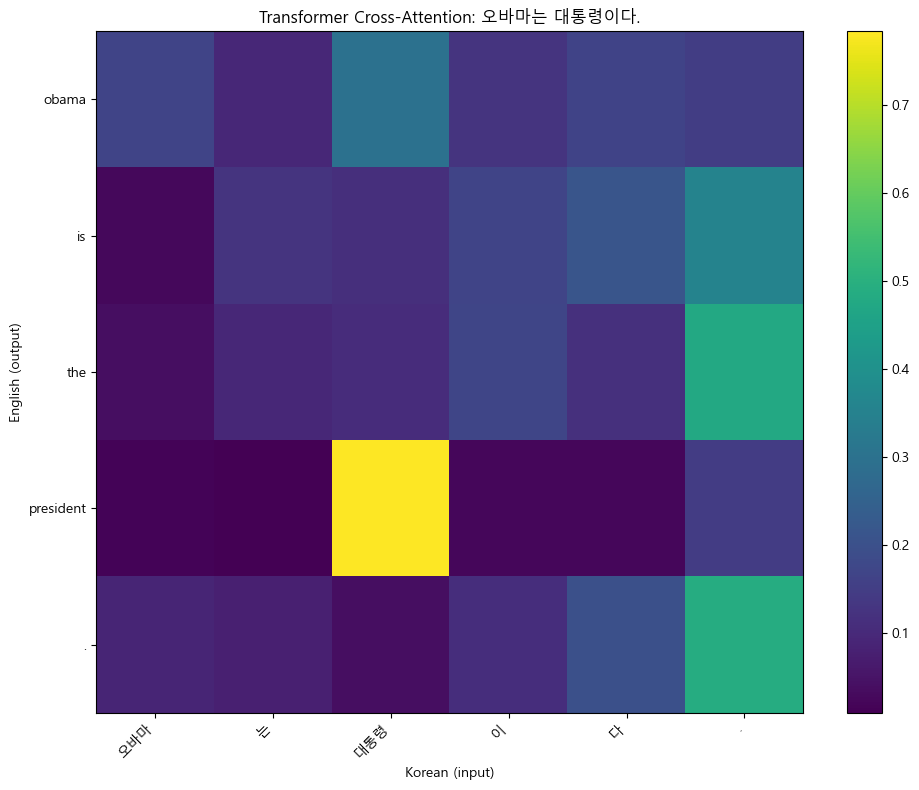

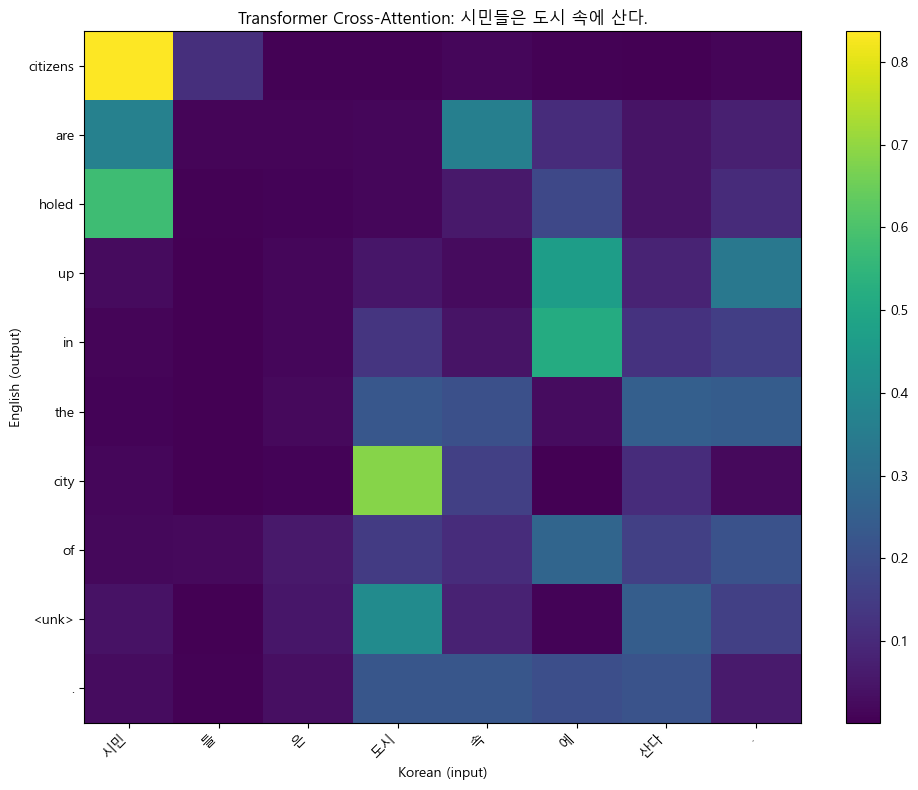

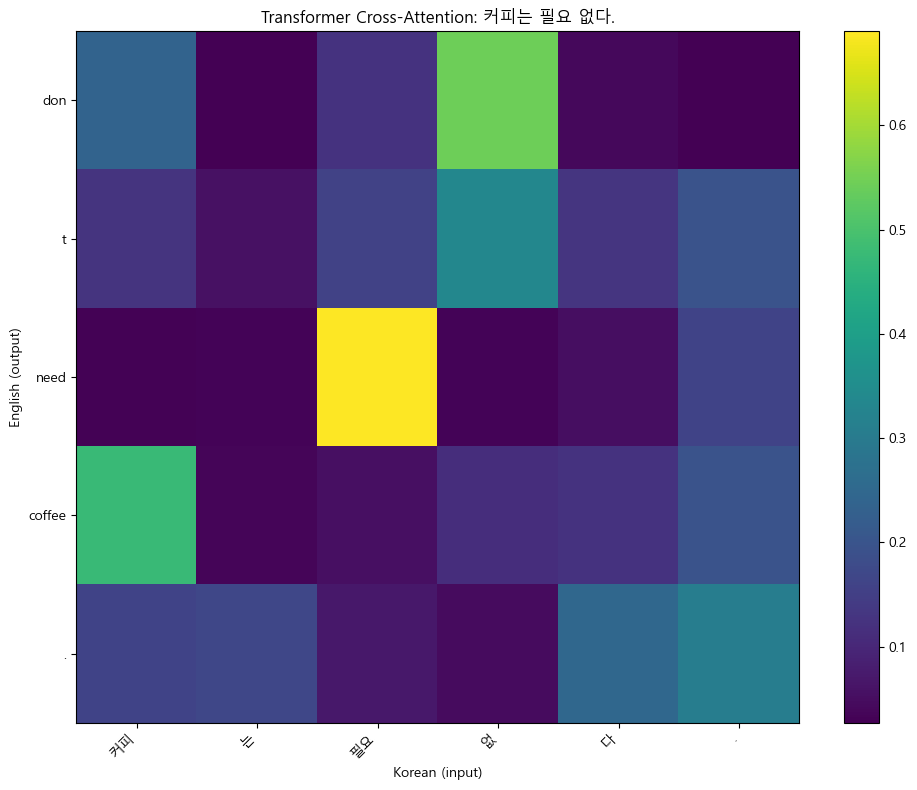

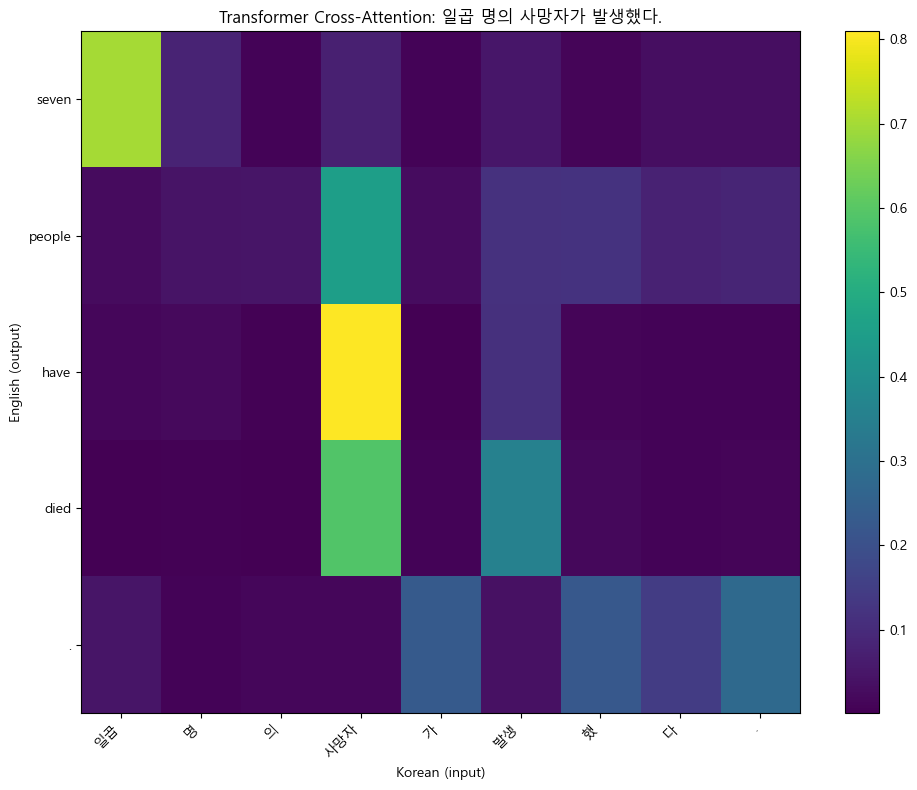


=== 셀 2 완료 ===


In [5]:
# ============================================================
# 셀 2: Transformer 학습 + 평가
# ============================================================

import torch.optim as optim
import time
import matplotlib.pyplot as plt

# ============================================================
# 1. Optimizer + Loss
# ============================================================
optimizer = optim.Adam(transformer.parameters(), lr=0.0005)  # Transformer는 lr 살짝 낮게
criterion = nn.CrossEntropyLoss(ignore_index=0)

NUM_EPOCHS = 10

# ============================================================
# 2. Train step (Transformer는 한 번에 처리)
# ============================================================
def train_step_transformer(src, tgt, transformer, optimizer, criterion, device):
    src = src.to(device)
    tgt = tgt.to(device)
    
    optimizer.zero_grad()
    
    # Decoder input: tgt[:, :-1] (마지막 토큰 제외)
    # Decoder output target: tgt[:, 1:] (첫 토큰 제외, shifted)
    tgt_input = tgt[:, :-1]
    tgt_output = tgt[:, 1:]
    
    # Forward
    output, _ = transformer(src, tgt_input)
    # output: (batch, seq_len-1, vocab_size)
    
    # Loss 계산 (전체 시퀀스 한 번에)
    loss = criterion(
        output.reshape(-1, VOCAB_SIZE),  # (batch*seq, vocab)
        tgt_output.reshape(-1)            # (batch*seq,)
    )
    
    if torch.isnan(loss):
        return None
    
    loss.backward()
    
    # Gradient clipping
    torch.nn.utils.clip_grad_norm_(transformer.parameters(), max_norm=1.0)
    
    optimizer.step()
    
    return loss.item()

# ============================================================
# 3. 학습 루프
# ============================================================
print(f"Transformer 학습 시작 ({NUM_EPOCHS} epochs)\n")
train_losses_transformer = []

for epoch in range(NUM_EPOCHS):
    transformer.train()
    epoch_loss = 0
    valid_batches = 0
    start_time = time.time()
    
    for batch_idx, (src, tgt) in enumerate(dataloader):
        loss = train_step_transformer(src, tgt, transformer, optimizer, criterion, device)
        
        if loss is not None:
            epoch_loss += loss
            valid_batches += 1
        
        if (batch_idx + 1) % 200 == 0:
            current = loss if loss else float('nan')
            print(f"Epoch {epoch+1} | Batch {batch_idx+1}/{len(dataloader)} | "
                  f"Loss: {current:.4f}")
    
    avg_loss = epoch_loss / valid_batches if valid_batches > 0 else float('nan')
    train_losses_transformer.append(avg_loss)
    elapsed = time.time() - start_time
    
    print(f"=== Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Avg Loss: {avg_loss:.4f} | "
          f"Time: {elapsed:.1f}s ===\n")

print("학습 완료!")
print(f"Transformer final loss: {train_losses_transformer[-1]:.4f}")

# ============================================================
# 4. 평가 함수 (자기회귀 생성)
# ============================================================
def translate_transformer(sentence, transformer, ko_token2id, en_id2token, 
                          mecab_inst, device, max_len=40):
    transformer.eval()
    
    with torch.no_grad():
        # 한국어 → ID
        text = preprocess_kor(sentence)
        ko_tokens = mecab_inst.morphs(text)
        ids = [ko_token2id.get(t, 1) for t in ko_tokens][:max_len]
        ids = ids + [0] * (max_len - len(ids))
        src = torch.tensor([ids], dtype=torch.long).to(device)
        
        # Encoder 통과
        src_mask = transformer.make_src_mask(src)
        encoder_out = transformer.encode(src, src_mask)
        
        # Decoder 자기회귀 생성
        tgt = torch.tensor([[2]], dtype=torch.long).to(device)  # <start>
        output_words = []
        all_attns = []
        
        for t in range(max_len - 1):
            tgt_mask = transformer.make_tgt_mask(tgt)
            output, cross_attns = transformer.decode(tgt, encoder_out, src_mask, tgt_mask)
            
            # 마지막 시점 단어 예측
            next_id = output[:, -1, :].argmax(dim=-1).item()
            
            if next_id == 3:  # <end>
                break
            
            word = en_id2token.get(next_id, '<unk>')
            output_words.append(word)
            
            # 마지막 layer의 마지막 시점 attention 저장
            last_attn = cross_attns[-1][0, 0, -1, :].cpu().numpy()  # (src_len,)
            all_attns.append(last_attn)
            
            # 다음 입력 = 지금까지 생성한 시퀀스
            tgt = torch.cat([tgt, torch.tensor([[next_id]], device=device)], dim=1)
        
        return output_words, np.array(all_attns), ko_tokens[:max_len]

# ============================================================
# 5. 4개 예문 번역
# ============================================================
test_sentences = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다.",
]

print("\n" + "=" * 60)
print("Transformer 평가")
print("=" * 60)

results_transformer = []
for sentence in test_sentences:
    output_words, attention, ko_tokens = translate_transformer(
        sentence, transformer, ko_token2id, en_id2token, mecab_inst, device
    )
    results_transformer.append((sentence, ko_tokens, output_words, attention))
    
    print(f"\n한국어: {sentence}")
    print(f"한국어 토큰: {ko_tokens}")
    print(f"번역  : {' '.join(output_words)}")

# ============================================================
# 6. Attention 시각화
# ============================================================
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

for sentence, ko_tokens, output_words, attention in results_transformer:
    if len(output_words) == 0:
        continue
    
    src_len = len(ko_tokens)
    attention_trimmed = attention[:, :src_len]
    
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(attention_trimmed, cmap='viridis', aspect='auto')
    ax.set_xticks(range(src_len))
    ax.set_xticklabels(ko_tokens, rotation=45, ha='right')
    ax.set_yticks(range(len(output_words)))
    ax.set_yticklabels(output_words)
    ax.set_xlabel('Korean (input)')
    ax.set_ylabel('English (output)')
    ax.set_title(f'Transformer Cross-Attention: {sentence}')
    plt.colorbar(im)
    plt.tight_layout()
    plt.show()

print("\n=== 셀 2 완료 ===")

### V3 모델 평가. 

- 첫 학습은 실수로 데이터가 날아가 버림 loss 1.8 정도였으며 결과가 오히려 더 나빠졌음. 
- 현재 모델 학습이 끝난 뒤 4문장 중에서 3문장이 자연스럽게 영어로 번역되었음. 
- 하지만 여기서 한가지 의문점이 생김 2번째 문장인 시민은 도시속에서 산다는 그렇게 어려운 문장이 아닌데도 이상하게 일관되게 실패하는 경우가 많았기 때문임 

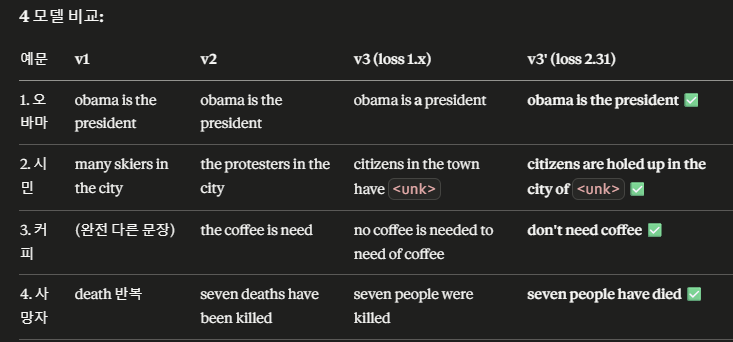
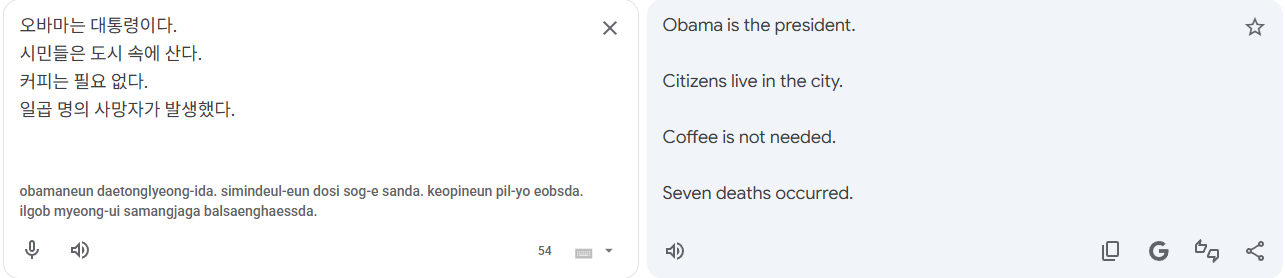

In [6]:
# 학습 데이터에서 "시민" 등장하는 시퀀스 찾기
sample_count = 10
shown = 0

print("=" * 60)
print("학습 데이터에서 '시민' 등장 문맥")
print("=" * 60)

for ko_ids, en_ids in id_corpus:
    ko_tokens = [ko_id2token.get(i, '?') for i in ko_ids if i != 0]
    if '시민' in ko_tokens:
        en_tokens = [en_id2token.get(i, '?') for i in en_ids if i != 0]
        ko_text = ' '.join(ko_tokens)
        en_text = ' '.join(en_tokens)
        print(f"\nKO: {ko_text}")
        print(f"EN: {en_text}")
        shown += 1
        if shown >= sample_count:
            break

print(f"\n'시민' 빈도: {ko_token_counter.get('시민', 0)}")

# "도시" 도 같이 보기
print("\n" + "=" * 60)
print("학습 데이터에서 '도시' 등장 문맥")
print("=" * 60)

shown = 0
for ko_ids, en_ids in id_corpus:
    ko_tokens = [ko_id2token.get(i, '?') for i in ko_ids if i != 0]
    if '도시' in ko_tokens:
        en_tokens = [en_id2token.get(i, '?') for i in en_ids if i != 0]
        ko_text = ' '.join(ko_tokens)
        en_text = ' '.join(en_tokens)
        print(f"\nKO: {ko_text}")
        print(f"EN: {en_text}")
        shown += 1
        if shown >= sample_count:
            break

print(f"\n'도시' 빈도: {ko_token_counter.get('도시', 0)}")

# "시민" + "도시" 같이 등장하는 시퀀스
print("\n" + "=" * 60)
print("'시민' + '도시' 동시 등장")
print("=" * 60)

shown = 0
for ko_ids, en_ids in id_corpus:
    ko_tokens = [ko_id2token.get(i, '?') for i in ko_ids if i != 0]
    if '시민' in ko_tokens and '도시' in ko_tokens:
        en_tokens = [en_id2token.get(i, '?') for i in en_ids if i != 0]
        ko_text = ' '.join(ko_tokens)
        en_text = ' '.join(en_tokens)
        print(f"\nKO: {ko_text}")
        print(f"EN: {en_text}")
        shown += 1
        if shown >= 5:
            break

학습 데이터에서 '시민' 등장 문맥

KO: 그 들 의 조치 는 기업 의 훌륭 한 시민 정신 일 뿐 이 었 다고 하 지만 그 결과 로 자신 의 집 을 잃 은 해리스 는 말 합니다
EN: <start> but harris , who lost his house as a result , says the real issues are california s constitutional guarantee of privacy and the state s <unk> law . <end>

KO: 일요일 일찍 블 루 버그 시장 은 뉴욕 시민 들 에게 교통 파업 계획 에 대해 경고 하 면서 우리 모두 는 이 일 을 함께 겪 을 것 이 다 고 말 했 다 .
EN: <start> earlier sunday , bloomberg warned new yorkers to plan for a strike and declared we are all in this together . <end>

KO: 무엇 보다 도 사람 을 최우선 적 으로 하 는 , 즉 모든 시민
EN: <start> and most of all , the challenge of putting people first , of including all citizens <end>

KO: 암호 화 의 문제점 은 그것 이 법 을 준수 하 는 시민 들 뿐 만 아니 라 범법자 들 까지 도 보호 할 수 있 게 된다는 것 이 다 .
EN: <start> the problem with encryption is that it can help shield <unk> as well as law <unk> citizens . <end>

KO: 금요일 , 한국 의 한 시민 단체 는 이 영화 가 상영 되 는 전국 의 140 여 개 의 극장 에서 안 보 기 운동 을 전개 할 계획 을 발표 했 다 .
EN: <start> on friday , a south korean civic group announced plans to launch a boycot


'시민' 가까운 단어 비교

[Word2Vec (학습 시작점)]
  이민자: 0.548
  역사가: 0.541
  피난민: 0.536
  젊은이: 0.536
  망명자: 0.531
  터키인: 0.528
  국무총리실: 0.525
  농민: 0.523
  시위자: 0.523
  영주: 0.521

[Transformer 학습 후]
  무고: 0.523
  민간인: 0.516
  청년: 0.490
  반란: 0.485
  이민자: 0.481
  이주민: 0.476
  이사국: 0.475
  동포: 0.475
  피난민: 0.472
  영주: 0.471

'도시' 가까운 단어 비교

[Word2Vec (학습 시작점)]
  항구: 0.587
  유적지: 0.579
  자이푸르: 0.571
  관광지: 0.555
  명소: 0.554
  캐리비안: 0.550
  수무: 0.546
  삼각주: 0.545
  빌딩: 0.543
  중심지: 0.540

[Transformer 학습 후]
  유적지: 0.585
  중심지: 0.536
  관광지: 0.529
  시내: 0.522
  항구: 0.508
  농촌: 0.496
  원촨: 0.487
  도로는: 0.487
  빈곤: 0.487
  결빙: 0.484

'시민' ↔ '도시' 거리
Word2Vec: 0.250
Transformer 학습 후: 0.242

vocab에 있는 단어: ['시민', '도시', '주민', '시위', '분쟁', '폭동', '대피', '전쟁', '거주', '생활', '주거', '국가', '정부', '대통령']


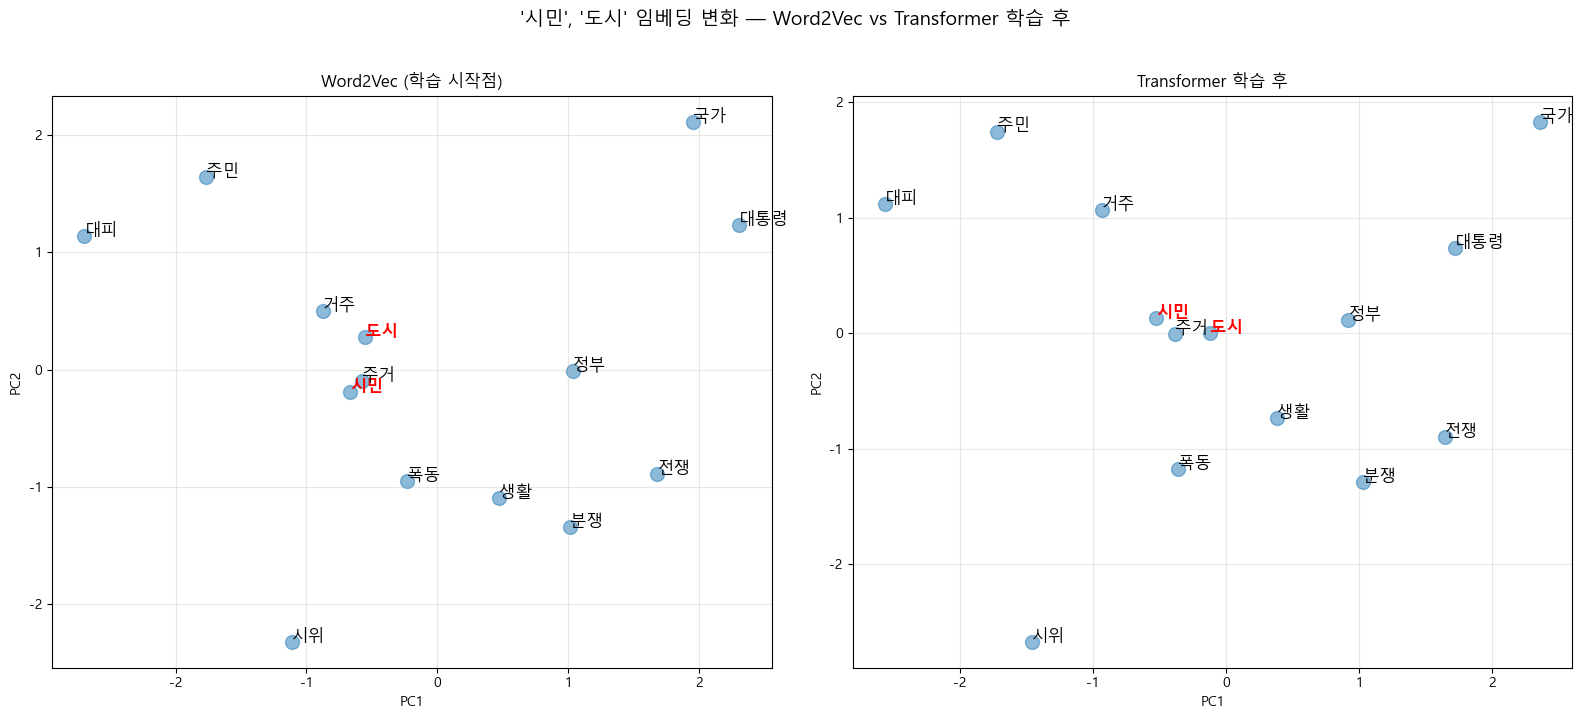

In [7]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ============================================================
# 두 임베딩 비교: word2vec (시작점) vs Transformer 학습 후
# ============================================================

# 1. Word2Vec 임베딩 (학습 시작점, 어제 v2와 동일)
w2v_emb = ko_embedding_matrix  # numpy array

# 2. Transformer 학습 후 임베딩
trans_emb = transformer.src_embedding.weight.detach().cpu().numpy()

# ============================================================
# "시민", "도시" 가까운 단어들 (cosine similarity)
# ============================================================

def find_nearest(target_word, embedding_matrix, token2id, id2token, top_k=10):
    """주어진 단어와 가까운 단어들 찾기"""
    if target_word not in token2id:
        return []
    target_id = token2id[target_word]
    target_vec = embedding_matrix[target_id].reshape(1, -1)
    
    # 모든 단어와 cosine similarity
    similarities = cosine_similarity(target_vec, embedding_matrix)[0]
    
    # padding (0), unk (1), start (2), end (3) 제외
    similarities[0] = -2
    similarities[1] = -2
    similarities[2] = -2
    similarities[3] = -2
    similarities[target_id] = -2  # 자기 자신 제외
    
    top_ids = np.argsort(similarities)[::-1][:top_k]
    return [(id2token[i], similarities[i]) for i in top_ids]

# 두 임베딩에서 비교
target_words = ['시민', '도시']

for word in target_words:
    print(f"\n{'=' * 60}")
    print(f"'{word}' 가까운 단어 비교")
    print(f"{'=' * 60}")
    
    print(f"\n[Word2Vec (학습 시작점)]")
    for token, sim in find_nearest(word, w2v_emb, ko_token2id, ko_id2token, top_k=10):
        print(f"  {token}: {sim:.3f}")
    
    print(f"\n[Transformer 학습 후]")
    for token, sim in find_nearest(word, trans_emb, ko_token2id, ko_id2token, top_k=10):
        print(f"  {token}: {sim:.3f}")

# ============================================================
# "시민" + "도시" 거리 비교
# ============================================================
print(f"\n{'=' * 60}")
print(f"'시민' ↔ '도시' 거리")
print(f"{'=' * 60}")

simin_w2v = w2v_emb[ko_token2id['시민']].reshape(1, -1)
dosi_w2v = w2v_emb[ko_token2id['도시']].reshape(1, -1)
sim_w2v = cosine_similarity(simin_w2v, dosi_w2v)[0][0]

simin_trans = trans_emb[ko_token2id['시민']].reshape(1, -1)
dosi_trans = trans_emb[ko_token2id['도시']].reshape(1, -1)
sim_trans = cosine_similarity(simin_trans, dosi_trans)[0][0]

print(f"Word2Vec: {sim_w2v:.3f}")
print(f"Transformer 학습 후: {sim_trans:.3f}")

# ============================================================
# PCA 시각화 — 시민/도시 + 주변 단어들
# ============================================================
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 비교할 단어 모음 — 시민/도시 + 가설 검증용 단어들
words_to_plot = [
    '시민', '도시', '주민', 
    '시위', '분쟁', '폭동', '갇힘', '대피', '전쟁',
    '거주', '생활', '주거',
    '국가', '정부', '대통령'
]
words_in_vocab = [w for w in words_to_plot if w in ko_token2id]
print(f"\nvocab에 있는 단어: {words_in_vocab}")

ids = [ko_token2id[w] for w in words_in_vocab]

# 두 임베딩에서 PCA
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, emb, title in zip(axes, [w2v_emb, trans_emb], 
                          ['Word2Vec (학습 시작점)', 'Transformer 학습 후']):
    vectors = emb[ids]
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(vectors)
    
    ax.scatter(pca_result[:, 0], pca_result[:, 1], s=100, alpha=0.5)
    for i, word in enumerate(words_in_vocab):
        # 시민, 도시는 빨간색 + 큰 글자
        color = 'red' if word in ['시민', '도시'] else 'black'
        weight = 'bold' if word in ['시민', '도시'] else 'normal'
        ax.annotate(word, (pca_result[i, 0], pca_result[i, 1]), 
                    fontsize=12, color=color, weight=weight)
    
    ax.set_title(title)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.grid(True, alpha=0.3)

plt.suptitle("'시민', '도시' 임베딩 변화 — Word2Vec vs Transformer 학습 후", 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


'citizens' 가까운 단어 (Transformer 학습 후)
  refugees: 0.633
  nationals: 0.584
  volunteers: 0.560
  iraqis: 0.551
  activists: 0.542
  individuals: 0.542
  marines: 0.542
  criminals: 0.541
  families: 0.541
  conscience: 0.539

'city' 가까운 단어 (Transformer 학습 후)
  town: 0.596
  neighborhood: 0.534
  outskirts: 0.523
  suburb: 0.511
  capital: 0.492
  suburbs: 0.487
  district: 0.474
  chittagong: 0.473
  streets: 0.469
  mosul: 0.467

'live' 가까운 단어 (Transformer 학습 후)
  levinson: 0.518
  streamed: 0.490
  foley: 0.486
  magoni: 0.452
  bodlander: 0.442
  anywhere: 0.436
  lit: 0.434
  screens: 0.432
  nashville: 0.429
  sit: 0.429

'town' 가까운 단어 (Transformer 학습 후)
  village: 0.669
  suburb: 0.642
  neighborhood: 0.639
  strait: 0.606
  city: 0.596
  outskirts: 0.583
  checkpoint: 0.576
  districts: 0.576
  samarra: 0.564
  mountains: 0.557

'people' 가까운 단어 (Transformer 학습 후)
  pilgrims: 0.595
  civilians: 0.574
  iraqis: 0.564
  refugees: 0.537
  migrants: 0.527
  kenyans: 0.525
  palestini

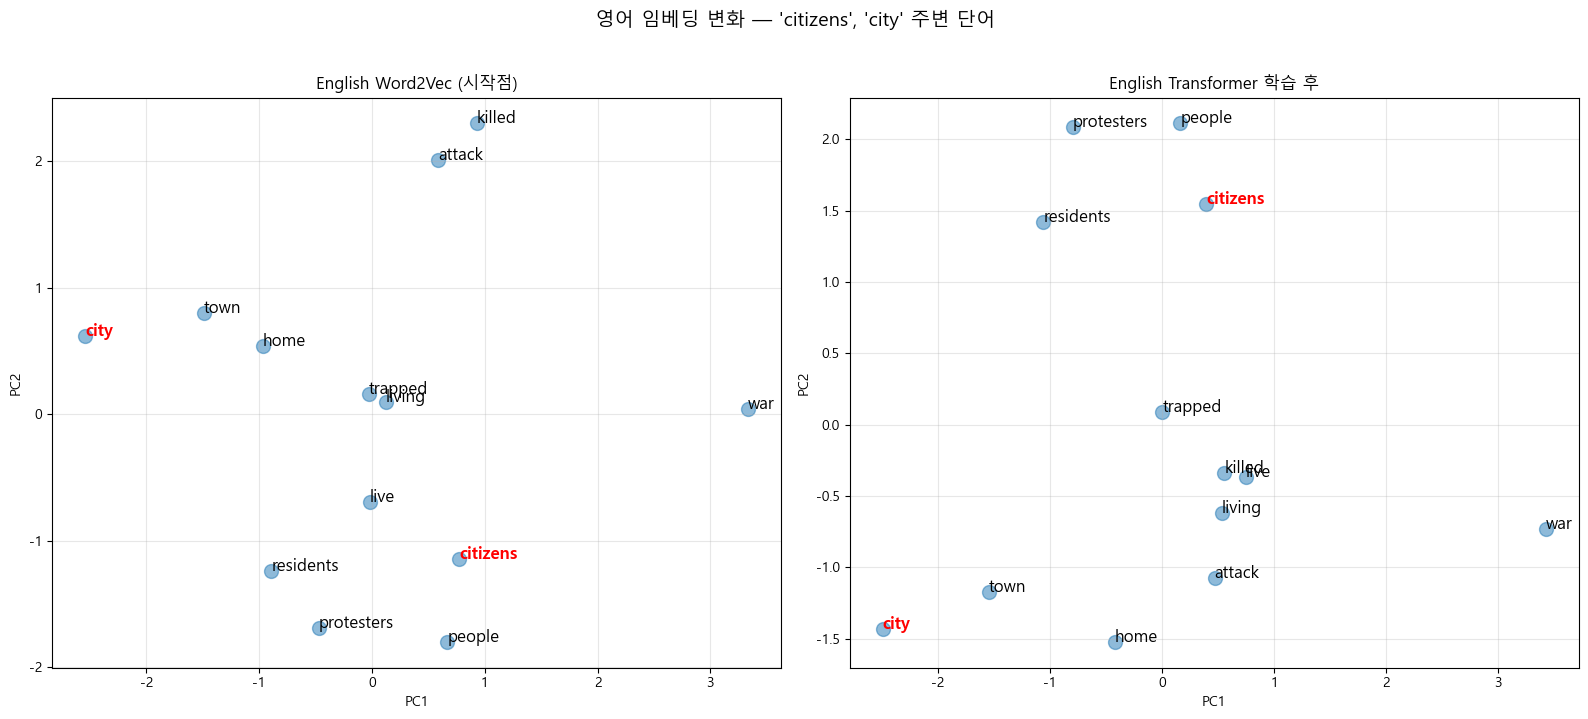


영어 학습 데이터에서 'citizens' 등장 맥락

KO: 이혼 을 합법화 하 는 국민 투표 에 투표 하 기 위하 여 로마 카톨릭 이 지배 적 인 나라 에서
EN: <start> citizens in ireland go to the polls today to vote on a referendum that could legalize divorce in the predominantly roman catholic country . <end>

KO: 무엇 보다 도 사람 을 최우선 적 으로 하 는 , 즉 모든 시민
EN: <start> and most of all , the challenge of putting people first , of including all citizens <end>

KO: 암호 화 의 문제점 은 그것 이 법 을 준수 하 는 시민 들 뿐 만 아니 라 범법자 들 까지 도 보호 할 수 있 게 된다는 것 이 다 .
EN: <start> the problem with encryption is that it can help shield <unk> as well as law <unk> citizens . <end>

KO: 이스라엘 아리엘 샤론 <unk> 은 성명 에서 이스라엘 국가 와 시민 들 은 이 어려운 시기 에 는 하나 라고 말 했 다 .
EN: <start> the state of israel and its citizens are as one at this difficult time , israeli prime minister ariel sharon s office said in a statement . <end>

KO: 수백만 명 의 시민 들 이 방사능 에 관련 된 질환 을 앓 고 있 다 .
EN: <start> millions of its citizens are affected by radiation related ailments . <end>

영어 학습 데이터에서 'holed' 등장 맥락

KO: 마지드 는 용의자 중 1 명 이

In [8]:
# ============================================================
# 영어 쪽 임베딩도 같이 분석
# ============================================================

en_w2v_emb = en_embedding_matrix
en_trans_emb = transformer.tgt_embedding.weight.detach().cpu().numpy()

# 영어 단어들 찾기
target_en_words = ['citizens', 'city', 'live', 'town', 'people']

for word in target_en_words:
    if word not in en_token2id:
        print(f"'{word}' 없음")
        continue
    
    print(f"\n{'=' * 60}")
    print(f"'{word}' 가까운 단어 (Transformer 학습 후)")
    print(f"{'=' * 60}")
    
    for token, sim in find_nearest(word, en_trans_emb, en_token2id, en_id2token, top_k=10):
        print(f"  {token}: {sim:.3f}")

# ============================================================
# 영어쪽 PCA — 부정적 단어와 일상 단어 같이
# ============================================================
en_words_to_plot = [
    'citizens', 'city', 'town', 
    'live', 'living', 'home',
    'protesters', 'trapped', 'killed', 'war', 'attack',
    'people', 'residents'
]
en_words_in_vocab = [w for w in en_words_to_plot if w in en_token2id]
print(f"\nvocab에 있는 영어 단어: {en_words_in_vocab}")

en_ids = [en_token2id[w] for w in en_words_in_vocab]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, emb, title in zip(axes, [en_w2v_emb, en_trans_emb], 
                          ['English Word2Vec (시작점)', 'English Transformer 학습 후']):
    vectors = emb[en_ids]
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(vectors)
    
    ax.scatter(pca_result[:, 0], pca_result[:, 1], s=100, alpha=0.5)
    for i, word in enumerate(en_words_in_vocab):
        color = 'red' if word in ['citizens', 'city'] else 'black'
        weight = 'bold' if word in ['citizens', 'city'] else 'normal'
        ax.annotate(word, (pca_result[i, 0], pca_result[i, 1]), 
                    fontsize=12, color=color, weight=weight)
    
    ax.set_title(title)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.grid(True, alpha=0.3)

plt.suptitle("영어 임베딩 변화 — 'citizens', 'city' 주변 단어", 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ============================================================
# 영어 학습 데이터에서 "citizens" 등장 맥락
# ============================================================
print("\n" + "=" * 60)
print("영어 학습 데이터에서 'citizens' 등장 맥락")
print("=" * 60)

shown = 0
for ko_ids, en_ids in id_corpus:
    en_tokens = [en_id2token.get(i, '?') for i in en_ids if i != 0]
    if 'citizens' in en_tokens:
        ko_tokens = [ko_id2token.get(i, '?') for i in ko_ids if i != 0]
        print(f"\nKO: {' '.join(ko_tokens)}")
        print(f"EN: {' '.join(en_tokens)}")
        shown += 1
        if shown >= 5:
            break

# "holed" 도 보기 (직접 출력에 나온 단어)
print("\n" + "=" * 60)
print("영어 학습 데이터에서 'holed' 등장 맥락")
print("=" * 60)

shown = 0
for ko_ids, en_ids in id_corpus:
    en_tokens = [en_id2token.get(i, '?') for i in en_ids if i != 0]
    if 'holed' in en_tokens:
        ko_tokens = [ko_id2token.get(i, '?') for i in ko_ids if i != 0]
        print(f"\nKO: {' '.join(ko_tokens)}")
        print(f"EN: {' '.join(en_tokens)}")
        shown += 1
        if shown >= 5:
            break

In [10]:
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

# 256차원 그대로 거리
emb = transformer.tgt_embedding.weight.detach().cpu().numpy()

if 'citizens' in en_token2id and 'city' in en_token2id:
    citizens_vec = emb[en_token2id['citizens']].reshape(1, -1)
    city_vec = emb[en_token2id['city']].reshape(1, -1)
    
    cos_sim = cosine_similarity(citizens_vec, city_vec)[0][0]
    eucl_dist = euclidean_distances(citizens_vec, city_vec)[0][0]
    
    print(f"=== 256차원 그대로 ===")
    print(f"citizens ↔ city")
    print(f"  Cosine similarity: {cos_sim:.4f}")
    print(f"  Euclidean distance: {eucl_dist:.4f}")

# Word2Vec 임베딩에서도 같은 비교
emb_w2v = en_embedding_matrix
if 'citizens' in en_token2id and 'city' in en_token2id:
    citizens_w2v = emb_w2v[en_token2id['citizens']].reshape(1, -1)
    city_w2v = emb_w2v[en_token2id['city']].reshape(1, -1)
    
    cos_sim_w2v = cosine_similarity(citizens_w2v, city_w2v)[0][0]
    eucl_w2v = euclidean_distances(citizens_w2v, city_w2v)[0][0]
    
    print(f"\n=== Word2Vec (시작점) ===")
    print(f"citizens ↔ city")
    print(f"  Cosine similarity: {cos_sim_w2v:.4f}")
    print(f"  Euclidean distance: {eucl_w2v:.4f}")

# 한국어도 같이 비교
emb_ko = transformer.src_embedding.weight.detach().cpu().numpy()
emb_ko_w2v = ko_embedding_matrix

print(f"\n=== 한국어 ===")
for emb_now, name in [(emb_ko_w2v, 'Word2Vec'), (emb_ko, 'Transformer 학습 후')]:
    simin_vec = emb_now[ko_token2id['시민']].reshape(1, -1)
    dosi_vec = emb_now[ko_token2id['도시']].reshape(1, -1)
    cos = cosine_similarity(simin_vec, dosi_vec)[0][0]
    print(f"  [{name}] 시민 ↔ 도시: cos={cos:.4f}")

=== 256차원 그대로 ===
citizens ↔ city
  Cosine similarity: 0.1943
  Euclidean distance: 5.2417

=== Word2Vec (시작점) ===
citizens ↔ city
  Cosine similarity: 0.1923
  Euclidean distance: 5.2076

=== 한국어 ===
  [Word2Vec] 시민 ↔ 도시: cos=0.2503
  [Transformer 학습 후] 시민 ↔ 도시: cos=0.2421


In [11]:
# 영어 임베딩에서 진짜 변화 추적
en_w2v = en_embedding_matrix
en_trans = transformer.tgt_embedding.weight.detach().cpu().numpy()

# citizens 주변 단어들과의 거리 변화
target_pairs = [
    ('citizens', 'protesters'),
    ('citizens', 'residents'),
    ('citizens', 'people'),
    ('citizens', 'live'),
    ('citizens', 'town'),
    ('city', 'town'),
    ('city', 'home'),
    ('city', 'live'),
    ('city', 'war'),
]

print(f"{'단어 쌍':<25} {'Word2Vec':<12} {'Trans 후':<12} {'변화':<10}")
print("=" * 60)

for w1, w2 in target_pairs:
    if w1 not in en_token2id or w2 not in en_token2id:
        continue
    
    v1_w2v = en_w2v[en_token2id[w1]].reshape(1, -1)
    v2_w2v = en_w2v[en_token2id[w2]].reshape(1, -1)
    cos_w2v = cosine_similarity(v1_w2v, v2_w2v)[0][0]
    
    v1_trans = en_trans[en_token2id[w1]].reshape(1, -1)
    v2_trans = en_trans[en_token2id[w2]].reshape(1, -1)
    cos_trans = cosine_similarity(v1_trans, v2_trans)[0][0]
    
    change = cos_trans - cos_w2v
    arrow = '↑' if change > 0 else '↓' if change < 0 else '='
    
    print(f"{w1+' ↔ '+w2:<25} {cos_w2v:.4f}      {cos_trans:.4f}      {arrow} {change:+.4f}")

단어 쌍                      Word2Vec     Trans 후      변화        
citizens ↔ protesters     0.3790      0.3996      ↑ +0.0206
citizens ↔ residents      0.4737      0.4694      ↓ -0.0043
citizens ↔ people         0.4644      0.4902      ↑ +0.0258
citizens ↔ live           0.2248      0.2143      ↓ -0.0105
citizens ↔ town           0.1992      0.1477      ↓ -0.0515
city ↔ town               0.5344      0.5959      ↑ +0.0614
city ↔ home               0.2020      0.2141      ↑ +0.0121
city ↔ live               0.1870      0.1384      ↓ -0.0486
city ↔ war                0.0880      0.0765      ↓ -0.0115


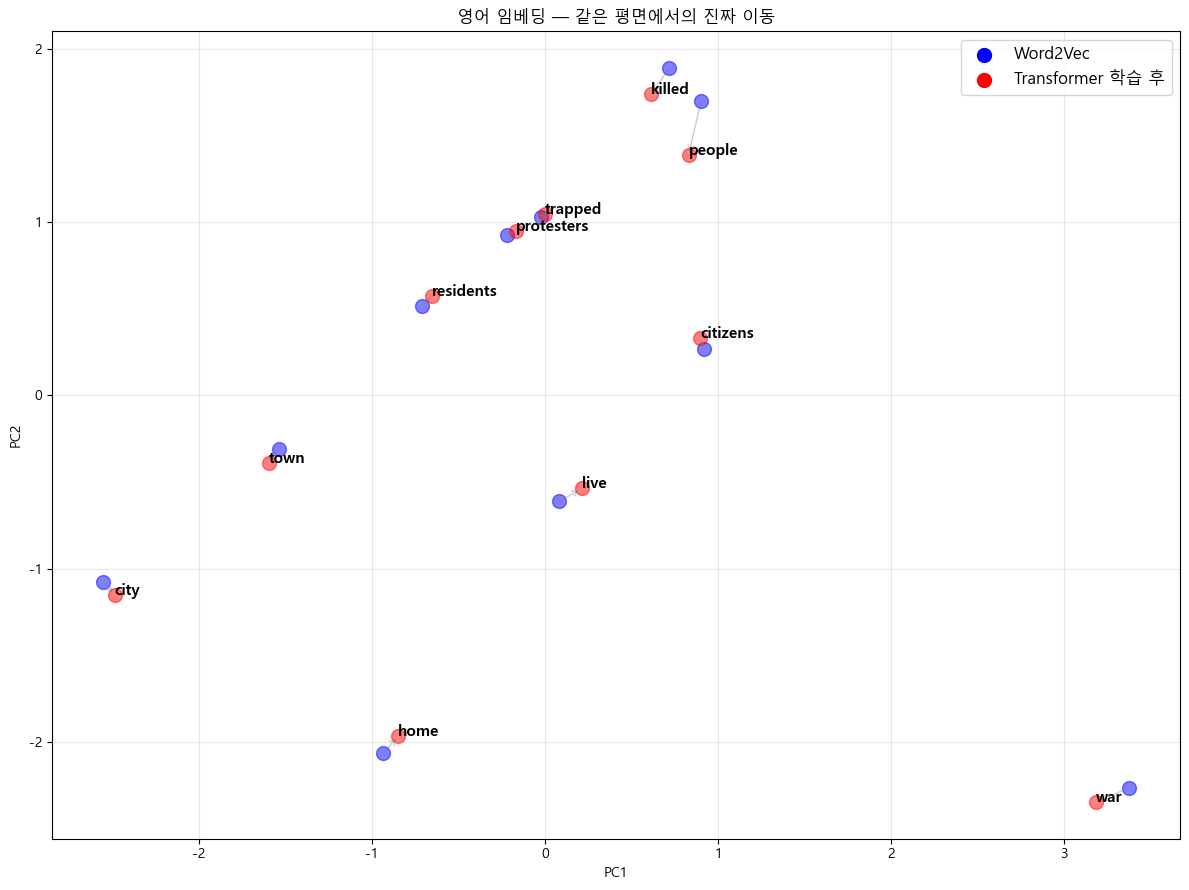

In [12]:
# 두 임베딩을 같은 평면에 비교
# Word2Vec 기준 PCA 평면을 만들고, Transformer도 그 평면에 투영

en_words_to_plot = [
    'citizens', 'city', 'town', 'live', 'home',
    'protesters', 'trapped', 'killed', 'war',
    'people', 'residents'
]
en_words_in_vocab = [w for w in en_words_to_plot if w in en_token2id]
en_ids = [en_token2id[w] for w in en_words_in_vocab]

en_w2v = en_embedding_matrix
en_trans = transformer.tgt_embedding.weight.detach().cpu().numpy()

# Word2Vec 기준으로 PCA 학습
w2v_vectors = en_w2v[en_ids]
pca_shared = PCA(n_components=2)
pca_shared.fit(w2v_vectors)

# 두 임베딩 모두 같은 평면에 투영
w2v_2d = pca_shared.transform(w2v_vectors)
trans_2d = pca_shared.transform(en_trans[en_ids])

# 시각화: 화살표로 이동 표시
fig, ax = plt.subplots(figsize=(12, 9))

for i, word in enumerate(en_words_in_vocab):
    # Word2Vec 위치
    ax.scatter(w2v_2d[i, 0], w2v_2d[i, 1], s=100, c='blue', alpha=0.5)
    # Transformer 위치
    ax.scatter(trans_2d[i, 0], trans_2d[i, 1], s=100, c='red', alpha=0.5)
    # 이동 화살표
    ax.annotate('', xy=trans_2d[i], xytext=w2v_2d[i],
                arrowprops=dict(arrowstyle='->', color='gray', alpha=0.4))
    # 단어 라벨
    ax.annotate(word, trans_2d[i], fontsize=11, weight='bold')

ax.scatter([], [], c='blue', label='Word2Vec', s=100)
ax.scatter([], [], c='red', label='Transformer 학습 후', s=100)
ax.legend(fontsize=12)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('영어 임베딩 — 같은 평면에서의 진짜 이동')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# 한국어에 "살" 또는 "거주" 등 들어간 데이터의 영어 짝
print("=" * 60)
print("'살' 들어간 한국어 + 영어 번역")
print("=" * 60)

shown = 0
for ko_ids, en_ids in id_corpus:
    ko_tokens = [ko_id2token.get(i, '?') for i in ko_ids if i != 0]
    if any(t in ['살', '거주', '주거', '생활'] for t in ko_tokens):
        en_tokens = [en_id2token.get(i, '?') for i in en_ids if i != 0]
        ko_text = ' '.join(ko_tokens)
        en_text = ' '.join(en_tokens)
        # "live" 들어간 것만
        if 'live' in en_tokens or 'living' in en_tokens or 'lives' in en_tokens:
            print(f"\nKO: {ko_text}")
            print(f"EN: {en_text}")
            shown += 1
            if shown >= 5:
                break

# 빈도 확인
print("\n" + "=" * 60)
print("관련 단어 빈도")
print("=" * 60)

for word in ['live', 'living', 'lives', 'lived']:
    freq = en_token_counter.get(word, 0)
    print(f"  영어 '{word}': {freq}")

for word in ['산다', '살', '거주', '주거', '생활']:
    freq = ko_token_counter.get(word, 0)
    print(f"  한국어 '{word}': {freq}")

# 우리 평가 입력의 한국어 토큰
print("\n" + "=" * 60)
print("'시민들은 도시 속에 산다' 토큰화")
print("=" * 60)
test = "시민들은 도시 속에 산다."
tokens = mecab_inst.morphs(preprocess_kor(test))
for t in tokens:
    in_vocab = t in ko_token2id
    print(f"  '{t}': {'O' if in_vocab else 'X'} {'vocab에 있음' if in_vocab else 'vocab에 없음 (UNK)'}")

'살' 들어간 한국어 + 영어 번역

KO: 인구 의 대부분 은 집 에서 살 고 있 지 않 은 거리 의 주민 들 입니다 .
EN: <start> a large part of the population is a street population that doesn t live in the houses at all . <end>

KO: 많 은 경우 에 있 어서 , 흑인 들 은 그 들 이 현재 살 고 있 는 도시 빈곤 지역 으로 한 30 년 전 쯤 에 이주 해 왔 습니다 .
EN: <start> in many cases , the areas in the inner city where they live , they migrated to them within a generation ago . <end>

KO: 영국인 인 미라 졸라 는 런던 거래소 에서 가장 활발히 거래 되 는 구리 , 알미늄 그리고 다른 기초 금속 들 을 거래 하 기 때문 에 여전히 런던 시간 에 따라 생활 하 고 있 다 .
EN: <start> <unk> , a british , still lives on london time because she trades copper , aluminum , and other base metals that are most active on the london exchange . <end>

KO: 싱 가 폴 의 270 만 인구 가 <unk> 평방 <unk> 의 면적 에 살 고 있 다 .
EN: <start> singapore s 2 . 7 million people live in <unk> square kilometers . <end>

KO: 세계 인구 의 약 45 가 도시 에 살 고 있 으며 그 비율 은 급속히 증가 하 고 있 다 .
EN: <start> some 45 of the world s people live in cities , a <unk> which is rising rapidly . <end>

관련 단어 빈도
  영어 'live': 257
 

### 임베딩 분포를 가시화 해서 확인해봄 

- 처음 시각적 인상에서는 한국어와 영어로 특징적인 점이 나타났었음 한국어는 시민과 도시에 대한 상관관계가 가까운 편이었는데 영어는 도시와 시민이 처음부터 떨어져 있었기 때문이었음, 또한 트랜스포머 학습 후에는 영어에서 시민에 대한 정보가 크게 이동한 것 처럼 보여 뭔가 편향이 생겼나 하는 생각이 들었음. 
- 하지만 사실 이 분포도 시각화 자체가 256차원을 2차원으로 압축한 거라 오히려 분포도가 그렇게 정확한 것은 아니었음 실제 256차원 거리로 측정해보니 cosine similarity 변화 0.001 정도 — 거의 변화 없음
- 자연스러운 번역이라면 live가 나와야 하지 않았나 역시 분포도에서도 live가 그렇게 멀리 떨어져있는 관계성은 아니었기 때문에 이상했지만 
아마 이전 문장의 정보를 문맥을 통해 계산하면서 live보다는 조금 부정적인 쪽으로 번역을 한게 아닌가 하는 생각이 들었음 
- 또한 산다 라는 한국어는 vocab에도 없기 때문에 더더욱 이 단어에 대한 처리가 live가 아닌 다른 단어로 대체된 가능성이 높다고 생각함 
- 학습 데이터에서 '시민 + 도시' 조합이 주로 부정적 맥락 (시위, 갇힘 등) 으로 자주 나왔던게 아닐까. 

### 핵심 학습

- 트랜스포머 구조도 중요하지만, *학습 시점* + *데이터 편향* + *토크나이저* 가 결과에 결정적
- 시각화는 가설 도구지 결론 도구가 아님 — 항상 수치 검증
- 모델은 데이터의 거울 — 편향은 데이터에서 시작
- "왜 X가 안 나왔나" 의 답 = vocab + 매핑 신호 + 다른 후보들 비교